# The Geysers: a field laboratory for induced seismicity

## § 0 · Introduction, scope, and the datasets used in this course

---

### 0.1 · The problem, and the field chosen to study it

Earthquakes whose timing, location or rate is controlled by human activity are termed **induced
seismicity**. They accompany a range of subsurface operations, among them the disposal of
wastewater in deep wells, the geological storage of carbon dioxide, and the circulation of water
through hot rock to generate electricity. The questions they raise are practical as well as
scientific: which operations produce earthquakes, of what size, and by what evidence one would
know. The obstacle to answering them is ordinarily not the seismology but the record of the
forcing. What was injected, at what depth, and when, is seldom available to the observer, so the
putative cause cannot itself be measured, and the association between operation and seismicity has
to be argued from the seismicity alone.

The Geysers is an exception, and that is the reason this course is built upon it. The forcing is
industrial and is reported monthly to a state regulator; it varies strongly and repeatedly with
season, which supplies a natural experiment that is not available at sites where the forcing is
monotonic; and the resulting seismicity is recorded by an unusually dense local network. The
remainder of this section describes the field, and § 10 returns to the question of attribution.

A **geothermal field** is a place where rock hot enough to boil water lies close enough to the
surface to be reached by drilling. Wells are sunk into it, the heat is raised to the surface as
steam or as hot water, and the steam is passed through a turbine. The Geysers, in the Coast Ranges
approximately 120 km north of San Francisco, has generated electricity in this manner since 1960
and is the largest geothermal electricity-generating complex in operation. It is also unusual in
kind: most geothermal reservoirs deliver hot water, which must be flashed to steam at the surface,
whereas this one delivers **dry steam** directly.

A steam reservoir holds a finite quantity of fluid in a finite volume of rock, and the greater part
of the steam raised at The Geysers is lost to evaporation in the cooling towers of the power plants
rather than returned to the ground. The consequence is visible in the production record loaded in
§ 2: monthly steam production peaked near 10.0 Mt in 1987 and has since fallen to approximately
4.0 Mt. From the late 1990s the response was to import water from outside the field. Treated
municipal wastewater is piped in from the surrounding towns and injected into the reservoir, first
through the Southeast Geysers Effluent Pipeline in 1997 and subsequently through the Santa Rosa
Geysers Recharge Project in 2003. Injection over the most recent twelve months of the record
averages 3.7 Mt per month, approximately 92 per cent of the mass produced, so the field is at
present operated close to a mass balance that it could not sustain on its own condensate. Both
pipeline dates are identifiable in the record examined in § 2.

The field is seismically active to an unusual degree: the regional catalogue lists more than twelve
thousand earthquakes within the field in 2016 alone, and more than 400,000 since 1969. Two
mechanisms are commonly invoked, and both reduce to rendering a fracture that is already close to
failure easier to slip. Injected water raises the **pore pressure** in the rock, which acts against
the normal stress clamping the two faces of a fracture together and so reduces the frictional
resistance to slip. Separately, relatively cool water entering hot rock causes the rock to
contract, which perturbs the local stress field. Neither mechanism creates faults; both permit
existing fractures to move.

Most of these earthquakes are far too small to be felt, but not all of them. The catalogue places
893 events of magnitude 3 or greater and 53 of magnitude 4 or greater within the field, and the
largest, of magnitude 5.0, occurred on 14 December 2016. An earthquake of that size at a depth of
two to three kilometres is felt strongly in the towns around the field. It is the occasional
moderate event, rather than the great number of very small ones, that makes attribution a practical
question as well as a scientific one, and that is the reason a field of this kind is monitored at
all.

The observational basis is correspondingly strong. The regional catalogue used here begins in
October 1969 and runs to December 2025, a span of 56 years; 81 permanent station sites lie within
40 km of the centre of the field and 49 of them within the field itself, a density that is
exceptional for an area of this size and that is examined in § 3. The reason so much of this
notebook is spent on what the records contain, rather than on what can be inferred from them, is
that a dataset of this quality repays the scrutiny.

One qualification should be carried from the outset. The region is tectonically active
independently of the field. Three major fault systems cross it, and not every earthquake within the
map area is induced. Distinguishing the two populations is an open problem, and § 10 treats it as
such rather than as a settled result.


### 0.2 · Purpose, and the place of this notebook in the two courses

EPS 130 derives the principal quantities of seismology from the physics: how an elastic wave
propagates through the Earth, why a compressional (P) wave arrives before a shear (S) wave, what a
magnitude scale measures, how the orientation of slip on a fault determines the pattern of motion
it radiates, and how the statistics of many earthquakes are described. EPS 207 asks a different
question about the same quantities: not what they are in theory, but **how well they can be
measured from real records**, and what a machine-learning method adds once they have been.

This notebook is the bridge between the two, and it is the foundation for the rest of the term. It
derives nothing and it introduces no method. It follows one chain, from the ground moving to a
number in a catalogue, and asks at each link what was actually measured, under what convention,
and how well it is known:

> ground motion → a recorded seismogram → arrival times, amplitudes and polarities →
> location, magnitude and focal mechanism → a catalogue → a statement about the field

Every subsequent week of the course enters this chain at some point, and none of them re-derives
it. A week on phase picking replaces the arrival times; a week on location replaces the step from
arrival times to a hypocentre; a week on moment tensors replaces the focal mechanism with a fuller
description of the source. In each case the value of the new method can only be judged against
what the conventional measurement already achieves, and against how well that measurement is
known. Establishing both is the purpose of this notebook.

**Objectives.** Each link in that chain is a measurement, and the recurring theme of the notebook
is that a measurement is not the quantity it estimates. By the end of it you should be able to:

1. **recover ground motion from a raw record**, given the response of the instrument and digitiser
   that produced it, and state the bandwidth and dynamic range over which the recovery is valid —
   *§§ 5 and 7*;
2. **read a phase arrival and attach an uncertainty to it**, separating the precision with which a
   time can be written from the judgement of where the phase begins — *§ 6*;
3. **measure a magnitude from an amplitude**, state the convention under which it was measured, and
   explain why a scale defined at a fixed period saturates for large sources — *§ 7*;
4. **determine the orientation and sense of slip on a fault from first motions**, and state the
   ambiguity between the two planes that remains — *§ 8*;
5. **assess what a catalogue does and does not contain**: its completeness as a property of the
   recording network rather than of the Earth, and which of its columns are measurements rather
   than conventions, placeholders or artefacts of the processing — *§§ 3, 4 and 9*;
6. **estimate a *b*-value with a defensible uncertainty**, having first established the magnitude
   above which the catalogue is complete — *§ 9*;
7. **test an association between forcing and seismicity against a null hypothesis** that removes
   the structure under test while preserving the rest — *§ 10*;
8. **trace any number used here back to the file it came from**, and say what was excluded when
   that file was compiled — *§§ 1 to 3, and throughout*.

**What the notebook does not do.** It does not derive the elastic wave equation, the ray geometry,
or the radiation pattern of a double couple; those derivations belong to EPS 130 and are used here
as results. It does not relocate earthquakes, invert for velocity structure, or fit a source model,
which are the subjects of the location, tomography and moment-tensor sessions. And it trains nothing. Wherever a
machine-learning method would ordinarily be applied, this notebook establishes instead the
conventional measurement against which such a method must later be compared, and stops there.

**How the notebook is organised.** Sections are self-contained: each begins by loading its own
data, with the address written out in full, so that a single cell may be copied into later work and
will still run without the rest of the notebook. Each closes by naming the weeks that return to it.
Several sections contain a step at which the obvious procedure gives the wrong answer, which is then
diagnosed rather than avoided; these are not invented for the purpose, but are errors made during
the construction of this material and left in place because the diagnosis is the transferable part.


### 0.3 · Running the notebook

The notebook may be opened in any of three places.

* **Google Colab** — [**launch**](https://colab.research.google.com/github/AI4EPS/EPS207_Observational_Seismology/blob/main/docs/notebooks/project_geysers_data.ipynb). **Use this one for this notebook.** No login is required beyond a
  Google account, but nothing is retained unless the notebook is first copied to your own Drive.
* **Berkeley DataHub** — [**launch**](https://datahub.berkeley.edu/hub/user-redirect/git-pull?repo=https%3A%2F%2Fgithub.com%2FAI4EPS%2FEPS207_Observational_Seismology&urlpath=lab%2Ftree%2FEPS207_Observational_Seismology%2Fdocs%2Fnotebooks%2Fproject_geysers_data.ipynb&branch=main). Sign in with CalNet and the notebook runs in the browser. The link
  clones this repository into your DataHub account and reopens the notebook on each visit, so
  returning to it later also collects any corrections, and edits are retained. DataHub gives a
  session one gigabyte of memory for everything it does, however, and a complete run of this
  notebook needs closer to two, so it will not reach the end there. The weekly notebooks are far
  smaller and DataHub is the easier place for them.
* **Locally** — clone [the repository](https://github.com/AI4EPS/EPS207_Observational_Seismology) and open `docs/notebooks/project_geysers_data.ipynb`.

Beyond `numpy`, `pandas` and `matplotlib`, one further library is required: **`obspy`**, the
standard toolkit of observational seismology, which handles waveform formats, station metadata and
requests to data centres. DataHub already has it, and on Colab the setup cell of § 0.8 installs it,
so no separate step is needed on either. There is no package belonging to this course and nothing
further to install. A complete run takes
approximately four minutes, most of which is spent waiting on downloads, and requires about 30 MB
of disk.


### 0.4 · The study region, the datasets, and the convention for loading them

**The region.** Three nested windows are used throughout, and later sections refer to them by name
rather than by their coordinates.

* the **download box**, 123.30° W to 122.30° W and 38.44° N to 39.20° N, approximately 87 by 85 km.
  Every dataset was requested over this extent, and nothing outside it is available here.
* the **study region**, the circle of 40 km radius centred on 38.820° N, 122.803° W, which is the
  median epicentre of the network catalogue over 2012–2026. This is the area the regional maps
  show.
* the **field window**, 122.99° W to 122.65° W and 38.70° N to 38.899° N, approximately 29 by
  22 km, which encloses the producing field. Every statistic described below as pertaining to *the
  field* is computed over this window, and not over the administrative boundary discussed in § 1,
  which is larger.

All three are declared once, in the data cell of § 0.8, and are not redefined anywhere else.

**The datasets.** Ten are used. Seven are **hosted with the course**, because each is the product of work
that should not be repeated by every reader: the catalogue is cut from 200 MB of yearly national
files; the coverage table is the result of a twenty-five-minute scan of an archive; the map layers
are extracted from 350 MB of shapefiles; the phase arrivals are cut from a compilation covering the
whole network; and the production record is served by the state regulator only from behind a form
that requires a name and an electronic mail address, so that it cannot be retrieved by a program at
all.

| dataset | § | contents | size |
|---|---|---|---|
| `geysers_catalog_1969-2026` | 4 | 443,403 rows — time, position, depth, magnitude; 419,248 survive the exclusions of § 4 | 12.9 MB |
| `geysers_phases_2016` | 6 | 265,991 P and S arrival times and first motions | 4.2 MB |
| `geysers_map_layers` | 1 | elevation, geology, faults, lakes, the field outline | 4.7 MB |
| `geysers_mechanisms_1975-2026` | 8 | 56,396 focal mechanisms determined from first motions | 1.7 MB |
| `geysers_archive_coverage` | 3 | which station holds waveform data in which month | 0.5 MB |
| `geysers_station_polarity` | 8 | which stations record first motions with reversed polarity | 0.3 MB |
| `geysers_injection_production` | 2 | monthly steam produced and water injected, from 1969 | 21 kB |

The phase arrivals are distributed one year at a time, because the full compilation is far larger
than the rest of the course material combined. The year used here is 2016, which is chosen because
it contains both the reference earthquake of §§ 5 to 8 and the largest event the catalogue places
within the field.

The remaining three — the station inventory, the waveforms themselves, and the moment tensors —
are retrieved **live** from the data centres that hold them, because in those cases the act of
retrieval is itself part of the subject matter.

**Data sources.** None of these data were collected for this course, and all of them are
redistributions of public products which should be cited as such in any work that uses them.

* Earthquake catalogue, phase arrivals, focal mechanisms, station metadata and waveforms —
  Northern California Earthquake Data Center (2014), *Northern California Earthquake Data Center*,
  UC Berkeley Seismological Laboratory, dataset, `10.7932/NCEDC`. The catalogue and mechanisms are
  products of the Northern California Seismic Network.
* Steam production and water injection — California Geologic Energy Management Division (CalGEM),
  California Department of Conservation, monthly geothermal production and injection reports.
* Rock units and lakes — Horton, J. D., San Juan, C. A., & Stoeser, D. B. (2017), *The State
  Geologic Map Compilation (SGMC) geodatabase of the conterminous United States*, U.S. Geological
  Survey Data Series 1052, `10.3133/ds1052`.
* Fault traces and their age classes — Schmitt, R. G., Gold, R. D., & Geologic Hazards Science
  Center (2020), *Quaternary Fault and Fold Database for the Nation*, U.S. Geological Survey,
  `10.5066/P9BCVRCK`.
* Towns and power plants — OpenStreetMap contributors, © OpenStreetMap contributors, available
  under the Open Database Licence.
* Elevation model — AWS Terrain Tiles (Terrarium encoding, zoom level 12, approximately 30 m
  ground sampling).
* The Known Geothermal Resource Area outline — California State Geoportal, *Geothermal Resource
  Potential by Field*.

Everything hosted is held at a single address, and `pandas` reads a URL as readily as a local file:


In [1]:
import pandas as pd

RELEASE = ("https://github.com/AI4EPS/EPS207_Observational_Seismology/"
           "releases/download/data-2026fall")

injection = pd.read_csv(f"{RELEASE}/geysers_injection_production_1969-2026.csv")
print(injection.head(3).to_string(index=False))
print(f"\n{len(injection)} monthly records")


 year  month  production_t  injection_t note
 1969      1      541739.0          0.0  NaN
 1969      2      415455.0          0.0  NaN
 1969      3      556928.0          0.0  NaN

691 monthly records


That is the whole of the loading convention, and it does not change over the term. Each section
below writes its address out in full rather than referring to a variable defined elsewhere, so that
any single cell may be copied out of this notebook and will still run on its own. The release
assets are cached under `data/` on first use, so re-running a cell costs nothing and the folder
is shared with the weekly notebooks.


### 0.5 · The sections

The order is deliberate. It proceeds outward from the ground itself to the industrial forcing
applied to it, then inward from the recording network to a single earthquake, and finally outward
again to the catalogue as a whole, so that no quantity is used before it has been introduced.

| § | title | what it establishes |
|---|---|---|
| **1** | Geologic and structural setting | the rock and the mapped fractures in which the earthquakes occur |
| **2** | Production and injection history | the forcing: what was withdrawn and returned, month by month since 1969 |
| **3** | Seismic instrumentation and data availability | which instrument recorded what, where, and in which years |
| **4** | The earthquake catalogue | what a catalogue row contains, and which of its fields are measurements |
| **5** | Waveform data | four routes to the same recording, and the grounds for choosing between them |
| **6** | Phase arrivals and first motions | what an analyst's pick records, and how far it may be trusted |
| **7** | Instrument response and magnitude | the passage from raw counts to ground motion to a magnitude |
| **8** | Focal mechanisms | the orientation and sense of slip on the fault that produced an earthquake |
| **9** | Frequency–magnitude statistics | completeness and the *b*-value, with a defensible uncertainty |
| **10** | Injection and seismicity | the association the field is known for, tested against a null |


### 0.6 · Reuse across the term

The purpose of a foundation notebook is that it is reused. Each week below begins from data
prepared here, and the section it draws upon is named so that it can be returned to.

| week | returns to |
|---|---|
| **Regression and uncertainty** | § 7 magnitude and § 9 the *b*-value — the same regression in two settings |
| **Bias–variance, cross-validation** | § 4, the catalogue and its reported errors |
| **Clustering, mixture models** | § 4 hypocentres against § 1 mapped faults |
| **Neural classification** | § 4, quarry blasts against earthquakes |
| **Neural segmentation** | § 5 waveforms, with § 6 arrival times as labels |
| **Detection on fibre** | *no section here* — there is no fibre-optic array at The Geysers; that week uses FORGE |
| **Denoising** | § 5 waveforms and noise windows |
| **Transformers** | § 5 waveforms and § 7 ground motion |
| **Similarity search** | § 5 waveforms |
| **Generative models** | § 5 waveforms |
| **Moment tensors** | § 8 mechanisms |
| **Location** | § 6 arrival times and § 3 station geometry |
| **Tomography** | § 6 travel times |


### 0.7 · Further reading

Nothing in this notebook depends on a reference. Every term it uses is defined where it first
appears, and every claim required to follow the argument is stated in the text. The works below are
offered to readers who want the original measurement or the full derivation, and they are the
papers the corresponding weeks of the course are built around.

* Richter, C. F. (1935). An instrumental earthquake magnitude scale. *Bulletin of the
  Seismological Society of America*, 25(1), 1–32. `10.1785/bssa0250010001` — magnitude as it was
  first defined; the origin of § 7.
* Hutton, L. K., & Boore, D. M. (1987). The *M*<sub>L</sub> scale in southern California.
  *Bulletin of the Seismological Society of America*, 77(6), 2074–2094. `10.1785/bssa0770062074` —
  the distance calibration still in use.
* Allen, R. V. (1978). Automatic earthquake recognition and timing from single traces. *Bulletin of
  the Seismological Society of America*, 68(5), 1521–1532. `10.1785/bssa0680051521` — the first
  automatic phase picker, and the baseline against which § 6 and the phase-picking session are measured.

The data sources themselves are cited in § 0.4.


### 0.8 · Setup

The cell below fetches three short modules and imports them. **You do not need to read or modify
any of it.**

What they contain, and why they are separate:

1. **`geysers_data`** — the study region, the routes into each public archive, and one short
   function per dataset which fetches it and puts it in order. Most of these are a single
   `pd.read_csv` of a URL.
2. **`geysers_func`** — the calculations: distances on a sphere, the depth section, and the
   focal-mechanism arithmetic of § 8. Nothing here loads or draws anything.
3. **`geysers_plot`** — the figure style, the colour tables, and the map machinery: shaded relief,
   degree ticks, scale bars, and the label placement of § 1.4.

They are ordinary Python files in the course repository at
[`docs/notebooks/`](https://github.com/AI4EPS/EPS207_Observational_Seismology/tree/main/docs/notebooks).


In [2]:
# ── Setup. Run once. Two things are arranged here, and neither needs to be read.
#
#    obspy is not installed on Colab, so it is installed if it is missing. `subprocess` rather than
#    a `!pip` magic, because that magic exists only inside a notebook and this cell is also run as
#    an ordinary Python script when the course material is built.
#
#    The three modules sit beside this notebook in the course repository, so on DataHub they are
#    already present and are simply imported; on Colab, which opens the notebook without the
#    repository, they are fetched first, on every run.
import importlib.util
import subprocess
import sys
import urllib.request

# The notebook needs these seven. Four are on any scientific Python installation; obspy, and the
# fsspec/s3fs pair § 5 reads the public S3 archive with, are domain-specific and generally are not.
# Whatever is missing is installed rather than assumed: which platform provides what is not a thing
# to guess at, and a missing package surfaces as a failure eight sections later.
REQUIRED = ["numpy", "pandas", "matplotlib", "scipy", "requests", "obspy", "s3fs"]
missing = [pkg for pkg in REQUIRED if importlib.util.find_spec(pkg) is None]
if missing:
    print("installing", ", ".join(missing), "...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

BASE = ("https://raw.githubusercontent.com/AI4EPS/"
        "EPS207_Observational_Seismology/main/docs/notebooks")

# On DataHub the notebook is opened inside a clone of the course repository and the three modules
# are already beside it, kept current by the launch link. Colab opens the notebook on its own, so
# they are fetched -- and fetched on every run rather than only when they are missing, because a
# Colab runtime outlives the session that created it: a copy downloaded last week would otherwise
# be used against this week's notebook, and a correction would never arrive.
if "google.colab" in sys.modules or importlib.util.find_spec("geysers_data") is None:
    for module in ("geysers_data.py", "geysers_func.py", "geysers_plot.py"):
        urllib.request.urlretrieve(f"{BASE}/{module}", module)
    for name in ("geysers_data", "geysers_func", "geysers_plot"):
        sys.modules.pop(name, None)                              # so the fetch is what gets imported

from geysers_data import *    # noqa: F401,F403  -- the datasets
from geysers_func import *    # noqa: F401,F403  -- the calculations
from geysers_plot import *    # noqa: F401,F403  -- the figures

print("setup complete. Loaders:", ", ".join(
    ["catalog", "phases", "mechanisms", "production", "coverage", "sites", "layers"]))
print(f"study region {REGION}, field window {FIELD}")


setup complete. Loaders: catalog, phases, mechanisms, production, coverage, sites, layers
study region [-123.3, -122.3, 38.44, 39.2], field window [-122.99, -122.65, 38.7, 38.899]


## § 1 · Geologic and structural setting

*This section establishes the map layers used throughout the course, and the geological and
structural context of the region in which the earthquakes occur.*

### 1.1 · What an earthquake is, and why a map of rocks precedes it

Every measurement in this course is made on the record of a single class of physical event, and it
is worth stating what that event is before anything is measured.

The outer shell of the Earth is divided into **plates** which move relative to one another at rates
of a few centimetres per year. Rock caught between them is compressed and sheared. Rock is elastic,
and so it deforms and stores the work done on it as elastic strain energy, in the manner of a
flexed ruler. This cannot continue indefinitely. The rock is traversed by **faults** — fractures
across which the two sides have already been displaced relative to one another at some time in the
past — whose opposing faces are held in contact by friction. When the shear force across a fault
exceeds the frictional resistance, the two sides slip abruptly, the stored energy is released, and
the surrounding rock is set in motion. Those vibrations are **seismic waves**, and the event is an
**earthquake**. Everything that follows in this notebook — arrival times, magnitudes, focal
mechanisms — is a measurement made on the waves radiated by one.

Two consequences of this description explain why a course on earthquakes opens with a map of rocks.

The first is that **earthquakes re-use existing fractures**. Slip seldom breaks intact rock; it
occurs on faults that have moved before, in some cases repeatedly over millions of years. The
question of where earthquakes may occur in a region is therefore largely the question of where its
fractures are.

The second is that **a geologic map records both the rock and the fractures**. It shows which units
are present at the surface and where faults have been mapped. A fault appears on such a map as a
**trace**: the line along which the fault surface, which extends downward into the ground,
intersects the ground surface. The distinction between a trace and the fault it represents becomes
material in § 1.6.


#### The relevance of a surface map to events at depth

It may reasonably be objected that earthquakes occur underground, and that a map of the surface
therefore describes the wrong thing. At The Geysers the objection carries little weight, for
reasons that are quantitative. Of the approximately 400,000 earthquakes the catalogue reports
within the field — a measurement repeated in § 4 — half are shallower than 1.7 km below sea level
and 95 per cent are shallower than 3.9 km. The ground surface here stands between 0.5 and 1.4 km
above sea level, so a typical event lies some two to three kilometres beneath the surface. Half are
smaller than magnitude 0.8, which is well below the threshold at which an earthquake is felt.

Three kilometres is small compared with the horizontal dimensions of the mapped rock bodies, which
are tens of kilometres across in a region approximately 90 km wide. The surface map is therefore a
reasonable guide to the rock in which these earthquakes occur, though not an exact one: contacts
between units are not vertical, and § 1.6 sets out where the approximation fails.

The depth distribution is moreover not incidental to the field. The focal mechanisms examined in
§ 8 show normal faulting on northwest-striking planes occupying the interval between approximately
0.5 and 3 km below sea level along the entire length of the field, which is the interval the wells
produce from. The seismicity therefore delineates the producing reservoir rather than merely
occurring in its vicinity. The rock in question is the rock the wells are drilled into, and short
of a well log, this map is the only direct observation of it available.


#### Three properties of the region that the map makes explicit

**The heat has an identifiable source.** The field lies adjacent to the **Clear Lake Volcanics**,
volcanic rocks less than approximately two million years old, which is recent on a geological time
scale. The magma body that supplied them is understood to be still cooling at depth, and this
residual heat is the accepted explanation for rock temperatures high enough to boil water within
reach of a drill. The distribution of the young volcanic units is therefore, in effect, a map of
the reason the field exists.

**The reservoir must be permeable.** Steam reaches a well only if it can migrate through the rock,
and the rock beneath the field is the **Franciscan Complex**. The Franciscan is a heterogeneous
assemblage of sandstone, mudstone and fragments of oceanic crust, accumulated as an oceanic plate
descended beneath North America — a process termed **subduction** — over tens of millions of years,
and structurally disordered in the process. It does not possess the intergranular porosity of a
clean sandstone aquifer. Such permeability as it has resides principally in **fractures**, which is
to say that the reservoir consists of surfaces capable of slipping. The property that makes the
field productive is the property that makes it seismic.

**The region is independently active.** Subduction at this latitude is understood to have ceased
some millions of years ago, the plate boundary having been progressively replaced from the south by
the **San Andreas system**, in which the two sides move horizontally past one another rather than
one descending beneath the other. A region assembled from
a subduction complex is consequently now cut by **strike-slip** faults, the term denoting precisely
that horizontal sense of motion. Three such systems cross the map: the **Maacama** to the west, the
**Bartlett Springs** to the east and the **Rodgers Creek** to the south. Two smaller zones, the
**Collayomi** and the **Geyser Peak**, cut the field itself. All of them would generate earthquakes
in the absence of any drilling, so the attribution of a particular earthquake to the operation of
the field must be argued against that background. Sections 4 and 10 return to the problem.


### 1.2 · Loading the layers

This is the one dataset the course hosts that is not a table. It is an archive of plain-text map
layers plus a grid of surface elevations:

| layer | what it is |
|---|---|
| `geol_0` … `geol_8` | the rock at the surface, grouped into nine classes |
| `faults_0` … `faults_3` | mapped fault traces, in four classes by how recently they last moved |
| `water` | lakes |
| `kgra` | the *Known Geothermal Resource Area*: an administrative outline drawn by regulators, considerably larger than the ground that actually produces |
| `osm_places`, `osm_geothermal_volcanic` | towns, and the three power plants |
| `dem` | a *digital elevation model* — a regular grid of surface heights in metres |

None of these layers originate with this course. The rock units are taken from the U.S. Geological
Survey State Geologic Map Compilation and regrouped into nine classes for legibility; the faults
and their age classes from the USGS Quaternary Fault and Fold Database; the towns and power plants
from OpenStreetMap; the elevations from a publicly distributed terrain model. All four are cited in
full at the end of this section, and the staging that extracted them from approximately 350 MB of
national files resides in the course repository rather than in this notebook.

`layers()` downloads the archive, unpacks it once into `./layers`, and returns a dictionary. It
holds the layers that are wanted as arrays in memory — the elevation grid and everything drawn on
every map — while the geology and the field outline remain on disk and are read in § 1.4 at the
point at which they are drawn. The `shade` entry requires a word of explanation: it is the
elevation grid converted into an image of how brightly each slope would be illuminated by a low sun
in the northwest. This is what renders ridges and valleys visible on a flat map, and it is computed
once here rather than in every figure that requires it.


In [3]:
L = layers()

print("returned by layers():", ", ".join(sorted(L)))
print(f"\n  elevation grid  {L['z'].shape[0]} × {L['z'].shape[1]} points, "
      f"{L['z'].min():,.0f} m to {L['z'].max():,.0f} m")
print(f"  fault traces    {len(L['faults']):,}")
print(f"  lakes           {len(L['water'])}")
print(f"  power plants    {len(L['plants'])}")


returned by layers(): extent, faults, lat, lon, plants, shade, water, z

  elevation grid  1792 × 1792 points, -6,600 m to 1,862 m
  fault traces    1,886
  lakes           39
  power plants    3


The traces are stored in a format that is worth examining once, since it is widely used for
outlines in the earth sciences and will be encountered again. Each file consists of two columns,
longitude and latitude in degrees, with a `>` on a line of its own wherever one trace ends and the
next begins:


In [4]:
geo = DATA / "geo"
print(open(geo / "faults_0.txt").read(200))


> 
-123.30520 38.58547
-123.30422 38.58449
-123.30383 38.58406
> 
-123.25419 38.53628
-123.25323 38.53516
-123.25281 38.53472
-123.25220 38.53417
-123.25184 38.53391
-123.25121 38.53351
> 
-123.25317 


Two complete traces and the beginning of a third. No library is required to read this:
`segments()`, defined in § 0, consists of a dozen lines of plain Python and returns a list of
`(n, 2)` arrays, one per trace. The choice of format is deliberate rather than incidental: **a
format that can be parsed in a dozen lines is likely to remain readable for as long as the data are
of interest**, which cannot be assumed of most binary formats, and the same consideration accounts
for every other dataset in this course being distributed as a CSV file.


### 1.3 · Provenance: a file name is not a label

The four fault files are named `faults_0` to `faults_3`, and the four age classes are *historic*
(last displaced within written record, the past ~150 years), *latest Quaternary* (~15,000 years),
*late Quaternary* (~130,000 years) and *undifferentiated Quaternary*, the last comprising
everything the database could place only somewhere within the Quaternary — the geological period
now in progress, which the database bounds at 1.6 million years.

The age is the closest approximation to a rate that a map affords. A fault which has ruptured
within written record is demonstrably active at present, whereas one whose most recent displacement
cannot be dated admits of no such inference. Distinguishing the classes by colour is the reason for
drawing the traces at all.

Of the 1,886 traces in the map region, 197 fall within the field window, so the structures at issue
in the induced-seismicity problem are a small subset of those drawn. The file names, however, do
not record which class each contains. The natural expedient is to order
the files by the number of traces in each, on the assumption that the classes differ substantially
in size. The counts are as follows.


In [5]:
counts = {f"faults_{i}": len(segments(geo / f"faults_{i}.txt")) for i in range(4)}
print(counts)

# how many of those traces lie inside the field window, and how large the KGRA outline is
in_field = sum(1 for tr in L["faults"]
               if ((tr[:, 0] > FIELD[0]) & (tr[:, 0] < FIELD[1])
                   & (tr[:, 1] > FIELD[2]) & (tr[:, 1] < FIELD[3])).any())
kgra = max(segments(geo / "kgra.txt"), key=len)
x = (kgra[:, 0] - CENTER[1]) * KM_LON
y = (kgra[:, 1] - CENTER[0]) * KM_LAT
area = abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))) / 2   # the shoelace formula
print(f"\n{in_field} of {len(L['faults']):,} traces fall inside the field window")
print(f"KGRA outline encloses {area:,.0f} km2; the field window is "
      f"{(FIELD[1] - FIELD[0]) * KM_LON:.0f} by {(FIELD[3] - FIELD[2]) * KM_LAT:.0f} km")


{'faults_0': 106, 'faults_1': 734, 'faults_2': 168, 'faults_3': 878}

197 of 1,886 traces fall inside the field window
KGRA outline encloses 1,147 km2; the field window is 29 by 22 km


Two of the four counts differ by less than a factor of two, so an ordering inferred from them is no
better than chance. An incorrect ordering would assign the wrong colour to **every fault on the
map**, and would do so silently: no error is raised, nothing in the resulting figure appears
anomalous, and every subsequent statement about the activity of a given fault is unfounded.

The files are numbered in the order in which the classes happen to occur in the national database,
which is an artefact of how that file was assembled rather than a property of the classes. The
mapping can be established only by returning to the source. Consulting the U.S. Geological Survey
Quaternary Fault and Fold Database for this region gives:

> `faults_0` historic · `faults_1` undifferentiated · `faults_2` late · `faults_3` latest Quaternary

The mapping is recorded once, in `FAULT_AGES` in the § 0 setup, together with a comment prohibiting
its re-derivation from the counts. Printed, it also serves as the colour key of the map below. The
nine geology classes carry the same risk and are fixed in the same manner, in `GEOLOGY`: the *i*-th
entry there corresponds to `geol_i.txt`, and that correspondence is declared rather than inferred.


In [6]:
for filename, age, colour, _ in FAULT_AGES:
    print(f"  {filename:<14} {colour}   {age}")


  faults_0.txt   #7f0000   Historic (< 150 yr)
  faults_3.txt   #b22222   Latest Quaternary (< 15 ka)
  faults_2.txt   #d9772e   Late Quaternary (< 130 ka)
  faults_1.txt   #606060   Undifferentiated Quaternary (< 1.6 Ma)


**A file name is not a label.** This is the first of three instances of the same problem in this
notebook: here the unreliable identifier is a file name, in § 2 a column *name*, and in § 8 a column
*position*. In each case the data themselves are sound; it is the description of the data that is
absent or incorrect.


### 1.4 · Drawing the map

The cell below constructs the map one layer at a time, and is written to be modified: a colour may
be changed, the towns omitted, or a further layer added. The calls appear in the order in which the
layers are stacked, and `zorder` states that order explicitly rather than leaving it dependent on
the order of the statements.

Three of the calls perform something less evident, and are described here before they are read.

* `map_figure()` returns a panel whose **height is computed from its width**, so that the region is
  drawn in its true proportions. One degree of longitude at this latitude is only 78 per cent of
  the length of one degree of latitude; disregarding that distorts the map.
* `label_along_traces()` writes each fault-zone name **along its own trace**, fitting the angle to
  the local trend of the fault rather than storing an angle for each name.
* `place_labels()` moves each town and plant name to the first position around its symbol at which
  its bounding box is clear of every other label. The boxes are those matplotlib actually renders,
  measured on the drawn figure. Estimating them from the number of characters is what caused an
  earlier version of this figure to superimpose the names in the centre of the field, where they
  are most numerous and the estimate is least reliable.

One remark on the shading. The relief is drawn opaque and the geology laid over it at 62 per cent
opacity, so that the topographic texture remains visible through every unit. Reducing the contrast
of the relief first and then covering it with nearly opaque fills is what causes a geologic map
to appear flat.


1,886 fault traces and 39 lakes over 9 geology classes; 12 town and plant labels, 5 of them moved clear


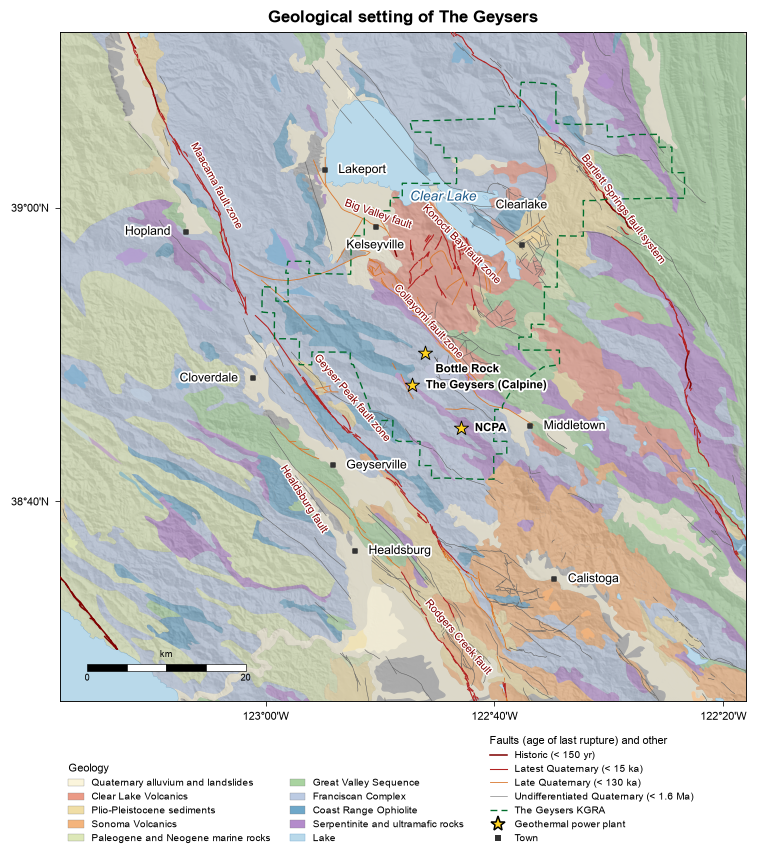

In [7]:
# Which towns to name, out of the 31 in the OpenStreetMap layer, and short forms for the plants.
KEEP_TOWNS = {"Lakeport", "Clearlake", "Kelseyville", "Middletown", "Cloverdale",
              "Geyserville", "Healdsburg", "Calistoga", "Hopland"}
PLANT_NAME = {"Bottle Rock Power": "Bottle Rock", "The Geysers Calpine": "The Geysers (Calpine)",
              "The Geysers NCPA": "NCPA"}
# Where each fault-zone name is anchored, and which side of the trace it sits on.
FAULT_NAMES = {"Maacama fault zone": (-123.080, 39.020, "NE"),
               "Bartlett Springs fault system": (-122.486, 38.992, "NE"),
               "Konocti Bay fault zone": (-122.721, 38.952, "NE"),
               "Big Valley fault": (-122.840, 38.985, "NE"),
               "Collayomi fault zone": (-122.770, 38.865, "NE"),
               "Geyser Peak fault zone": (-122.880, 38.777, "NE"),
               "Healdsburg fault": (-122.935, 38.673, "SW"),
               "Rodgers Creek fault": (-122.726, 38.506, "NE")}
CLEAR_LAKE = (-122.775, 39.032)          # any point inside the lake, to pick out its polygon

W, LEFT = 17.5, 1.3                      # centimetres: full text width, and the left margin
fig, ax = map_figure(REGION, width=W, left=LEFT, right=.35, bottom=3.6, top=.85)
H = fig.get_figheight() / CM             # the height it worked out, in cm, for the legends below
ax.set_title("Geological setting of The Geysers", fontsize=11, fontweight="bold", pad=6)

# 0 · shaded relief, the base every other layer is drawn over
ax.imshow(L["shade"], cmap="gray", extent=L["extent"], origin="lower", vmin=-.55, vmax=1.45,
          interpolation="bilinear", zorder=0)

# 1 · geology: nine classes, one file of polygons each, transparent enough to let the relief through
for i, (unit, colour) in enumerate(GEOLOGY):
    for poly in segments(geo / f"geol_{i}.txt"):
        ax.fill(poly[:, 0], poly[:, 1], facecolor=colour, edgecolor="none", alpha=.62, zorder=1)

# 2 · lakes
for lake in L["water"]:
    ax.fill(lake[:, 0], lake[:, 1], facecolor=LAKE_FILL, edgecolor=LAKE_EDGE, lw=.2, zorder=2)

# 3 · faults, coloured and weighted by the age of the most recent rupture
for filename, label, colour, width in FAULT_AGES:
    for trace in segments(geo / filename):
        ax.plot(trace[:, 0], trace[:, 1], color=colour, lw=width, zorder=3, solid_capstyle="round")

# 4 · the administrative outline of the geothermal field
for seg in segments(geo / "kgra.txt"):
    ax.plot(seg[:, 0], seg[:, 1], color=KGRA_COLOR, lw=.9, ls=(0, (5, 3)), zorder=4)

# 5 · the three power plants and the towns. Each name is collected as it is created, then moved
#     clear of its neighbours at the end, once matplotlib can measure how large it came out.
movable = []
for lon, lat, name in power_plants():
    ax.scatter(lon, lat, s=95, marker="*", c="#ffd320", ec="black", lw=.6, zorder=9)
    text = ax.text(lon, lat, PLANT_NAME.get(name, name), fontsize=7.5, fontweight="bold", zorder=9,
                   path_effects=[pe.withStroke(linewidth=2.4, foreground="white")])
    movable.append((text, (lon, lat)))

lake_name = label_water_body(ax, L["water"], CLEAR_LAKE, "Clear Lake",
                             fontsize=9, style="italic", color="#1f5c8b")
fault_names = label_along_traces(ax, L["faults"], FAULT_NAMES)

for lon, lat, name in towns():
    if name in KEEP_TOWNS:
        ax.scatter(lon, lat, s=8, marker="s", c="#333333", zorder=6)
        text = ax.text(lon, lat, name, fontsize=8, zorder=7,
                       path_effects=[pe.withStroke(linewidth=2.4, foreground="white")])
        movable.append((text, (lon, lat)))

# The labels are moved only now: the placement is measured in pixels, so the map has to be cropped
# to the region and given its projection first.
frame(ax, REGION, xtick=1 / 3, ytick=1 / 3, scale_km=20, scale_loc=(.04, .045))
moved = place_labels(fig, ax, movable, fault_names + [lake_name])

# 6 · two legends in the bottom margin, placed in figure coordinates: rock units on the left at the
#     same margin as the map, everything else starting 63 % of the way across
rocks = [Patch(facecolor=c, edgecolor="gray", lw=.2, label=n) for n, c in GEOLOGY]
rocks.append(Patch(facecolor=LAKE_FILL, edgecolor=LAKE_EDGE, lw=.3, label="Lake"))
leg = fig.legend(handles=rocks, loc="lower left", bbox_to_anchor=(LEFT / W, .12 / H), ncol=2,
                 frameon=False, fontsize=6.3, title="Geology", title_fontsize=7,
                 alignment="left", handlelength=1.6, handleheight=.8)
leg._legend_box.align = "left"

other = [Line2D([], [], color=c, lw=lw, label=n) for _, n, c, lw in FAULT_AGES]
other += [Line2D([], [], color=KGRA_COLOR, lw=.9, ls=(0, (5, 3)), label="The Geysers KGRA"),
          Line2D([], [], color="none", marker="*", mfc="#ffd320", mec="black", ms=10,
                 label="Geothermal power plant"),
          Line2D([], [], color="none", marker="s", mfc="#333333", mec="none", ms=4, label="Town")]
fig.legend(handles=other, loc="lower left", bbox_to_anchor=(.63, .12 / H), ncol=1, frameon=False,
           fontsize=6.3, title="Faults (age of last rupture) and other", title_fontsize=7,
           alignment="left", handlelength=1.8)

print(f"{len(L['faults']):,} fault traces and {len(L['water'])} lakes over {len(GEOLOGY)} geology "
      f"classes; {len(movable)} town and plant labels, {moved} of them moved clear")
plt.show()


**Figure 1. Geological setting of The Geysers.** Surface geology in nine classes over shaded
relief, illuminated from the northwest. Quaternary fault traces are coloured by the age of the most
recent known rupture; the dashed green line is the Known Geothermal Resource Area, an
administrative boundary considerably larger than the producing field; stars mark the three
geothermal power plants and squares the towns. Lakes are taken from the geologic map itself. The
region shown is approximately 90 km across and is centred on the field.


### 1.5 · Reading the map

Each of the three properties set out in § 1.1 can be identified in the figure.

The salmon-coloured **Clear Lake Volcanics** lie immediately north and east of the power plants:
the heat source, adjacent to the field that exploits it. The blue-grey **Franciscan Complex** is
the basement into which the reservoir is drilled, and it occupies most of the map. The long red and
orange lines trending northwest–southeast are the strike-slip systems, and their orientation is the
structural grain of the region as a whole.

That last statement can be made quantitative, and it is worth doing so, because the result is not
quite the one the map invites. Weighting each mapped trace by its length, the mean strike of the
Quaternary faults is **N38°W** over the map region and **N44°W** within the field window. In § 4
the principal axis of the field's epicentres is recovered from the earthquake locations alone,
without reference to this map, and it trends **N57°W**. The seismicity is thus elongated in a
broadly similar direction to the mapped faulting, but it is **not parallel to it**: the two differ
by some 13°.

The discrepancy admits of several readings, and § 1.6 sets out why the map cannot decide between
them. It may indicate structures that the Quaternary database does not represent, since that
database records faults with evidence of recent surface rupture and a reservoir fracture network
need have none. It may reflect the difference between a surface trace and the geometry of the same
structure at depth. Or it may be an artefact of the comparison itself, since the principal axis of
a cloud of epicentres describes the shape of the distribution and is not the strike of any
particular fault. The point to carry forward is that the agreement is approximate, that the
approximation is quantified, and that it is not evidence of the seismicity occurring on the mapped
structures.

The dashed KGRA outline is also considerably larger than the cluster of plants within it: it
encloses approximately 1,150 km², against a field window of 29 by 22 km and a producing area
smaller again. The administrative boundary is not the producing field, and treating the one as the
other is a straightforward route to misstating where the seismicity lies. Every later section uses
the **field window** defined in § 0.4 rather than the KGRA.


### 1.6 · The limits of a compiled map

Two limitations follow from the nature of compiled map products, and both bear on later sections.

**The nine classes represent a grouping made by someone else.** The state geologic map distinguishes
several hundred units; the nine used here are a simplification adopted for legibility, and for a
purpose that was not this one. Two rocks drawn in the same colour may behave quite differently in
the subsurface.

**A fault's colour records the age of its most recent known rupture, not the age of the fault.** A
grey trace is not an inactive structure; it is a structure that has not been dated. Absence of
evidence is here rendered in a colour readily mistaken for evidence of absence.

The second limitation becomes concrete on **clustering**, when planes fitted to the three-dimensional
distribution of earthquakes are compared with these traces. A recovered plane corresponding to no
mapped fault may represent a genuine unmapped structure, a mapped fault whose surface trace is
offset from its position at depth, or an artefact of the fitting procedure. **The map cannot
distinguish between these three possibilities**, and an analysis that treats it as ground truth
selects one of them implicitly.


#### Sources and further reading

The layers drawn in Figure 1 are redistributions of public products, cut to this region. Any work
that uses them should cite the originals.

* Horton, J. D., San Juan, C. A., & Stoeser, D. B. (2017). *The State Geologic Map Compilation
  (SGMC) geodatabase of the conterminous United States*. U.S. Geological Survey Data Series 1052.
  `10.3133/ds1052` — the rock units, regrouped here from several hundred units into nine classes,
  and the lake polygons.
* Schmitt, R. G., Gold, R. D., & Geologic Hazards Science Center (2020). *Quaternary Fault and Fold
  Database for the Nation*. U.S. Geological Survey. `10.5066/P9BCVRCK` — the fault traces and the
  four age classes of § 1.3.
* OpenStreetMap contributors. © OpenStreetMap contributors, available under the Open Database
  Licence — the towns and the power plants.
* AWS Terrain Tiles (Terrarium encoding, zoom level 12, approximately 30 m ground sampling) — the
  elevation model and the shaded relief derived from it.
* California State Geoportal, *Geothermal Resource Potential by Field* — the Known Geothermal
  Resource Area outline.

None of these is required reading. The properties of the region on which the later sections depend
are stated in § 1.1 and § 1.6.


## § 2 · Production and injection history

*This section establishes the forcing: the complete monthly record of steam production and water
injection for the field from 1969 to 2026, the verification that its units are what they are said
to be, and the resolution beyond which the record cannot be interrogated.*

### 2.1 · What is being recorded, and why it exists

Two quantities are measured at a geothermal field, and both are masses of fluid crossing the
ground surface.

**Production** is the mass of steam raised from the production wells and delivered to the turbines.
It is the quantity the field is operated to maximise, and it is metered because it is the basis on
which the resource is taxed and the electricity sold.

**Injection** is the mass of water returned to the reservoir through the injection wells. Part of
it is the field's own condensate, the fraction of the produced steam that is recovered at the
plants rather than lost to the cooling towers. Since the late 1990s the remainder has been treated
municipal wastewater imported from the surrounding towns, which is the field's principal means of
arresting the loss of reservoir mass described in § 0.1.

Neither quantity is a scientific measurement. Both are regulatory returns, filed monthly by the
operator with the state, and their existence is a matter of administrative law rather than of
experimental design. That is the central fact about this dataset, and it accounts for both its
strength and its limitations. Its strength is that it is complete, uniform and long: the record
used here comprises 691 consecutive months from January 1969, with no month missing and only four
in which no injection is reported, which is a continuity no research programme would have funded.
Its limitations are examined in § 2.6.

The scale of the operation is worth fixing before the record is examined. Annual steam production
reached a maximum of 111.8 Mt in 1987 and stood at 49.6 Mt in 2025, a decline of somewhat more
than half. This is the depletion referred to in § 0.1, and the injection history is the response
to it.

That response took the form of two pipelines, and both exist because two unrelated problems met.
The field needed injection water it could not obtain locally, while Lake County and, later, the
city of Santa Rosa needed somewhere to send treated municipal wastewater. The **Southeast Geysers
Effluent Pipeline** began delivering in October 1997, carrying effluent 29 miles from four
treatment plants serving ten Lake County communities, and more than doubled injection in the
southeast of the field. The **Santa Rosa Geysers Recharge Project** followed in late 2003, a
42-mile line from that city's treatment plant which raised injection by a further 40 per cent.
Both are marked on the figures below.


### 2.2 · The CalGEM monthly record

The record is compiled by the **California Geologic Energy Management Division** (CalGEM), the
division of the California Department of Conservation which regulates oil, gas and geothermal
operations in the state. CalGEM publishes field-wide monthly production and injection totals.


In [8]:
import pandas as pd

cal = pd.read_csv("https://github.com/AI4EPS/EPS207_Observational_Seismology/"
                  "releases/download/data-2026fall/geysers_injection_production_1969-2026.csv")
cal["date"] = pd.to_datetime(dict(year=cal.year, month=cal.month, day=1))

print(cal.head(3).to_string(index=False))
print(f"\n{len(cal)} monthly rows, {cal.date.min():%Y-%m} to {cal.date.max():%Y-%m}")


 year  month  production_t  injection_t note       date
 1969      1      541739.0          0.0  NaN 1969-01-01
 1969      2      415455.0          0.0  NaN 1969-02-01
 1969      3      556928.0          0.0  NaN 1969-03-01

691 monthly rows, 1969-01 to 2026-07


### 2.3 · Unit verification: a column name is not its meaning

The two data columns are named `production_t` and `injection_t`. The suffix asserts tonnes. That
assertion was made by whoever prepared this file, and it is worth examining, because CalGEM's own
workbook labels the corresponding column *"kilograms times 1,000"* — a phrase which does denote a
tonne, but which requires one arithmetical step to see, and a step of that kind is exactly where an
error of three orders of magnitude enters.

The consequence of accepting the label without examination is not an error message. It is a
published number wrong by a factor of a thousand, in a direction that depends on which way the
mistake was made. The remedy is to test the column against a quantity known independently of the
file. A field supplying turbines of the order of a gigawatt must move steam in tens of megatonnes
per year; and injection, being condensate plus imported water, must be smaller than production
without being negligible beside it.


In [9]:
ann = cal.groupby("year")[["production_t", "injection_t"]].sum() / 1e6      # tonnes -> megatonnes
recent = ann.loc[2005:2025]

print(f"annual production: maximum {ann.production_t.max():.1f} Mt in {ann.production_t.idxmax()}, "
      f"{ann.production_t.loc[2025]:.1f} Mt in 2025\n")
print("2005–2025, megatonnes per year")
print(f"  production  {recent.production_t.min():5.1f} – {recent.production_t.max():5.1f}")
print(f"  injection   {recent.injection_t.min():5.1f} – {recent.injection_t.max():5.1f}")
print(f"  injection / production, mean  {(recent.injection_t / recent.production_t).mean():.2f}")


annual production: maximum 111.8 Mt in 1987, 49.6 Mt in 2025

2005–2025, megatonnes per year
  production   47.2 –  61.6
  injection    31.1 –  54.1
  injection / production, mean  0.78


Both tests are passed. Production is a few tens of megatonnes per year and injection is a large
but sub-unity fraction of it, so the suffix denotes tonnes. Had the column held kilograms, the
annual totals would have emerged in tens of kilotonnes, which would not run a power station; had it
held the raw workbook figure, they would have been a thousand times too large.

The test is weak in the sense that it distinguishes only between hypotheses separated by three
orders of magnitude. That is nevertheless the error that occurs in practice, and a weak test that
is actually performed is worth more than a strong one that is not.

**A column name is not its meaning.** This is the second of the three instances noted in § 1.3: in
§ 1 the unreliable identifier was a file name, here it is a column name, and in § 8 it will be a
column position.


### 2.4 · The record

The figure below plots both series at their native monthly resolution over the whole record. The
two dashed lines mark the wastewater pipelines: the Southeast Geysers Effluent Pipeline (SEGEP),
commissioned in 1997, and the Santa Rosa Geysers Recharge Project (SRGRP), commissioned in
December 2003.


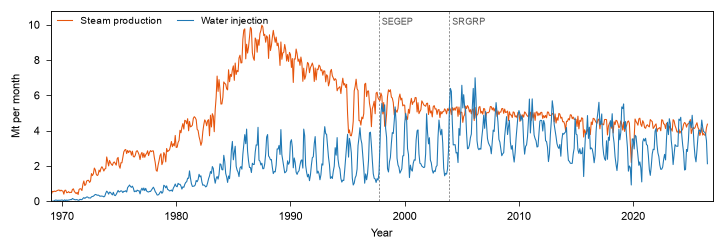

In [10]:
import matplotlib.pyplot as plt

C_PROD, C_INJ = "#e6550d", "#1f78b4"                 # the publication colours, kept throughout
PIPES = [("1997-10-01", "SEGEP"), ("2003-12-01", "SRGRP")]   # the two wastewater pipelines

fig, ax = plt.subplots(figsize=(17 * CM, 5.5 * CM))
fig.subplots_adjust(left=0.085, right=0.985, top=0.97, bottom=0.17)
ax.plot(cal.date, cal.production_t / 1e6, color=C_PROD, lw=0.7, label="Steam production")
ax.plot(cal.date, cal.injection_t / 1e6, color=C_INJ, lw=0.7, label="Water injection")

for date, name in PIPES:
    ax.axvline(pd.Timestamp(date), color="#777777", lw=0.5, ls=(0, (3, 2)), zorder=0)
    ax.text(pd.Timestamp(date) + pd.Timedelta(days=90), 10.4, name,
            fontsize=6, color="#555555", va="top", ha="left")

ax.set(xlabel="Year", ylabel="Mt per month", ylim=(0, 10.8),
       xlim=(pd.Timestamp("1969-01-01"), pd.Timestamp("2027-01-01")))
ax.legend(frameon=False, loc="upper left", ncol=2, fontsize=6.5,
          handlelength=1.6, columnspacing=1.5, borderaxespad=0.2)
plt.show()


**Figure 2. Monthly steam production and water injection at The Geysers, 1969–2025.** Field-wide
totals in megatonnes per month, from the CalGEM regulatory record. Dashed lines mark the
commissioning of the two wastewater pipelines.

Production rises to a maximum in the late 1980s and declines thereafter. Injection has a different
form. It is present from the first month of the record, because condensate has always been
returned, and what changes over the record is the fraction of the produced mass that is replaced.
That fraction is the quantity to follow, and it is set out by decade below.


In [11]:
eras = {"1970s": (1970, 1979), "1980s": (1980, 1989), "1990s": (1990, 1999),
        "2000s": (2000, 2009), "2010–26": (2010, 2026)}

rows = []
for name, (lo, hi) in eras.items():
    e = ann.loc[lo:hi]
    rows.append({"era": name,
                 "production (Mt/yr)": e.production_t.mean(),
                 "injection (Mt/yr)": e.injection_t.mean(),
                 "injected / produced": (e.injection_t / e.production_t).mean()})
print(pd.DataFrame(rows).round(2).to_string(index=False))


    era  production (Mt/yr)  injection (Mt/yr)  injected / produced
  1970s               23.66               5.23                 0.21
  1980s               81.63              22.59                 0.27
  1990s               76.13              29.85                 0.41
  2000s               61.64              41.97                 0.68
2010–26               51.55              40.01                 0.78


The replaced fraction rises from 0.21 in the 1970s to 0.78 in the present decade, a factor of
approximately four. The increase is not gradual. Comparing the three years before and after each
pipeline, the ratio moves from 0.40 to 0.53 across SEGEP and from 0.53 to 0.83 across SRGRP, so the
two imports account for the greater part of the change. The remainder is condensate return, which
has been present throughout.

The distinction matters for the interpretation of § 10. Condensate return is proportional to
production and therefore carries the same long-term trend; imported wastewater is not, and is
governed instead by the municipal wastewater supply. The injection series is the sum of a term
that follows production and a term that does not.


### 2.5 · The annual cycle

The most useful feature of this record is not its trend but its **seasonality**, which is plainly
visible in the injection curve. Expressing each month as a percentage deviation from a
thirteen-month centred running mean, and averaging over 2004–2025, isolates the repeating annual
component from the long-term change.


In [12]:
d = cal.set_index("date")[["production_t", "injection_t"]].loc["2004":"2025"].copy()
for c in d:
    d[c] = 100 * (d[c] / d[c].rolling(13, center=True).mean() - 1)
season = d.groupby(d.index.month).mean().round(1)
season.index.name = "month"

print(season.to_string())
print(f"\ninjection  {season.injection_t.min():+.0f} % (month {season.injection_t.idxmin()}) "
      f"to {season.injection_t.max():+.0f} % (month {season.injection_t.idxmax()})")
print(f"production {season.production_t.min():+.0f} % to {season.production_t.max():+.0f} %")


       production_t  injection_t
month                           
1               0.4         34.9
2              -8.0         23.6
3               1.1         30.2
4              -3.3         10.6
5               0.9         -6.1
6              -0.9        -20.1
7               6.3        -30.5
8               6.6        -31.5
9               0.4        -26.6
10             -0.5        -10.4
11             -3.6          2.5
12              0.4         26.7

injection  -32 % (month 8) to +35 % (month 1)
production -8 % to +7 %


Injection swings by roughly a third about its running mean, from approximately −32 per cent in
August to +35 per cent in January. Production varies by less than a tenth over the same cycle. The
asymmetry is the signature of the imported component: the volume of treated wastewater available
for disposal is greatest in the wet winter months and least in late summer, whereas the demand for
steam, and therefore production, is comparatively steady.

This is the single most valuable property of the dataset for the purpose of § 10. A monotonic
trend in the forcing can produce a spurious correlation with any other trending series, and no
amount of care in fitting will separate the two. A periodic component cannot be manufactured in
that way: if the seismicity rate carries the same twelve-month period, with a plausible lag, that
is evidence of a different kind. Section 10 tests exactly this, against a null hypothesis
constructed to destroy the periodicity while preserving the trend.


### 2.6 · What the record cannot resolve

These are **field-wide monthly totals**, and three consequences follow directly.

There is **no spatial resolution**. The file records no well identifiers, no coordinates and no
injection depths, so no question of the form *which well is associated with which earthquakes* can
be posed with these data. Per-well records exist in California's WellSTAR system; they are not part
of this course, and any analysis in § 10 or in the final project is therefore an analysis of the
field as a single object.

There is **no temporal resolution below one month**. Processes with shorter characteristic times —
the response of pore pressure to the start of injection at a particular well, for instance — are
invisible in principle, not merely undetected.

And the two series are **not independent**. Condensate return couples injection to production, so a
correlation between injection and seismicity may be inherited from a correlation with production.
Section 10 addresses this by testing the two series separately and by comparing their seasonal
components, which differ, rather than their trends, which do not.


#### Sources

* California Geologic Energy Management Division (CalGEM), California Department of Conservation.
  Monthly geothermal production and injection reports for The Geysers field. Distributed with this
  course as `geysers_injection_production_1969-2026.csv` after conversion from the published
  workbook; the column units are verified in § 2.3.
* Lake County, California. *Pipeline History*, on the Southeast Geysers Effluent Pipeline —
  <https://www.lakecountyca.gov/976/Pipeline-History>
* City of Santa Rosa and Calpine Corporation. *Santa Rosa Geysers Recharge Project* —
  <https://digital.library.unt.edu/ark:/67531/metadc886930/>
* Geothermal Resources Council. *The Geysers Geothermal Field Update 1990–2010*, Special Report
  No. 20 — <https://www.osti.gov/servlets/purl/1048267>


## § 3 · Seismic instrumentation and data availability

*This section establishes the observing system: which instruments have operated in the region,
which type of instrument each one carries, where they stand, and — separately, and not
identically — the period over which their recordings can actually be obtained.*

### 3.1 · Why the instruments come before the data

Earthquakes are not observed. Ground motion is observed, at a finite number of points on the
surface and in a few boreholes, by instruments with particular sensitivities over particular
periods of time. Every quantity derived later in this notebook — an arrival time, a magnitude, a
focal mechanism, the completeness of a catalogue — is a property of that observing system as much
as of the Earth. A catalogue that contains no earthquakes below magnitude 1 in 1985 and thousands
of them in 2015 is not describing a change in the Earth.

A **seismic station** is an instrument installed at a fixed point which records ground motion
continuously. A **seismometer** measures the velocity of the ground; an **accelerometer**, used
where the shaking is strong enough to saturate a seismometer, measures its acceleration. Each
records along three orthogonal directions, conventionally vertical, north and east, and each
direction is a separate **channel**. Stations are grouped into **networks**, which are the
organisations that operate them, and a channel is identified everywhere in seismology by the
four-part code `NETWORK.STATION.LOCATION.CHANNEL`.

Five networks contribute, and the distinctions between them govern what can be measured.

**BG** is the borehole network installed within the producing field by the geothermal operators.
Its sensors are emplaced below the weathered near-surface layer and lie within a few kilometres of
the earthquakes themselves. This proximity is the reason the catalogue of § 4 extends below
magnitude zero, and it is unusual: most seismicity is observed from far greater distances.

**NC** is the Northern California Seismic Network, the regional network operated by the U.S.
Geological Survey. It consists largely of short-period sensors at the surface and provides the long
baseline, extending back decades before the borehole network existed.

**BK** is the Berkeley Digital Seismic Network: broadband instruments, sparse, sensitive over a
much wider band of periods than the short-period sensors.

**NP** and **CE** contribute strong-motion accelerometers, which do not saturate in strong shaking
and are therefore the instruments of record for the largest events.


### 3.2 · The station inventory, retrieved live

Station metadata are distributed through an **FDSN station web service**. FDSN is the
International Federation of Digital Seismograph Networks, and its web-service specification is
implemented by essentially every data centre, so the same query works against the NCEDC, the
USGS, IRIS or a European archive with only the server name changed. `obspy` provides a client for
it.

This is the one route in this section that is not a hosted file. A metadata query returns in a few
seconds, and the answer changes as stations are installed and decommissioned, so there is nothing
to be gained by freezing it.


In [13]:
import pandas as pd
from obspy.clients.fdsn import Client

inv = Client("NCEDC", timeout=120).get_stations(
    level="channel", minlongitude=-123.30, maxlongitude=-122.30,
    minlatitude=38.44, maxlatitude=39.20)                       # the download box of § 0.4

rows = [{"net": net.code, "sta": sta.code, "cha": c.code, "sps": c.sample_rate,
         "start": pd.Timestamp(str(c.start_date)).tz_localize(None),
         "end": pd.Timestamp(str(c.end_date)).tz_localize(None) if c.end_date else pd.NaT}
        for net in inv for sta in net for c in sta]
cha = pd.DataFrame(rows)

BAND = {"DP": "short-period, borehole", "EH": "short-period", "HH": "broadband, 100 sps",
        "BH": "broadband, 20–40 sps", "HN": "strong motion", "HL": "strong motion"}
cha["kind"] = cha.cha.str[:2].map(BAND)

print(f"{len(cha):,} channels at {cha.groupby(['net', 'sta']).ngroups} stations\n")
print(cha.dropna(subset=["kind"]).groupby(["kind", "net"]).sta.nunique()
      .unstack(fill_value=0).to_string())


4,983 channels at 143 stations

net                     BG  BK  CE  NC  NP
kind                                      
broadband, 100 sps       0   9   0   8   0
broadband, 20–40 sps     0   9   0   0   0
short-period             0   0   0  55   0
short-period, borehole  44   0   0   0   0
strong motion            0   9   9  29  11


The three-letter channel code is not arbitrary. Its first letter encodes the sampling rate and the
instrument's band, its second the type of sensor, and its third the direction of motion recorded.
Thus `DPZ` is the vertical component of a borehole short-period geophone, `HHZ` that of a
broadband seismometer sampled at 100 Hz, and `HNZ` that of an accelerometer. The convention is
defined by the SEED standard and is used unchanged by every data centre.

The distinction is not bookkeeping. A short-period geophone has a mechanical resonance at the
lower edge of its usable band — 1 Hz for the sensors of the regional network here — and below that
frequency its output falls away rapidly. Section 5.5 shows that resonance being mistaken for a
property of the ground, and § 7 removes it. An accelerometer
records a different physical quantity altogether, so an amplitude read from one cannot be compared
with an amplitude read from the other until both have been converted to a common quantity.


### 3.3 · Where the stations are

The figure below shows every station site that recorded within the study region during the
catalogue span, and, at larger scale, the field itself with each station labelled. Symbol shape
and colour give the instrument class and a hollow symbol marks a station that had closed by the
end of the span. The dense cluster of small black points in the second panel is a temporary
91-node array deployed by the California Energy Commission between 2018 and 2024.

Two details of the drawing are worth naming before the code is read. The relief is drawn opaque
and the geology of § 1 laid over it at 52 per cent opacity, so that the stations are read against a
recognisable version of the same base map; and `place_codes()` merges station codes whose symbols
would overlap into a single label before placing them, because at the scale of the field several
sites are separated by less than the width of their own codes.


81 station sites: {'BG': 37, 'short-period': 19, 'broadband': 13, 'strong-motion': 12}
11 closed within the span; 49 inside the field
codes placed: 32 labels in (a) (3 moved), 48 in (b) (6 moved)


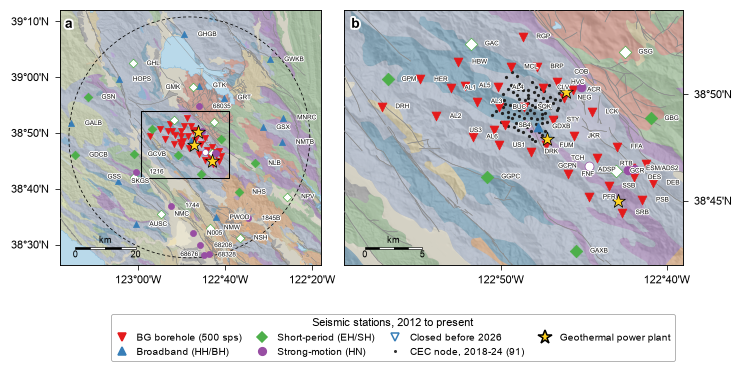

In [14]:
# Shape and colour identify the instrument class; a hollow symbol means the station has closed.
CLASS = {"BG": ("v", "#e41a1c", "BG borehole (500 sps)"),
         "broadband": ("^", "#377eb8", "Broadband (HH/BH)"),
         "short-period": ("D", "#4daf4a", "Short-period (EH/SH)"),
         "strong-motion": ("o", "#984ea3", "Strong-motion (HN)")}
PLANT_STAR = dict(marker="*", s=90, facecolor="#ffd320", edgecolor="black", lw=.5, zorder=7)

site, L, nodes = sites(), layers(), cec()
geo = DATA / "geo"

TOT, GAPX, LFT, RGT = 17.0, .55, 1.15, 1.45           # centimetres
WIN = TOT - LFT - RGT
WA, WB, HA = two_panels(WIN, GAPX, REGION, FIELD)     # equal height, each panel its own true width
H = .3 + HA + 2.4                                     # 2.4 cm at the foot for the legend
fig = plt.figure(figsize=(TOT * CM, H * CM))
axa = fig.add_axes([LFT / TOT, 2.4 / H, WA / TOT, HA / H])
axb = fig.add_axes([(LFT + WA + GAPX) / TOT, 2.4 / H, WB / TOT, HA / H])

# Base map in both panels: relief, then geology over it, then water and faults again on top so that
# they are not lost under the semi-transparent geology fills.
for ax, region, fault_lw in ((axa, REGION, .25), (axb, FIELD, .35)):
    basemap(ax, L, region, fault_lw=fault_lw, shade_alpha=1.0, shade_lo=-.55, shade_hi=1.45)
    geology(ax, geo, alpha=.52)
    for lake in L["water"]:
        ax.fill(lake[:, 0], lake[:, 1], facecolor=LAKE_FILL, edgecolor=LAKE_EDGE, lw=.2, zorder=2)
    for trace in L["faults"]:
        ax.plot(trace[:, 0], trace[:, 1], color="#8c8c8c", lw=fault_lw, zorder=3)

# Panel (a) carries the 40 km study circle and the outline of panel (b).
theta = np.linspace(0, 2 * np.pi, 361)
axa.plot(CENTER[1] + RADIUS_KM / KM_LON * np.cos(theta),
         CENTER[0] + RADIUS_KM / KM_LAT * np.sin(theta),
         color="black", lw=.5, ls=(0, (4, 3)), zorder=4)
axa.plot([FIELD[0], FIELD[1], FIELD[1], FIELD[0], FIELD[0]],
         [FIELD[2], FIELD[2], FIELD[3], FIELD[3], FIELD[2]], color="black", lw=.7, zorder=5)
axb.scatter(nodes.lon, nodes.lat, s=4.5, c="#222222", lw=0, zorder=4)

# The stations themselves, split by class and by whether they were still open at the end of the span.
for ax, size in ((axa, 16), (axb, 34)):
    for klass, (marker, colour, _) in CLASS.items():
        for still_open, face in ((True, colour), (False, "white")):
            s = site[(site.klass == klass) & (site.open == still_open)]
            if len(s):
                ax.scatter(s.lon, s.lat, s=size, marker=marker, facecolor=face,
                           edgecolor=colour, lw=.45, zorder=6)
    for plant_lon, plant_lat in L["plants"]:
        ax.scatter(plant_lon, plant_lat, **PLANT_STAR)

in_field = site.lat.between(*FIELD[2:]) & site.lon.between(*FIELD[:2])
n_b, moved_b = place_codes(axb, site[in_field].lon, site[in_field].lat, site[in_field].Station)
n_a, moved_a = place_codes(axa, site[~in_field].lon, site[~in_field].lat, site[~in_field].Station)

degree_minute_ticks(axa, .3333333, .1666667); scale_bar_gmt(axa, 20)
degree_minute_ticks(axb, .1666667, .0833333, right=True); scale_bar_gmt(axb, 5)
for k, ax in enumerate((axa, axb)):
    ax.text(.02, .97, "ab"[k], transform=ax.transAxes, fontsize=9, fontweight="bold", va="top",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

handles = [Line2D([], [], color="none", marker=m, mfc=c, mec=c, ms=5, label=lab)
           for m, c, lab in CLASS.values()]
handles += [Line2D([], [], color="none", marker="v", mfc="white", mec="#377eb8", ms=5,
                   label="Closed before 2026"),
            Line2D([], [], color="none", marker=".", mfc="#333333", mec="none", ms=4,
                   label="CEC node, 2018-24 (91)"),
            Line2D([], [], color="none", marker="*", mfc="#ffd320", mec="black", ms=9,
                   label="Geothermal power plant")]
leg = fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(.52, .06 / H), ncol=4,
                 frameon=True, fontsize=6.5, handlelength=1.4, columnspacing=1.4,
                 title="Seismic stations, 2012 to present", title_fontsize=7.5)
leg.get_frame().set_linewidth(.5); leg.get_frame().set_edgecolor("#888888")

print(f"{len(site)} station sites: {site.klass.value_counts().to_dict()}")
print(f"{int((~site.open).sum())} closed within the span; {int(in_field.sum())} inside the field")
print(f"codes placed: {n_a} labels in (a) ({moved_a} moved), {n_b} in (b) ({moved_b} moved)")
plt.show()


**Figure 3. Seismic stations of the study region and of the field.** (a) All station sites within
the 40 km study region (dashed circle), on shaded relief with the geology of Figure 1 and the
Quaternary faults in grey; the black rectangle is the field window shown in (b). (b) The field,
with every station code. Symbol shape and colour give the instrument class and hollow symbols mark
stations closed before 2026; small black points are the 91 nodes of the temporary California Energy
Commission array; stars are the geothermal power plants.

The geometry in panel (a) is the reason this field is unusually favourable and, at the same time,
unrepresentative. The borehole network sits directly above the seismicity, a few kilometres from
the sources, while the regional stations stand tens of kilometres away. Detection threshold
improves as the distance to the nearest station falls, so the catalogue here reaches below
magnitude zero, where an area monitored only at regional distances is typically complete
above magnitude 1.5 to 2.
A method calibrated on this catalogue is calibrated on an observing geometry that few other regions
possess.


### 3.4 · Instrument metadata are not a record of data availability

The inventory retrieved in § 3.2 gives, for every channel, the date on which it was **installed**
and the date on which it was decommissioned. It is natural to read those dates as the interval over
which data may be requested. They are not.

Metadata describe the instrument. The archive records what was actually digitised, transmitted,
retained and eventually published, and these are different histories, separated by telemetry
failures, by changes of policy about what is kept, and by the interval between a network beginning
to operate and its data being contributed to a public archive. The failure mode is silent: a
request for a day on which an instrument was running but nothing was archived returns an empty
stream, not an error.

The months in which each station has continuous files on the NCEDC public archive were established
once by scanning the archive directly, and the result is distributed with this course. The scan
takes approximately twenty-five minutes, which is why it is not repeated here.


In [15]:
cov = coverage()
first_data = cov.groupby(["net", "sta"]).t.min().rename("first_archived")
gap = site.join(first_data, on=["Network", "Station"])
gap["metadata_first"] = pd.to_datetime(gap["first"])
gap["years_of_gap"] = (gap.first_archived - gap.metadata_first).dt.days / 365.25

print("first archived month, by network:")
print(cov.groupby("net").t.min().dt.strftime("%Y-%m").to_string())
print(f"\nstations with metadata but no archived continuous data at all: "
      f"{gap.first_archived.isna().sum()} of {len(gap)}\n")
print("largest gaps between installation and first archived month:")
print(gap.nlargest(5, "years_of_gap")[["Network", "Station", "metadata_first",
                                       "first_archived", "years_of_gap"]].to_string(index=False))

bg = cov[cov.net == "BG"]
print("\nBG stations with archived data, by year:")
print(bg.groupby(bg.t.dt.year).sta.nunique().loc[2009:2015].to_string())


first archived month, by network:
net
BG    2010-03
BK    1986-10
CE    2006-03
NC    1993-11
NP    2001-06

stations with metadata but no archived continuous data at all: 7 of 81

largest gaps between installation and first archived month:
Network Station      metadata_first first_archived  years_of_gap
     CE   68035 2000-08-22 00:00:00     2026-04-01     25.607118
     CE   68328 2006-10-03 00:00:00     2026-04-01     19.493498
     NP    1744 2001-11-27 18:00:00     2019-03-01     17.253936
     CE   68208 2007-07-16 00:00:00     2018-06-01     10.877481
     BG     AL2 2004-11-17 00:00:00     2012-04-01      7.370294

BG stations with archived data, by year:
t
2010     2
2012    33
2013    32
2014    34
2015    35


The result should be read in the order that matters for this field. **The borehole network, which
is the reason the catalogue reaches below magnitude zero, has the shortest continuous archive of
any of them.** The regional network reaches back furthest. The interval with the greatest number
of stations is therefore not the interval with the longest record, and any analysis that requires
both dense coverage and a long baseline must trade one against the other explicitly.

The final table qualifies the first. The earliest archived month for BG is 2010, but that month
contains two stations; the network appears as a block in 2012 and persists thereafter. The
statements *data begin in 2010* and *the borehole network begins in 2012* are both true and answer
different questions, and which of them is the correct answer depends on how many stations an
analysis requires.

**The network is not the archive.** Before an analysis is planned over any time window, coverage
should be checked; the explanation for a detector that finds nothing in a given year is more often
found here than in the Earth.


75 station rows; 7 with metadata but no file on the archive: ['CE.68676', 'NC.N005', 'NP.1216', 'NP.ADS2', 'NP.ADSP', 'NP.COB', 'NC.GCPN']


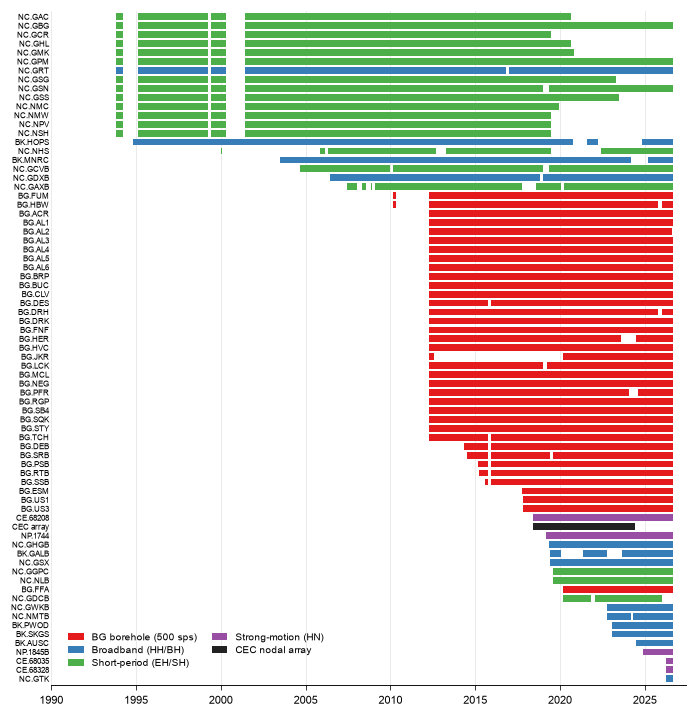

In [16]:
# One horizontal bar per station, drawn where the archive actually holds files, ordered by when
# each station's data begin. The months are merged into continuous spans first, since a bar per
# month would be indistinguishable from a bar per span at this scale.
COL = {"BG": "#e41a1c", "broadband": "#377eb8", "short-period": "#4daf4a",
       "strong-motion": "#984ea3", "CEC": "#222222"}
LABEL = {"BG": "BG borehole (500 sps)", "broadband": "Broadband (HH/BH)",
         "short-period": "Short-period (EH/SH)", "strong-motion": "Strong-motion (HN)",
         "CEC": "CEC nodal array"}
NOW = pd.Timestamp("2026-09-06")

bars, missing = [], []
for r in site.itertuples():
    months = cov[(cov.net == r.Network) & (cov.sta == r.Station)].t.sort_values()
    if months.empty:
        missing.append(f"{r.Network}.{r.Station}")
        continue
    spans = merge_intervals([(t, t + pd.DateOffset(months=1)) for t in months],
                            pd.DateOffset(months=1))
    bars.append(dict(name=f"{r.Network}.{r.Station}", klass=r.klass,
                     first=spans[0][0], spans=[(a, min(b, NOW)) for a, b in spans]))
bars.append(dict(name="CEC array", klass="CEC", first=pd.Timestamp("2018-06-01"),
                 spans=[(pd.Timestamp("2018-06-01"), pd.Timestamp("2024-05-31"))]))
bars.sort(key=lambda r: (r["first"], r["name"]))

# The axis begins where the archive does, not where the networks do: drawing only archived data
# leaves everything before the early 1990s empty.
y0 = min(r["spans"][0][0] for r in bars).year // 5 * 5
W = 17.0
H = 1.05 + 0.205 * len(bars)
fig = plt.figure(figsize=(W * CM, H * CM))
ax = fig.add_axes([2.05 / W, 0.55 / H, (W - 2.35) / W, (H - 0.85) / H])

for year in range(y0, 2030, 5):
    ax.axvline(pd.Timestamp(f"{year}-01-01"), color="#dddddd", lw=.4, zorder=0)
for i, r in enumerate(bars):
    for a, b in r["spans"]:
        ax.add_patch(Rectangle((a, i - .38), b - a, .76, facecolor=COL[r["klass"]],
                               ec="none", zorder=2))

ax.set_yticks(range(len(bars)))
ax.set_yticklabels([r["name"] for r in bars], fontsize=5.2)
ax.tick_params(axis="y", length=0, pad=1.5)
ax.set_ylim(len(bars) - .3, -.7)                        # earliest station at the top
ax.set_xlim(pd.Timestamp(f"{y0}-01-01"), pd.Timestamp("2027-06-01"))
ax.set_xticks([pd.Timestamp(f"{y}-01-01") for y in range(y0, 2030, 5)])
ax.set_xticklabels([str(y) for y in range(y0, 2030, 5)])
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)

# Stations are ordered by first data, so the lower left of the panel is empty by construction and
# the legend costs nothing there.
ax.legend(handles=[Patch(facecolor=COL[k], label=LABEL[k]) for k in COL],
          loc="lower left", bbox_to_anchor=(.012, .012), ncol=2, frameon=False,
          fontsize=6.5, handlelength=1.6, handleheight=.7, columnspacing=1.5, labelspacing=.35)

print(f"{len(bars)} station rows; {len(missing)} with metadata but no file on the archive: {missing}")
plt.show()


**Figure 4. Months in which each station has continuous waveform files on the NCEDC archive.**
One row per station, ordered by the date its archived data begin, coloured by instrument class.
Only archived data are drawn: the station metadata epochs, which begin earlier, are the subject of
§ 3.2 and the difference between the two is the point of § 3.4.

One limitation of the figure should be stated, because it would otherwise be read as a stronger
claim than it is. Continuous data are scarce before the 1990s, but **event waveforms** — short
windows cut around catalogue events and archived separately — extend back to 1984. Section 5 uses
both routes. Absence from one route is not absence from the archive.


### 3.5 · Data outside the standard services

The nodal array visible in panel (b) of Figure 3 is in **no FDSN service at all**. It exists as
assembled files under `ncedc.org/pub/assembled/geysersCEC/`, retrievable only by an HTTP request
for a range of bytes within a file.

The observation generalises, and it is the counterpart of § 3.4. A search of the web services is
not a search of the data. A client that returns nothing has established that the service holds
nothing, which is a weaker statement than it appears, and concluding from it that the data do not
exist is a test of the client rather than of the archive.


#### Sources

* Northern California Earthquake Data Center (2014). *Northern California Earthquake Data Center*.
  UC Berkeley Seismological Laboratory. Dataset. `10.7932/NCEDC` — the station inventory retrieved
  in § 3.2, the continuous-waveform archive scanned for § 3.4, and the networks BG, NC, BK, NP
  and CE.
* The station coverage table and the nodal-array positions are distributed with this course as
  `geysers_archive_coverage.csv.gz` and are derived from that archive.


## § 4 · The earthquake catalogue

*This section establishes the earthquake catalogue for the region: what each of its columns
means, which of them are measurements, how the same catalogue can be obtained by three different
routes that do not return the same thing, and how to define a working subset whose selection
effects are known.*

### 4.1 · What a catalogue is, and what it is not

An **earthquake catalogue** is a table with one row per earthquake. The columns of any catalogue
include, at a minimum, the **origin time** — the instant at which slip began — and the
**hypocentre**, the point at which it began, given as a latitude, a longitude and a depth. The
projection of the hypocentre onto the surface is the **epicentre**, which is what a map of
seismicity shows. A **magnitude** completes the description of size.

None of these quantities is observed. What is observed is ground motion at a set of stations. The
origin time and hypocentre are the parameters of a model fitted to the arrival times of seismic
waves at those stations, using an assumed velocity structure for the rock the waves travelled
through; the magnitude is computed from an amplitude by a formula that is itself a convention.
Sections 6, 7 and 8 examine each of those steps in turn. A catalogue is therefore the **end of a
processing chain**, and its rows record the results of that chain without recording how much of
each result was measured and how much assumed.

The catalogue used here is produced by the Northern California Seismic Network, whose stations
were described in § 3, and is distributed by the Northern California Earthquake Data Center. It
is a *routine* catalogue, meaning that it is produced continuously and automatically as data
arrive, with human review of the larger events. It is not a research product, and no part of it
has been optimised for the questions asked in this course.


### 4.2 · Three routes to the same catalogue

The same catalogue can be obtained in at least three ways. They are described here not for
completeness but because they do not return the same thing, and the reason they differ is a
property of scientific data access in general rather than of this catalogue in particular.

#### Route one: the FDSN event web service

The FDSN specification introduced in § 3.2 defines an `event` service alongside the `station`
service used there. It accepts a time window and a geographic box and returns the matching events.
It is the route most users reach for first, and `obspy` provides a client for it. The window asked
for below is the first half of 2025: the service answers in proportion to the window it is given,
and six months of this region is already enough to expose what the next two cells are about.


In [17]:
import numpy as np
import pandas as pd
from obspy import UTCDateTime
from obspy.clients.fdsn import Client

BOX = dict(minlongitude=-123.30, maxlongitude=-122.30, minlatitude=38.44, maxlatitude=39.20)
WINDOW = ("2025-01-01", "2025-07-01")     # the first half of 2025

cat = Client("NCEDC", timeout=300).get_events(
    starttime=UTCDateTime(WINDOW[0]), endtime=UTCDateTime(WINDOW[1]), **BOX)
n_fdsn = len(cat)
print(f"FDSN event service, {WINDOW[0]} to {WINDOW[1]}: {n_fdsn:,} events")

# Only the count is needed below. Ten thousand obspy `Event` objects cost roughly 350 MB to parse
# and 70 MB to keep, and a hosted notebook is commonly capped at 1 GB for everything it does, so
# the catalogue is released here rather than carried through the remaining ten sections.
del cat


FDSN event service, 2025-01-01 to 2025-07-01: 10,000 events


#### Route two: the archive on public cloud storage

The NCEDC also mirrors its complete holdings in an Amazon S3 bucket which can be read without
credentials. The catalogue is stored there as one comma-separated file per year, so a whole year
is a single HTTP request and no service sits between the user and the file. The file covers the
whole of northern California for the whole year, so the two cuts the web service was given — the
box and the six months — are applied here as well, and only then are the two answers comparable.


In [18]:
raw = pd.read_csv("https://ncedc-pds.s3.amazonaws.com/earthquake_catalogs/NCEDC/2025.ehpcsv",
                  low_memory=False, encoding="latin-1", encoding_errors="replace")
raw = raw[raw.type != "\x1a"]                       # a stray control byte in some years
raw["time"] = pd.to_datetime(raw.time, format="mixed", utc=True)

t0, t1 = pd.to_datetime(WINDOW, utc=True)
s3_half = raw[raw.longitude.between(BOX["minlongitude"], BOX["maxlongitude"])
              & raw.latitude.between(BOX["minlatitude"], BOX["maxlatitude"])
              & raw.time.between(t0, t1, inclusive="left")]
print(f"S3 yearly file, whole year, whole of northern California: {len(raw):,} events")
print(f"the same box and the same six months:{len(s3_half):>21,} events")


S3 yearly file, whole year, whole of northern California: 30,532 events
the same box and the same six months:               11,775 events


#### Reconciling the two

The two routes have now been given the same catalogue, the same region and the same six months.
Before anything is inferred from either, they should be compared.


In [19]:
print(f"  FDSN event service   {n_fdsn:>8,}")
print(f"  S3 yearly file       {len(s3_half):>8,}")
print(f"  difference           {len(s3_half) - n_fdsn:>8,}")


  FDSN event service     10,000
  S3 yearly file         11,775
  difference              1,775


The web service returns a round number, and a round number is the signature of an administrative
limit rather than of the Earth. The NCEDC event service returns at most 10,000 rows unless the
query asks for more, and it returns the first rows it finds, with **no error, no warning and no
flag indicating truncation**. These six months hold a little under twelve thousand events, so
roughly a seventh of them are absent from the answer above and nothing in the response says so;
ask for the whole of 2025, which is the obvious thing to do, and more than half the seismicity is
missing. Every rate, *b*-value and correlation computed afterwards is then wrong in a manner that
no subsequent plot will reveal.

The observation is more general than this one service. **A query returns what a server elected to
send, and the completeness of the answer is a property of the query rather than of the catalogue.**
The practical consequences are that a count which returns suspiciously round should be treated as
a result requiring explanation, and that two routes which disagree constitute a finding rather than
an inconvenience.

The remedy is either to page the query, in monthly blocks or by means of the `limit` and `offset`
parameters, or to use the archive route, which has no such limit. The remainder of this course uses
a pre-cut copy of the archive route, and § 4.3 returns to the truncation once the whole record is
in hand, because how it is distributed in time matters more than how large it is.
#### Route three: the pre-cut regional catalogue

The yearly archive files amount to approximately 200 MB for the whole of northern California. The
extract for this region — every year, every event within the download box of § 0.4 — is
distributed with the course.


In [20]:
full = pd.read_csv("https://github.com/AI4EPS/EPS207_Observational_Seismology/"
                   "releases/download/data-2026fall/geysers_catalog_1969-2026.csv.gz",
                   low_memory=False)
full["time"] = pd.to_datetime(full.time, format="mixed", utc=True)
full["year"] = full.time.dt.year

print(f"{len(full):,} events, {full.time.min():%Y-%m-%d} to {full.time.max():%Y-%m-%d}")
print(f"\ncolumns: {', '.join(full.columns)}")
same_window = full.time.between(t0, t1, inclusive="left")
print(f"\nthe same six months in this file: {same_window.sum():,}  "
      f"(the S3 route gave {len(s3_half):,})")

# the figures § 0.1 quotes for the field, verified here where the catalogue is first loaded
fld = full[full.longitude.between(*FIELD[:2]) & full.latitude.between(*FIELD[2:])
           & (full.type == "eq")
           & ~(full.magType.isin(["Unk", "MU"]) & (full.mag == 0))]     # as catalog() does
big = fld.loc[fld.mag.idxmax()]
print(f"\ninside the field window: {len(fld):,} earthquakes, "
      f"{(fld.mag >= 3).sum():,} of M >= 3 and {(fld.mag >= 4).sum()} of M >= 4")
print(f"the largest is M {big.mag:.2f} on {big.time:%d %B %Y}; "
      f"{(fld.year == 2016).sum():,} events in 2016 alone")
q = fld.depth.quantile([0.5, 0.95])
print(f"depth: half are shallower than {q[0.5]:.1f} km below sea level, "
      f"95 % shallower than {q[0.95]:.1f} km; median magnitude {fld.mag.median():.1f}")


443,403 events, 1969-10-02 to 2025-12-31

columns: id, time, latitude, longitude, depth, mag, magType, nst, gap, dmin, rms, horizontalError, depthError, magError, magNst, status, type, year

the same six months in this file: 11,775  (the S3 route gave 11,775)

inside the field window: 403,475 earthquakes, 893 of M >= 3 and 53 of M >= 4
the largest is M 5.01 on 14 December 2016; 12,225 events in 2016 alone
depth: half are shallower than 1.7 km below sea level, 95 % shallower than 3.9 km; median magnitude 0.8


### 4.3 · How the truncation is distributed in time

A bias that is constant is an error of scale; one that varies is an error of shape. With the whole
record in hand, the annual counts settle which of the two the row cap produces.


In [21]:
per_year = full.groupby("year").size()
capped = per_year[per_year > 10_000]

print(f"{len(capped)} of {len(per_year)} years exceed the 10,000-row cap; "
      f"the first is {capped.index.min()}")
print("\nevents per year, and what a single unpaged annual query would have returned:")
for y in (1985, 1995, 2000, 2003, 2004, 2012, 2025):
    n = per_year.get(y, 0)
    print(f"  {y}   actual {n:>7,}   query returns {min(n, 10_000):>7,}"
          f"{'' if n <= 10_000 else '   <- truncated'}")


21 of 57 years exceed the 10,000-row cap; the first is 2004

events per year, and what a single unpaged annual query would have returned:
  1985   actual   7,325   query returns   7,325
  1995   actual   3,650   query returns   3,650
  2000   actual   3,670   query returns   3,670
  2003   actual   5,927   query returns   5,927
  2004   actual  11,724   query returns  10,000   <- truncated
  2012   actual  19,729   query returns  10,000   <- truncated
  2025   actual  20,977   query returns  10,000   <- truncated


The truncation is not uniform. Every year before 2004 falls below the cap, so an unpaged annual
query returns the complete count; every year after it is truncated, and the more seismic the year
the more severely. A rate series assembled that way is correct through the 1990s and then **flat at
exactly 10,000 events per year thereafter**, which has the appearance of a physical saturation of
the seismicity.

The artefact begins in 2004, within months of the Santa Rosa Geysers Recharge Project coming online
in December 2003 (§ 2.4). An analyst who queried the service a year at a time, and who did not
check, would therefore obtain a seismicity rate that ceases to respond to injection at precisely
the moment the largest change in injection occurs — and would have every reason to believe it. The
error is invisible in the numbers, plausible in the physics, and produced entirely by a default
parameter of a web service.


### 4.4 · Which columns are measurements

Four columns describe the **location solution** rather than the earthquake. `nst` is the number of
phase arrivals that entered the fit; `gap` is the largest angle, measured at the epicentre, that
contains no station, and is a measure of how completely the event was surrounded; `dmin` is the
distance to the nearest station; and `rms` is the root-mean-square misfit of the arrival times.
Together they characterise the geometry and quality of the inversion.

Two further columns, `horizontalError` and `depthError`, are **formal uncertainties** propagated
from that fit. They quantify how tightly the arrival times constrain the solution *given the
assumed velocity model*, and they therefore exclude the error contributed by the model being wrong.
They are lower bounds rather than confidence intervals, and the bias–variance session measures how much
they understate the true scatter. Finally, `status` records whether a human analyst reviewed the
automatic solution.

Three groups of rows are not measurements at all.


In [22]:
placeholder = full.magType.isin(["Unk", "MU"]) & (full.mag == 0)

print(f"  magnitude placeholders (mag 0.0, type Unk/MU)   {placeholder.sum():>8,}"
      f"   {100 * placeholder.mean():5.2f} %")
print(f"  non-earthquake sources                          {(full.type != 'eq').sum():>8,}"
      f"   {100 * (full.type != 'eq').mean():5.2f} %")
print(f"  negative depths (above the reference datum)     {(full.depth < 0).sum():>8,}"
      f"   {100 * (full.depth < 0).mean():5.2f} %")
print(f"\nevent types present: {full.type.value_counts().head(6).to_dict()}")


  magnitude placeholders (mag 0.0, type Unk/MU)     22,431    5.06 %
  non-earthquake sources                             1,734    0.39 %
  negative depths (above the reference datum)       31,102    7.01 %

event types present: {'eq': 441669, 'qb': 1590, 'lp': 128, 'ex': 14, 'sn': 1}


The placeholders are the most consequential. A magnitude of exactly 0.0 accompanied by the type
`Unk` is a field that was never populated, not an earthquake of magnitude zero, and retaining such
rows displaces the frequency–magnitude distribution of § 9 downwards at precisely the magnitudes
where that distribution is fitted. The quarry blasts are contamination in the present context, but
they are the subject in their own right in the neural-classification session. The negative depths are largely
blasts, together with genuinely shallow events referred to sea level rather than to the ground
surface; § 1.1 gives the elevation of that surface here.

`catalog()`, defined in § 0.8 and used by every figure that follows, applies exactly two of these
rules: earthquakes only, and placeholder magnitudes removed. It does not alter the depths.


### 4.5 · The magnitude scale changes with event size

One column requires separating out before § 9, because it governs what a frequency–magnitude
analysis may legitimately claim.


In [23]:
mt = full[~placeholder].groupby("magType").mag.agg(["count", "min", "median", "max"])
print(mt.sort_values("count", ascending=False).to_string())
print("\nabove M 3.0, by magnitude type:")
print(full[full.mag >= 3.0].magType.value_counts().to_string())


          count   min  median   max
magType                            
d        399483 -0.81   0.870  4.60
dl        20590  0.01   0.510  2.41
l           507  1.19   3.150  5.70
w           200  2.87   3.780  5.01
a           140  0.06   0.985  2.29
h            52  0.00   2.200  2.90

above M 3.0, by magnitude type:
magType
d    465
l    414
w    198


The magnitude column is not a single quantity. **Coda-duration magnitude** (`d`), computed from the
length of the decaying wave train rather than from a peak amplitude, dominates the catalogue and
has a median well below one; it is inexpensive to measure and works for very small events.
**Local magnitude** (`l`), the quantity § 7 measures, and **moment magnitude** (`w`), which is
derived from the physical size of the source rather than from an amplitude, are reserved for the
larger events.

The consequence is that **the scale in use changes with event size**. A Gutenberg–Richter slope
fitted across the full magnitude range is therefore fitted across a change of scale, and any
curvature in the distribution near the transition may be a property of the scales rather than of
the seismicity. Section 7 measures a magnitude from a waveform and returns to this question;
§ 9 fits the distribution and must accommodate it.


### 4.6 · Where the earthquakes are

The figure below has three panels: the study region with every event of magnitude 2 and above; the
field itself with every event of magnitude 1.5 and above, coloured by depth and sized by magnitude;
and a vertical section through the field.

The section line is not chosen by hand. `section_line()` returns the **principal axis** of the
field's epicentres — the direction along which their scatter is greatest, obtained from the
singular value decomposition of the centred coordinates — so the profile is a property of the data
rather than of the analyst. Its ends are the 0.3rd and 99th percentiles of the along-axis distance
rather than the extremes, so that a few outlying events cannot stretch it. The section is drawn at
**true scale**, with the vertical and horizontal axes in the same units per centimetre, which is
essential if the shape of the seismicity is to be read from it.


profile A-A': azimuth N57W, 18.8 km; 40,262 events on the section


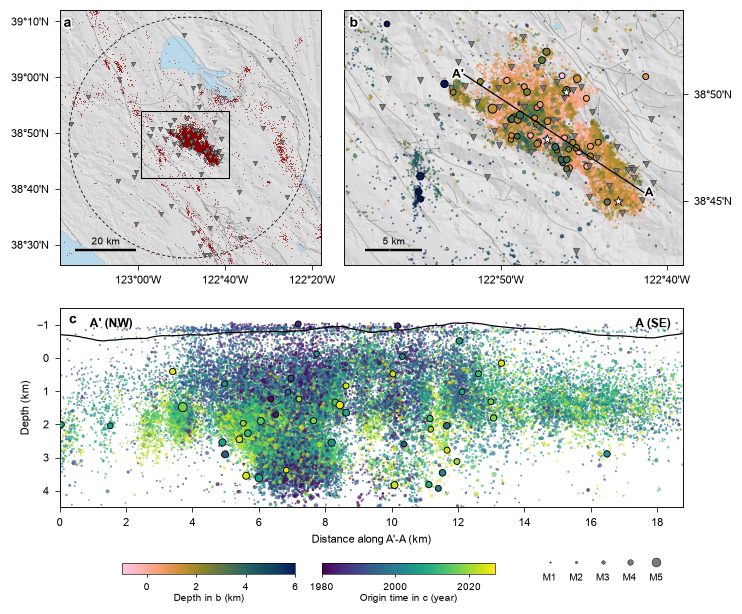

In [24]:
cat, L, site = catalog(), layers(), sites()

MA, MB = 2.0, 1.5                          # magnitude floors for the regional and field panels
Z0, Z1 = -1.5, 4.5                         # depth range of the section, km relative to sea level

eqs = cat.sort_values("mag")               # small events drawn first, so large ones are not buried
in_field = eqs.latitude.between(*FIELD[2:]) & eqs.longitude.between(*FIELD[:2])
A, A2, evec, LEN = section_line(eqs[in_field], MB)
prof = along_section(eqs[in_field & (eqs.mag >= MB)], A, evec, LEN).sort_values("mag")
prof = prof.assign(year=prof.time.dt.year + prof.time.dt.dayofyear / 365.25)

TOT, GAPX, LFT, RGT = 17.0, .55, 1.15, 1.45
WIN = TOT - LFT - RGT
WA, WB, HA = two_panels(WIN, GAPX, REGION, FIELD)
HC = WIN * (Z1 - Z0) / LEN                 # true scale, by construction
HT = .3 + HA + 1.0 + HC + 2.5
fig = plt.figure(figsize=(TOT * CM, HT * CM))
def panel(x, y, w, h):
    """An axes placed in centimetres from the lower-left corner of the figure."""
    return fig.add_axes([x / TOT, y / HT, w / TOT, h / HT])
axa = panel(LFT, HT - HA - .3, WA, HA)
axb = panel(LFT + WA + GAPX, HT - HA - .3, WB, HA)
axc = panel(LFT, 2.5, WIN, HC)

# (a) the study region: every event above M 2, the 40 km circle, the outline of panel (b)
basemap(axa, L, REGION, fault_lw=.25)
theta = np.linspace(0, 2 * np.pi, 361)
axa.plot(CENTER[1] + RADIUS_KM / KM_LON * np.cos(theta),
         CENTER[0] + RADIUS_KM / KM_LAT * np.sin(theta),
         color="black", lw=.5, ls=(0, (4, 3)), zorder=4)
da = eqs[eqs.mag >= MA]
axa.scatter(da.longitude, da.latitude, s=.35, c="#8b0000", lw=0, alpha=.55, zorder=3, rasterized=True)
axa.scatter(site.lon, site.lat, s=9, marker="v", c="#7a7a7a", ec="black", lw=.2, zorder=5)
axa.plot([FIELD[0], FIELD[1], FIELD[1], FIELD[0], FIELD[0]],
         [FIELD[2], FIELD[2], FIELD[3], FIELD[3], FIELD[2]], color="black", lw=.7, zorder=5)
degree_minute_ticks(axa, .3333333, .1666667); scale_bar(axa, 20)

# (b) the field: depth as colour, magnitude as symbol area, the M >= 4 events rimmed in black
basemap(axb, L, FIELD, fault_lw=.35)
db = eqs[in_field & (eqs.mag >= MB)]
sc_depth = axb.scatter(db.longitude, db.latitude, s=mag_size(db.mag), c=db.depth,
                       cmap=DEPTH_CMAP, vmin=-1, vmax=6, lw=0, alpha=.7, zorder=3, rasterized=True)
big = eqs[in_field & (eqs.mag >= 4)]
axb.scatter(big.longitude, big.latitude, s=mag_size(big.mag), c=big.depth, cmap=DEPTH_CMAP,
            vmin=-1, vmax=6, ec="black", lw=.6, zorder=4)
axb.scatter(site.lon, site.lat, s=16, marker="v", c="#7a7a7a", ec="black", lw=.25, zorder=5)
for plant_lon, plant_lat in L["plants"]:
    axb.scatter(plant_lon, plant_lat, s=42, marker="*", c="white", ec="black", lw=.5, zorder=6)
axb.plot([A[0], A2[0]], [A[1], A2[1]], color="black", lw=.8, zorder=6)
for (px, py), lab, ha in (((A[0], A[1]), "A", "left"), ((A2[0], A2[1]), "A'", "right")):
    axb.text(px, py, lab, fontsize=8, fontweight="bold", ha=ha, va="center", zorder=7,
             path_effects=[pe.withStroke(linewidth=2, foreground="white")])
degree_minute_ticks(axb, .1666667, .0833333, right=True); scale_bar(axb, 5)

# (c) the section along A'-A, coloured by origin time, with the ground surface from the elevation model
sc_time = axc.scatter(prof.along, prof.depth, s=mag_size(prof.mag), c=prof.year, cmap="viridis",
                      vmin=1980, vmax=2027, lw=0, alpha=.7, rasterized=True)
pb = prof[prof.mag >= 4]
axc.scatter(pb.along, pb.depth, s=mag_size(pb.mag), c=pb.year, cmap="viridis", vmin=1980,
            vmax=2027, ec="black", lw=.6, zorder=4)
tt, zs = ground_profile(L, A2[0], A2[1], -evec[0], -evec[1], LEN)
axc.plot(tt, -zs, color="black", lw=.8)
axc.set(xlim=(0, LEN), ylim=(Z1, Z0), xlabel="Distance along A'-A (km)", ylabel="Depth (km)",
        xticks=np.arange(0, LEN + .1, 2), yticks=np.arange(-1, 4.6, 1))
axc.text(.048, .95, "A' (NW)", transform=axc.transAxes, fontsize=8, fontweight="bold", va="top")
axc.text(.98, .95, "A (SE)", transform=axc.transAxes, fontsize=8, fontweight="bold",
         ha="right", va="top")

for k, ax in enumerate((axa, axb, axc)):
    ax.text(.015, .975, "abc"[k], transform=ax.transAxes, fontsize=9, fontweight="bold", va="top",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

# two colour bars and a magnitude key, in the space beneath the section
for cx, sc, lab, ticks in (((LFT + WIN * .10), sc_depth, "Depth in b (km)", None),
                           ((LFT + WIN * .42), sc_time, "Origin time in c (year)", [1980, 2000, 2020])):
    cax = fig.add_axes([cx / TOT, .95 / HT, 4.0 / TOT, .26 / HT])
    cb = fig.colorbar(sc, cax=cax, orientation="horizontal", ticks=ticks)
    cb.set_label(lab, fontsize=6.5, labelpad=1); cb.ax.tick_params(labelsize=6.5, length=2)
    cb.outline.set_linewidth(.4); cb.solids.set_alpha(1)
axk = fig.add_axes([(LFT + WIN * .76) / TOT, .78 / HT, 3.2 / TOT, .75 / HT]); axk.axis("off")
for k, m in enumerate((1, 2, 3, 4, 5)):
    axk.scatter(k, .62, s=mag_size(m), c="#7a7a7a", ec="black", lw=.3, clip_on=False)
    axk.text(k, .04, f"M{m}", fontsize=6.5, ha="center")
axk.set(xlim=(-.6, 4.6), ylim=(0, 1))

azimuth = np.degrees(np.arctan2(evec[0], evec[1])) % 360
print(f"profile A-A': azimuth N{360 - azimuth:.0f}W, {LEN:.1f} km; {len(prof):,} events on the section")
plt.show()


**Figure 5. Seismicity of the study region, 1969–2025.** (a) Earthquakes of M ≥ 2 within the 40 km
study region (dashed circle) on shaded relief, with Quaternary faults in grey and stations as grey
triangles; the rectangle is the field window shown in (b). (b) The field: earthquakes of M ≥ 1.5
coloured by depth and sized by magnitude, events of M ≥ 4 rimmed in black, stars the power plants,
and the section line A–A′. (c) The section along A′–A, northwest at the left as on the map, at
true scale between −1.5 and 4.5 km depth, coloured by origin time, showing events within 6 km of
the line; the black curve is the ground surface from the elevation model. Depths are relative to
sea level, and the ground here stands 0.5 to 1.4 km above it.

Three properties are apparent, and each is used later.

The seismicity is **strongly localised**. It forms a single cloud approximately 19 km long, and
almost all of it lies within the field window rather than being distributed across the study
region. Section 4.8 quantifies how little the geographic criterion actually removes.

It is **elongated northwest–southeast**, at N57°W. Section 1.5 compared this with the mean strike
of the mapped Quaternary faults, N44°W within the field window, and found the two to differ by
some 13 degrees: the seismicity follows the regional structural grain approximately but is not
parallel to any mapped structure. The comparison is taken up properly in the clustering session.

It is **thin**. Panel (c) shows the events confined to a layer a few kilometres thick beneath the
surface, which is the depth interval of the producing reservoir rather than the depth extent of a
crustal fault zone. This is a reservoir process observed seismically, and § 1.1 gives the depth
statistics that make the point quantitatively.


### 4.7 · When the earthquakes are

The second figure shows the same catalogue against time: monthly counts at three magnitude
thresholds on a logarithmic axis, and every individual magnitude plotted against its origin time.


419,248 earthquakes over 683 months; 76 of M >= 4


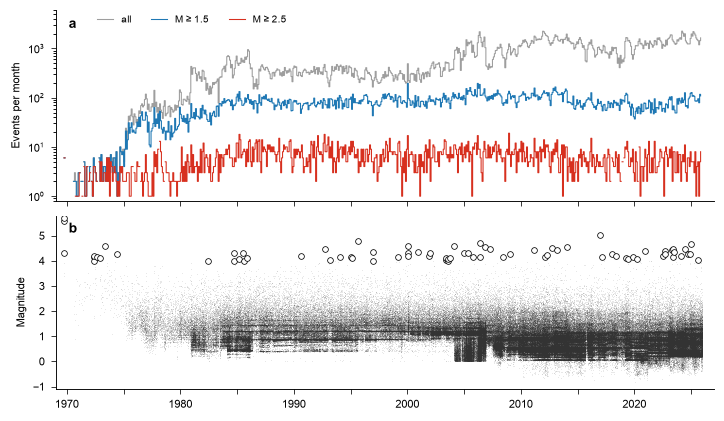

In [25]:
t0, t1 = pd.Timestamp("1969-01-01", tz="UTC"), pd.Timestamp("2027-01-01", tz="UTC")
last = cat.time.max().tz_convert(None).to_period("M").to_timestamp().tz_localize("UTC")
months = pd.date_range(t0, last, freq="MS")            # up to the last complete month

fig, axes = plt.subplots(2, 1, figsize=(17 * CM, 10 * CM), sharex=True,
                         gridspec_kw=dict(height_ratios=[1.1, 1], hspace=.08))

# (a) counts per month at three thresholds. A logarithmic axis is essential: the three curves span
#     three orders of magnitude, and months with no events are left blank rather than plotted at zero.
for m, colour, lab in ((0, "#9e9e9e", "all"), (1.5, "#1f78b4", "M ≥ 1.5"), (2.5, "#d7301f", "M ≥ 2.5")):
    counts = np.histogram(cat[cat.mag >= m].time, bins=months)[0]
    axes[0].step(months[:-1], np.where(counts > 0, counts, np.nan), where="post",
                 color=colour, lw=.7, label=lab)
axes[0].set(yscale="log", ylim=(.8, 6000), ylabel="Events per month")
axes[0].legend(loc="upper left", bbox_to_anchor=(.05, 1.02), frameon=False, fontsize=6.5,
               ncol=3, handlelength=1.6)

# (b) every magnitude against time. The points are heavily transparent because there are 419,248 of
#     them; the M >= 4 events are drawn separately so that they are not lost in the cloud.
axes[1].scatter(cat.time, cat.mag, s=.25, c="#333333", lw=0, alpha=.12, rasterized=True)
big = cat[cat.mag >= 4]
axes[1].scatter(big.time, big.mag, s=14, facecolors="white", edgecolors="black", lw=.5, zorder=3)
axes[1].set(ylim=(-1.1, 5.8), ylabel="Magnitude", yticks=[-1, 0, 1, 2, 3, 4, 5], xlim=(t0, t1))
axes[1].set_xticks(pd.to_datetime([f"{y}-01-01" for y in range(1970, 2030, 5)], utc=True))
axes[1].set_xticklabels([str(y) if y % 10 == 0 else "" for y in range(1970, 2030, 5)])

for k, ax in enumerate(axes):
    ax.text(.02, .96, "ab"[k], transform=ax.transAxes, fontsize=9, fontweight="bold", va="top",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.subplots_adjust(left=1.5 / 17, right=1 - .3 / 17, top=1 - .35 / 10, bottom=.9 / 10)

print(f"{len(cat):,} earthquakes over {len(months) - 1} months; {len(big)} of M >= 4")
plt.show()


**Figure 6. Seismicity through time.** (a) Events per month at three magnitude thresholds,
logarithmic vertical axis; months with no events are left blank. (b) Every magnitude in the
catalogue against its origin time, with the events of M ≥ 4 drawn as open circles.

Panel (a) should be read together with § 3.4. The rate of *all* events steps upward around 2012,
and § 3.4 has already identified what happened in that year: the borehole network appears in the
archive as a block. The M ≥ 2.5 curve does not step in the same way, because events of that size
were already being detected by the regional network. The principle is general and it is the single
most important safeguard when a catalogue is used to measure a rate: **a change in catalogue rate
at small magnitudes is a change in the catalogue; only a change at magnitudes the earlier network
could already detect is evidence about the Earth.**

Panel (b) shows the same effect more directly. The lower edge of the magnitude cloud — the smallest
events being reported at any given time — descends over the record, and it descends in steps, with
horizontal banding where the reporting threshold was in practice fixed. That edge is the
**magnitude of completeness**, the magnitude above which the catalogue may be taken to contain
every event that occurred. Section 9 estimates it properly. Any statistic computed across an
interval over which the edge moves is comparing catalogues of different sensitivity.


### 4.8 · Defining a working subset

Sections 9 and 10 compute on a subset of this catalogue rather than on all of it. There is no
uniquely correct subset. There are defensible choices and indefensible ones, and the difference
lies in whether the effect of each criterion can be stated. Criteria are therefore applied one at a
time, and the cost of each is recorded.


In [26]:
steps = [
    ("start: earthquakes with a measured magnitude", pd.Series(True, index=cat.index)),
    ("inside the producing field", cat.longitude.between(*FIELD[:2])
     & cat.latitude.between(*FIELD[2:])),
    ("depth 0–10 km", cat.depth.between(0, 10)),
    ("at least 8 phases in the solution", cat.nst >= 8),
]

mask, report = pd.Series(True, index=cat.index), []
for label, cond in steps:
    before = mask.sum()
    mask &= cond
    report.append({"criterion": label, "remaining": int(mask.sum()),
                   "removed": int(before - mask.sum())})
print(pd.DataFrame(report).to_string(index=False))

mine = cat[mask].copy()
mine.to_csv("my_catalog.csv", index=False)
print(f"\nkept {len(mine):,} of {len(cat):,}  ({100 * len(mine) / len(cat):.1f} %), "
      f"{mine.time.min():%Y-%m-%d} to {mine.time.max():%Y-%m-%d}, "
      f"M {mine.mag.min():.2f} to {mine.mag.max():.2f}")

kept = (mine.groupby("year").size() / cat.groupby("year").size()).dropna()
print("\nfraction of each year's earthquakes surviving the cut:")
print(kept.reindex([1975, 1985, 1995, 2005, 2015, 2024]).round(2).to_string())


                                   criterion  remaining  removed
start: earthquakes with a measured magnitude     419248        0
                  inside the producing field     403475    15773
                               depth 0–10 km     374858    28617
           at least 8 phases in the solution     259267   115591



kept 259,267 of 419,248  (61.8 %), 1972-04-28 to 2025-12-31, M -0.81 to 5.01

fraction of each year's earthquakes surviving the cut:
year
1975    0.60
1985    0.40
1995    0.34
2005    0.74
2015    0.68
2024    0.68


Two results follow, and neither is the one the criteria appear to promise.

The **geographic window removes very little**, although the field occupies a small part of the
download box by area. This is a useful independent calibration of how localised the activity is,
and it confirms quantitatively what Figure 5 shows.

The **phase-count criterion does most of the work**, and it is the one requiring the most thought,
because `nst` is a property of the recording network rather than of the earthquake. Requiring eight
phases preferentially removes small events, and preferentially removes events from years in which
few stations were operating. It is a quality criterion which is unavoidably also a magnitude
criterion and a date criterion. The final table makes this concrete: the surviving fraction varies
by a factor of two across the record, and it does not vary monotonically.

The general statement is that **a criterion applied uniformly does not produce a uniform subset**.
Any trend measured on this subset is in part a trend in the subset itself, and § 10 must therefore
treat the selection as part of the analysis rather than as a preliminary to it.

The criteria above are a starting point rather than a recommendation. They should be replaced by a
set that can be defended, the cell re-run, and the resulting `my_catalog.csv` retained; §§ 9 and 10
compute on that file.


#### Sources

* Northern California Earthquake Data Center (2014). *Northern California Earthquake Data Center*.
  UC Berkeley Seismological Laboratory. Dataset. `10.7932/NCEDC` — the routine catalogue of the
  Northern California Seismic Network, obtained here by all three routes of § 4.2 and distributed
  with this course as `geysers_catalog_1969-2026.csv.gz`.


## § 5 · Waveform data: access routes and a reference event

*This section establishes the recordings themselves: what a digital seismogram physically is, four
independent routes by which one may be retrieved and the cost of each, and the ground motion of a
single earthquake as recorded across the whole network.*

### 5.1 · What a seismogram is

Everything used so far — the catalogue, and the arrival times and mechanisms still to come — is a
summary computed by somebody else from waveforms. From this point the course works on the
waveforms themselves, and five of the remaining weeks do nothing else.

A digital **seismogram** is a sequence of integers. The sensor converts ground motion into a
voltage; a digitiser samples that voltage at a fixed rate and records each sample as an integer
number of **counts**, the smallest voltage step the digitiser can distinguish. A count is therefore
not a physical unit. Converting counts to ground velocity or displacement requires the
**instrument response**, which is the subject of § 7, and until that conversion is made an
amplitude read from a trace is a statement about the recording system as much as about the Earth.

Three properties of the recording follow from this description and matter immediately.

The **sampling rate** sets the highest frequency that can be represented. A signal sampled at
100 samples per second cannot carry information above 50 Hz, the Nyquist frequency, and energy
above that limit is not lost but folded back into the recorded band as a spurious lower frequency.
The borehole stations here sample at 500 Hz, the broadband stations at 100 Hz, and some older
channels far more slowly.

The **dynamic range** sets the largest motion that can be represented. A digitiser using *n* bits
can express 2ⁿ distinct levels; once the ground moves further than the largest of them, the
recorded trace stops following the ground and holds at that value. This is **saturation**, or
clipping, and § 5.5 finds it in the figure below.

The **format** is almost always miniSEED, a compact binary format in which the samples are stored
in fixed-length records, conventionally 4,096 bytes, each carrying a short header giving the
channel and the time of its first sample. The fixed record length is what makes the byte-range
route of § 5.3 possible, because a reader can seek directly to the region of a file it needs
instead of transferring the whole of it.


### 5.2 · The reference event

Sections 5 to 8 work throughout on one earthquake: the **M 2.91 of 31 March 2016 at 23:49:02 UTC**,
at 2.1 km depth within the producing field.

It is deliberately not the largest event available. The M 5.01 of 14 December 2016 saturates the
short-period stations outright and, as § 6 shows, carries no S-wave arrivals at all in the phase
archive, which makes it the least suitable event in the catalogue for anything computed from a
waveform. A moderate, well recorded event that has been picked for both phases allows §§ 5, 6, 7
and 8 to work on the same recordings, so that the waveform, the arrival time, the amplitude and
the first motion all refer to the same measurement.

The station list is built by `event_stations()`, defined in § 0.8, which returns every station that
recorded the event within 40 km, ordered by epicentral distance. Sections 6 and 7 build their lists
by the same call.


In [27]:
import io
import time

import obspy
from obspy.clients.fdsn import Client
from obspy.io.mseed.util import get_record_information   # reads a record header only

SEC, SPAN = 45, 30                    # seconds fetched, seconds drawn
HIGHPASS = 1.0                        # Hz; see § 5.5 — this is also the sensor corner frequency
CLIP_COUNTS = 2048                    # 2^11, full scale of the old NCSN 12-bit short-period telemetry
CLASS_COLOUR = {"BG": "#e41a1c", "broadband": "#377eb8",
                "short-period": "#4daf4a", "strong-motion": "#984ea3"}
CLASS_LABEL = {"BG": "BG borehole (500 sps)", "broadband": "Broadband (HH/BH)",
               "short-period": "Short-period (EH/SH)", "strong-motion": "Strong-motion (HN)"}

t0 = obspy.UTCDateTime(REFERENCE_EVENT["time"]) - 2      # start two seconds before the origin time
nc = Client("NCEDC", timeout=300)

ch = event_stations()
print(f"{len(ch)} stations, {ch.d.min():.1f}-{ch.d.max():.1f} km: "
      f"{ch.klass.value_counts().to_dict()}")


53 stations, 1.0-39.4 km: {'BG': 33, 'short-period': 15, 'broadband': 3, 'strong-motion': 2}


### 5.3 · Four routes to the same samples

The NCEDC publishes the same waveforms in several ways. Choosing between them is a decision about
cost rather than about content, and the routes below are timed on the same thirty seconds of one
borehole channel, `BG.AL1..DPZ`.

There are **three strategies**: let the server cut the window, read only the records that overlap
it, or transfer the whole day and cut locally. The middle one is shown twice, over HTTP and over
`s3://`, because the algorithm is the same and only the two lines that fetch bytes change.

**A — the FDSN `dataselect` service.** The standard web service, the counterpart of the `station`
and `event` services of §§ 3 and 4. The server performs the cut and returns only the requested
window.

**B and C — only the records that overlap the window.** The archive holds one miniSEED file per
channel per day. Because records are of fixed length and each header carries its own start time, a
handful of header reads bisect the file to locate the window. B does the byte reads over HTTP, C
over `s3://`.

**D — the whole channel-day file.** Transfer everything and cut locally.

The routes differ in **what you have to know before you can ask**, and that matters more in
practice than the timings do:

| route | what you must supply |
|---|---|
| A | network, station, location and channel codes, and the two times |
| B, C | the **path of the day file**, which encodes all of those plus the year and day of year — and the record length, to treat the file as an array |
| D | the same path |

The web service resolves the archive's layout on your behalf; the byte-range routes require you to
know it. That is the real cost of B and C, and it is why the key is built explicitly below rather
than being fetched from anywhere: there is no service to ask for it.


In [28]:
# The channel and window every route below retrieves, and the archive key three of them need.
STATION, SECONDS = "AL1", 30
KEY = (f"continuous_waveforms/BG/{t0.year}/{t0.year}.{t0.julday:03d}/"
       f"{STATION}.BG.DPZ..D.{t0.year}.{t0.julday:03d}")
cost = {}
print(KEY)


continuous_waveforms/BG/2016/2016.091/AL1.BG.DPZ..D.2016.091


**Route A — the FDSN `dataselect` service.** One request; the server does the cutting.


In [29]:
tic = time.time()
st_a = nc.get_waveforms("BG", STATION, "", "DPZ", t0, t0 + SECONDS)
cost["A obspy FDSN"] = dict(sec=time.time() - tic, mb=st_a[0].data.nbytes / 1e6, req=1,
                            tr=st_a[0])
print(st_a[0])


BG.AL1..DPZ | 2016-03-31T23:49:00.880000Z - 2016-03-31T23:49:30.878000Z | 500.0 Hz, 15000 samples


**Route B — read only the records that overlap the window.** The continuous archive holds one
miniSEED file per channel per day, and this is the route worth understanding, because it is the
one that generalises: it works on any archive that will serve a byte range, which is most of them.

It rests on two properties of the format. Records are a **fixed 4,096 bytes** in this archive, so
record *k* begins at byte `4096*k` and the file can be treated as an array. And every record
header carries the **start time of its first sample**, which can be read from the first 512 bytes
without decoding the record. Together those make the file sorted and randomly addressable, which
is what bisection needs. Nothing below is hidden in a helper.


In [30]:
url = f"{BUCKET}/{KEY}"
n_req = 0                                          # count every HTTP request this route makes


def read_bytes(first, last):
    """Bytes `first` to `last` of the remote file, inclusive, by HTTP Range request."""
    global n_req
    n_req += 1
    return fetch(url, headers={"Range": f"bytes={first}-{last}"}).content


# How many records are there? The Content-Range header of a one-byte request gives the file size.
tic = time.time()
size = int(fetch(url, headers={"Range": "bytes=0-0"}).headers["Content-Range"].split("/")[-1])
n_req += 1
n_records = size // RECORD
print(f"{size / 1e6:.1f} MB, {n_records:,} records of {RECORD} bytes")


47.6 MB, 11,612 records of 4096 bytes


In [31]:
# Bisect on the record index for the last record starting at or before t0. Each step reads one
# 512-byte header, so the search costs about log2(n_records) requests rather than the whole file.
lo, hi = 0, n_records - 1
while hi - lo > 1:
    mid = (lo + hi) // 2
    header = read_bytes(mid * RECORD, mid * RECORD + 511)
    t_mid = get_record_information(io.BytesIO(header))["starttime"]
    if t_mid <= t0:
        lo = mid
    else:
        hi = mid
print(f"the window starts inside record {lo:,} of {n_records:,}, found in {n_req - 1} header reads")


the window starts inside record 11,522 of 11,612, found in 13 header reads


In [32]:
# Read forward from there until the records cover the window, doubling if the first block is short.
n = 8
while True:
    raw = read_bytes(lo * RECORD, (lo + n) * RECORD - 1)
    st_b = obspy.read(io.BytesIO(raw))
    if st_b[-1].stats.endtime >= t0 + SECONDS or n > 128:
        break
    n *= 2
st_b.merge()
st_b.trim(t0, t0 + SECONDS)

cost["B https Range"] = dict(sec=time.time() - tic, mb=len(raw) / 1e6, req=n_req, tr=st_b[0])
print(f"{len(raw) / 1e6:.3f} MB in {n_req} requests, {st_b[0].stats.npts} samples")


0.033 MB in 15 requests, 15001 samples


**Route C — the same algorithm over `s3://`.** Route B is not tied to HTTP. Given anything that
will return a byte interval, the bisection is unchanged, and `fsspec` presents the S3 object as a
file so the byte interval becomes a `seek` and a `read`. Only the two lines that fetch bytes
differ; the search is identical, and so is the number of requests.


In [33]:
import fsspec

tic = time.time()
fh = fsspec.open(f"s3://ncedc-pds/{KEY}", "rb", anon=True, default_block_size=8192).open()
n_req_c = 0


def read_bytes_s3(first, last):
    """The same interval, through the S3 object rather than an HTTP header."""
    global n_req_c
    n_req_c += 1
    fh.seek(first)
    return fh.read(last - first + 1)


lo_c, hi_c = 0, n_records - 1
while hi_c - lo_c > 1:
    mid = (lo_c + hi_c) // 2
    t_mid = get_record_information(io.BytesIO(read_bytes_s3(mid * RECORD, mid * RECORD + 511)))["starttime"]
    lo_c, hi_c = (mid, hi_c) if t_mid <= t0 else (lo_c, mid)

raw_c = read_bytes_s3(lo_c * RECORD, (lo_c + n) * RECORD - 1)
st_c = obspy.read(io.BytesIO(raw_c))
st_c.merge()
st_c.trim(t0, t0 + SECONDS)

cost["C fsspec s3://"] = dict(sec=time.time() - tic, mb=len(raw_c) / 1e6, req=n_req_c, tr=st_c[0])
print(f"same record {lo_c:,}, {len(raw_c) / 1e6:.3f} MB in {n_req_c} requests")


same record 11,522, 0.033 MB in 14 requests


**Route D — the whole channel-day file.** Transfer all of it and cut locally.


In [34]:
tic = time.time()
r = fetch(f"{BUCKET}/{KEY}", timeout=600)
whole = obspy.read(io.BytesIO(r.content))
whole.trim(t0, t0 + SECONDS)
cost["D whole day file"] = dict(sec=time.time() - tic, mb=len(r.content) / 1e6, req=1,
                                tr=whole[0])
print(f"{len(r.content) / 1e6:.3f} MB for the whole day, trimmed to {whole[0].stats.npts} samples")


47.563 MB for the whole day, trimmed to 15001 samples


Four routes, one comparison. The windows may begin a sample or two apart, so they are aligned
before the samples are checked against each other.


In [35]:
ref = cost["A obspy FDSN"]["tr"]
for name, v in cost.items():
    tr = v["tr"]
    off = round((tr.stats.starttime - ref.stats.starttime) * tr.stats.sampling_rate)
    m = min(tr.stats.npts, ref.stats.npts) - abs(off)
    x, y = ((tr.data[:m], ref.data[off:off + m]) if off >= 0
            else (tr.data[-off:-off + m], ref.data[:m]))
    print(f"  {name:18s} {v['sec']:6.2f} s {v['mb']:8.3f} MB {v['req']:3d} req  "
          f"identical: {np.array_equal(x, y)}")


  A obspy FDSN         0.32 s    0.060 MB   1 req  identical: True
  B https Range        4.66 s    0.033 MB  15 req  identical: True
  C fsspec s3://       1.99 s    0.033 MB  14 req  identical: True
  D whole day file     2.27 s   47.563 MB   1 req  identical: True


The samples are identical, and the transferred volumes differ by three orders of magnitude. The
elapsed times, however, do not follow the volumes, and the discrepancy is the practical lesson:
**the cheapest transfer is not the fastest operation**. A byte-range route issues many small
requests and is dominated by round-trip latency rather than by bandwidth, whereas transferring
whole day files in parallel is faster for any task that scans a long interval — which is what a
detector does in the phase-picking session and a template-matching search in the similarity-search session. The correct
route depends on the shape of the access pattern, not on the size of the data.

A fifth route exists. The directory `event_waveforms/<year>/<year>.<doy>/` holds one miniSEED file
per catalogued event, containing every station together, and extends back to 1984; it is the
natural route for the event-based weeks of the course. Its files are markedly non-uniform in size,
which is worth measuring rather than assuming, and a single listing of the bucket settles it.


In [36]:
# One day of the event-waveform archive: 14 December 2016, the day of the field's largest earthquake.
day = f"event_waveforms/{2016}/{2016}.{obspy.UTCDateTime('2016-12-14').julday:03d}/"
files = pd.DataFrame(s3_list(day), columns=["key", "bytes"])
files["mb"] = files.bytes / 1e6

print(f"{len(files)} event files on {day}")
print(f"  median {files.mb.median():.2f} MB, largest {files.mb.max():.0f} MB, "
      f"total {files.mb.sum():.0f} MB")
print(f"  the largest is {files.loc[files.mb.idxmax(), 'key'].split('/')[-1]}")


350 event files on event_waveforms/2016/2016.349/
  median 1.56 MB, largest 179 MB, total 1615 MB
  the largest is NC.72737985.NCSS.ms


The largest file is the M 5.01 of that day, and it is two orders of magnitude larger than the
median, because a larger earthquake is recorded on more stations and for longer. **Sampling events
uniformly from a catalogue does not sample bytes uniformly**, which becomes apparent when a
training set is assembled and most of the available disk has been consumed by a handful of events.


### 5.4 · The event recorded across the network

The figure below is a **record section**: one trace per station, arranged vertically in order of
epicentral distance, with time running left to right. It is the standard way of displaying one
event on many stations, because the systematic increase of arrival time with distance — the
**moveout** — then appears as a coherent curve across the traces rather than as an unrelated delay
on each.

Two reference curves are drawn. The **P wave** is the compressional wave, which travels fastest and
therefore arrives first; the **S wave** is the shear wave, which travels at roughly 0.6 of the P
speed and arrives later, with the gap between them widening with distance. The curves are computed
for constant speeds of 5.5 and 3.2 km s⁻¹, which is a straight-ray approximation adequate for
display but not for location; the location session replaces it.

Each trace is normalised to its own peak, so the figure carries relative timing and waveform shape
but no amplitude information at all. Colour gives the instrument class of § 3, and any trace drawn
faded is saturated in the sense defined in § 5.5.


48 traces drawn; 1 held at 2048 counts (12-bit short-period telemetry): ['NC.GAC']
  2 reach the rail exactly: ['NC.GBG', 'NC.GAC']
  10 peak within 10% of it: ['NC.GAC', 'NC.GBG', 'NC.GCR', 'NC.GHL', 'NC.GPM', 'NC.GRT', 'NC.GSG', 'NC.GSN', 'NC.GSS', 'NC.NMT']


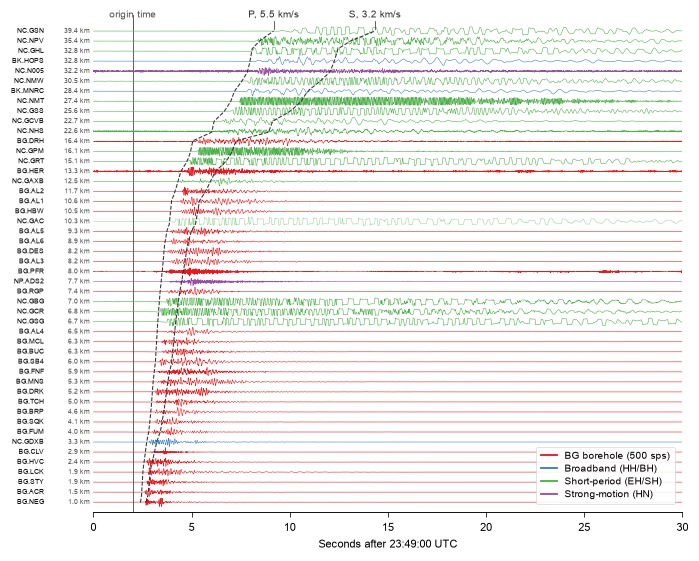

In [37]:
st = nc.get_waveforms_bulk([(r.net, r.sta, r.loc or "*", r.cha, t0, t0 + SEC)
                            for r in ch.itertuples()])
got = {tr.stats.station: tr for tr in st}


def is_saturated(tr):
    """True if the trace's own ceiling IS the 12-bit rail and it returns there repeatedly.

    Both halves are needed. `peak >= 2047` alone flags nothing on a 24-bit station, which reaches
    millions of counts legitimately; a flat top alone is met by any quiet trace. Saturation is a
    trace whose maximum coincides with the rail AND which sits at that maximum for many samples.
    """
    a = np.abs(tr.data.astype(float))
    if not a.size:
        return False
    peak = a.max()
    return peak <= CLIP_COUNTS * 1.03 and float(np.mean(a >= peak * .999)) > 5e-4


# Prepare every trace before drawing any, so that a station with a gap is dropped rather than
# occupying a row with nothing in it.
ready = []
for r in ch[ch.sta.isin(got)].itertuples():
    w = got[r.sta].copy().trim(t0, t0 + SPAN)
    if w.stats.npts < 10 * w.stats.sampling_rate:
        continue
    w.detrend("demean")
    w.filter("highpass", freq=HIGHPASS, corners=2, zerophase=True)
    y = w.data.astype(float)
    if not np.abs(y).max():
        continue
    ready.append((r, w, .45 * y / np.abs(y).max(), is_saturated(got[r.sta])))

W = 17.0
H = 1.75 + 0.235 * len(ready)
fig = plt.figure(figsize=(W * CM, H * CM))
ax = fig.add_axes([3.0 / W, 1.05 / H, (W - 3.4) / W, (H - 1.55) / H])
HEAD = 1.6                                        # rows of headroom for the phase labels

for i, (r, w, y, sat) in enumerate(ready):
    ax.plot(w.times(), y + i, lw=.35, color=CLASS_COLOUR[r.klass], alpha=.55 if sat else 1.0)

# The P and S moveout curves, drawn in the row coordinate by interpolating distance onto row index.
rr = np.linspace(0, max(r.d for r, *_ in ready), 60)
idx = np.interp(rr, [r.d for r, *_ in ready], np.arange(len(ready)))
top = len(ready) - 1
for v, lab in ((5.5, "P, 5.5 km/s"), (3.2, "S, 3.2 km/s")):
    t = 2 + np.hypot(rr, REFERENCE_EVENT["depth"]) / v
    ax.plot(t, idx, color="#333333", lw=.7, ls="--", zorder=5)
    # the label sits in the headroom above the top trace, joined to its curve by a short stem,
    # rather than on the waveforms where no halo would save it
    ax.plot([t[-1], t[-1]], [top + .25, top + HEAD - .55], color="#333333", lw=.5, zorder=6)
    ax.text(t[-1], top + HEAD - .45, lab, fontsize=6.5, color="#333333", ha="center",
            va="bottom", zorder=6)

ax.axvline(2, color="#555555", lw=.6, zorder=0)
ax.plot([2, 2], [top + .25, top + HEAD - .55], color="#555555", lw=.5, zorder=6)
ax.text(2, top + HEAD - .45, "origin time", fontsize=6.5, color="#555555",
        ha="center", va="bottom", zorder=6)

# Station name and distance are drawn as two explicit right-aligned columns. Using tick labels for
# one of them would place the two in the same position, which is where matplotlib parks a tick label.
ax.set_yticks([])
for i, (r, *_) in enumerate(ready):
    ax.text(-0.084, i, f"{r.net}.{r.sta}", transform=ax.get_yaxis_transform(), fontsize=4.6,
            ha="right", va="center", color="#111111")
    ax.text(-0.006, i, f"{r.d:.1f} km", transform=ax.get_yaxis_transform(), fontsize=4.6,
            ha="right", va="center", color="#555555")
ax.set(xlim=(0, SPAN), ylim=(-1.0, len(ready) - 1 + HEAD),
       xlabel=f"Seconds after {t0.datetime:%H:%M:%S} UTC")
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)

# The near stations' energy is all early, so the lower right of the section is empty and the legend
# costs nothing there. The box is slightly transparent so that traces do not run through the text.
leg = ax.legend(handles=[Line2D([], [], color=c, lw=1.2, label=CLASS_LABEL[k])
                         for k, c in CLASS_COLOUR.items()],
                loc="lower right", fontsize=6.5, handlelength=1.6, labelspacing=.35,
                borderaxespad=.8, frameon=True, framealpha=.88, facecolor="white",
                edgecolor="#cccccc", borderpad=.5)
leg.get_frame().set_linewidth(.4)
leg.set_zorder(20)

clipped = [f"{r.net}.{r.sta}" for r, _, _, sat in ready if sat]
# Saturation is not a threshold but a continuum, and a count of the traces that clear the test
# invites the reading that every other trace has headroom. Report how many are near the rail too.
peaks = {f"{r.net}.{r.sta}": float(np.abs(got[r.sta].data.astype(float)).max()) for r, _, _, _ in ready}
at_rail = [k for k, p in peaks.items() if abs(p - CLIP_COUNTS) < 1]
near_rail = [k for k, p in peaks.items() if 0.90 * CLIP_COUNTS <= p <= 1.03 * CLIP_COUNTS]
print(f"{len(ready)} traces drawn; {len(clipped)} held at {CLIP_COUNTS} counts "
      f"(12-bit short-period telemetry): {clipped}")
print(f"  {len(at_rail)} reach the rail exactly: {at_rail}")
print(f"  {len(near_rail)} peak within 10% of it: {sorted(near_rail)}")
plt.show()


**Figure 7. The reference earthquake recorded across the network.** Vertical-component records of
the M 2.91 of 31 March 2016, one trace per station, ordered by epicentral distance, each normalised
to its own peak and high-pass filtered above 1 Hz. Colour gives the instrument class; a faded trace
is saturated. Dashed curves are constant-velocity P and S moveout at 5.5 and 3.2 km s⁻¹ from the
hypocentre; the vertical line is the catalogue origin time. Amplitudes are not comparable between
traces.


### 5.5 · Two properties of the figure that are properties of the instruments

**Saturation is a property of the digitiser, not of the distance.** The faded trace is held at
2,048 counts, which is full scale for the 12-bit telemetry used by the older short-period stations
of the regional network, while a 24-bit instrument at a comparable distance records the same
ground motion in millions of counts without difficulty.

One trace is *held* there, but it is not the only one affected, and the counts printed above make
that point better than the figure does. A second reaches the rail for a single sample, and several
more peak within a few per cent of it. Because every trace in the figure is normalised to its own
maximum, a station at 95 per cent of full scale is drawn exactly like one with headroom to spare.
Saturation is the end of a continuum rather than a category, and a trace approaching the rail has
already begun to under-report its largest excursions. Testing for saturation by asking whether the peak
exceeds 2,047 counts is wrong in both directions: it flags nothing at all on the modern stations,
and it misidentifies the diagnostic, which is a **flat top** rather than a large number. The test
used above asks instead whether a trace's own maximum coincides with the rail and whether the trace
returns to that maximum repeatedly.

**A filter can manufacture the signal it appears to reveal.** These traces are high-pass filtered
above 1 Hz, which is a conventional choice for local earthquakes. The short-period sensors of the
regional network are 1 Hz geophones, meaning that their natural resonant frequency lies exactly at
that corner. A geophone driven hard rings at its resonance, and a filter placed at 1 Hz sits on
that ringing rather than above it, so the long, nearly monochromatic coda visible on several traces
is a property of the instrument and not of the ground.

Both effects are removed by the same operation, the deconvolution of the instrument response, which
is the subject of § 7. Until that has been done, every amplitude in this figure should be read as a
statement about the recording system as much as about the Earth — which is the reason the figure is
drawn with each trace normalised, and carries no amplitude scale.


#### Sources

* Northern California Earthquake Data Center (2014). *Northern California Earthquake Data Center*.
  UC Berkeley Seismological Laboratory. Dataset. `10.7932/NCEDC` — the waveforms retrieved by all
  four routes of § 5.3, through the FDSN `dataselect` service and through the `ncedc-pds` public
  S3 mirror.


## § 6 · Phase arrivals and first motions

*This section establishes the phase arrivals: every P and S arrival time recorded in this region
during 2016, what each column of that dataset means, which of the picks were made by a human, and
what the picks look like on the waveforms they refer to.*

### 6.1 · What a pick is

A **seismic phase** is an identified arrival: a particular type of wave, having travelled a
particular path from the source to a particular station. The two phases used throughout this
course were introduced in § 5.4. The **P wave** is a compressional wave, in which the ground moves
back and forth along the direction of propagation, and it is the fastest body wave and therefore
the first to arrive. The **S wave** is a shear wave, in which the ground moves perpendicular to the
direction of propagation; it travels at roughly 0.6 of the P speed and arrives correspondingly
later, with the interval between the two increasing with distance from the source.

A **pick** is a time: the instant at which an analyst, or an algorithm, judges that a given phase
arrives at a given station. It is not a property of the waveform in the way that its peak amplitude
is. It is a decision about where, in a signal that emerges gradually from noise, the arrival is
taken to begin, and different analysts examining the same trace will not choose the same
hundredth of a second.

Everything downstream depends on picks. An earthquake is located by adjusting the hypocentre and
origin time until the predicted arrival times best match the observed ones, so the uncertainty of a
location is inherited directly from the uncertainty of its picks. A magnitude is measured in a
window that the picks define. A focal mechanism is read from the direction of first ground motion
at the instant of the P pick, which is the subject of § 8.

For this course picks matter in two distinct roles. They are the **labels** on which a
machine-learning phase picker is trained, in the phase-picking session, and they are the **observations**
that an inversion fits, in the location and tomography sessions. A dataset that is adequate in one role
is not automatically adequate in the other, and § 6.3 is about exactly that distinction.


### 6.2 · Loading a year of picks

The NCEDC phase archive is distributed as one compressed file per month in a fixed-width text
format that no general-purpose library reads. Rather than require that format to be parsed here,
the course distributes the extract for this region as one gzipped comma-separated file per year,
cut from a compiled copy of the archive. Each row is one phase at one station.


In [38]:
import numpy as np
import pandas as pd

ph = phases(2016)
print(f"{len(ph):,} picks in 2016\n")
print(f"columns: {', '.join(ph.columns)}\n")
print(ph.head(3).to_string(index=False))


265,991 picks in 2016

columns: event_id, network, station, location, instrument, component, phase_type, phase_time, phase_score, phase_polarity, phase_remark, distance_km, azimuth, takeoff_angle, time_residual, phase_weight, review_status

 event_id network station location instrument component phase_type              phase_time  phase_score phase_polarity phase_remark  distance_km  azimuth  takeoff_angle  time_residual  phase_weight review_status
 72572170      BG     ACR      NaN         DP         Z          P 2016-01-01 01:16:28.040          1.0              U            i          2.0    341.0          155.0           0.01          2.23        manual
 72572170      BG     NEG      NaN         DP         Z          P 2016-01-01 01:16:28.040          1.0              U            i          1.9    308.0          156.0          -0.06          2.23        manual
 72572170      BG     STY      NaN         DP         Z          P 2016-01-01 01:16:28.120          1.0              D     

Seven columns are used later and are worth defining now.

`phase_type` is P or S. `phase_time` is the pick itself. `phase_polarity` records the direction of
the first ground motion, upward or downward, where the analyst was able to read one; this is the
observation § 8 inverts. `distance_km` and `azimuth` give the position of the station relative to
the epicentre, and `takeoff_angle` the angle at which the ray left the source, measured from the
downward vertical — the three together specify where on the focal sphere the station samples the
radiation pattern, which is again § 8.

`time_residual` is the observed arrival time minus the time predicted by the location solution
using its assumed velocity model, so it measures how well that particular pick was fitted rather
than how well it was made. `phase_weight` records how much the location algorithm allowed the pick
to influence the result.


In [39]:
print(f"  events                {ph.event_id.nunique():>8,}")
print(f"  P arrivals            {(ph.phase_type == 'P').sum():>8,}")
print(f"  S arrivals            {(ph.phase_type == 'S').sum():>8,}")
print(f"  first-motion readings {ph.phase_polarity.notna().sum():>8,}")
print(f"\npicks per network: {ph.network.value_counts().head(4).to_dict()}")
print(f"picks per event: median {ph.groupby('event_id').size().median():.0f}, "
      f"max {ph.groupby('event_id').size().max()}")


  events                  12,727
  P arrivals             242,113
  S arrivals              23,878
  first-motion readings  163,383

picks per network: {'BG': 185862, 'NC': 70768, 'BK': 6273, 'NP': 1722}
picks per event: median 13, max 941


**P arrivals outnumber S arrivals by approximately ten to one.** This is not a peculiarity of this
field. An S arrival lands within the coda of the P wave rather than in quiet noise, its onset is
frequently emergent rather than impulsive, and on a single vertical component — which is what most
of these stations record — it is often not readable at all. Any method requiring S arrivals, which
includes most location schemes and every estimate of the ratio of P to S velocity, is therefore
working with an order of magnitude less data than the total pick count suggests.


### 6.3 · A label column is not automatically a set of labels

One further column determines whether this dataset may be used as ground truth at all.


In [40]:
print(ph.review_status.value_counts().to_string())
print(f"\nautomatic picks: {100 * (ph.review_status == 'automatic').mean():.1f} % of the total")
print("\nby phase:")
print(pd.crosstab(ph.phase_type, ph.review_status).to_string())


review_status
manual       173542
automatic     92449

automatic picks: 34.8 % of the total

by phase:
review_status  automatic  manual
phase_type                      
P                  92449  149664
S                      0   23878


Approximately one third of these picks were never examined by a human. They are the output of the
network's own automatic picking algorithm, written into the archive alongside the analyst-reviewed
picks and distinguished from them only by this column.

The breakdown by phase should be read before anything further is done with the dataset: **every
automatic pick is a P arrival.** The network's automatic picker produces no S arrivals whatever, so
the entire S dataset — the data required for depth control and for any velocity-ratio estimate — is
analyst work.

The consequence for the phase-picking session is substantial. A model trained on all of these picks has
been trained to imitate another algorithm on a third of its examples, and an evaluation conducted
against the same mixture will reward precisely that imitation. It also imposes a ceiling: a model
which reproduces these labels perfectly is not better than the network's picker, it *is* the
network's picker. The defensible procedures are to train only on the analyst-reviewed picks, or to
train on all of them and evaluate only on the analyst-reviewed subset, and in either case to state
which was done. What is not defensible is to leave the column unexamined.


In [41]:
manual = ph[ph.review_status == "manual"]
print(f"analyst-reviewed picks only: {len(manual):,} "
      f"({manual.event_id.nunique():,} events, "
      f"{(manual.phase_type == 'P').sum():,} P, {(manual.phase_type == 'S').sum():,} S)")
print(f"median residual, manual   {manual.time_residual.abs().median():.3f} s")
print(f"median residual, automatic "
      f"{ph[ph.review_status == 'automatic'].time_residual.abs().median():.3f} s")


analyst-reviewed picks only: 173,542 (4,637 events, 149,664 P, 23,878 S)
median residual, manual   0.040 s
median residual, automatic 0.020 s


The residuals run in the opposite direction to the natural expectation: the automatic picks lie
**closer** to the model prediction than the reviewed ones, by a factor of two.

This is not evidence that the algorithm picks more accurately. It is a selection effect. An
automatic pick enters the archive only if the location algorithm accepted it, and the algorithm
accepts what fits; a pick which disagreed with the emerging solution was down-weighted or
discarded. The analyst-reviewed set, by contrast, includes the difficult readings a human insisted
upon — emergent arrivals, and stations at unfavourable azimuths — which are exactly the
observations that carry information and that a well-fitting model accommodates poorly.

The general statement is that **a residual distribution describes what survived a fitting
procedure, not the accuracy of the measurements that entered it.** Any comparison of pickers by
residual, in the phase-picking session or elsewhere, must state what selection produced the residuals being
compared.


### 6.4 · The picks on the record section

A table of arrival times is easier to reason about once it has been seen on the waveforms it
describes. Before the reference event is drawn, however, it is worth examining the picks belonging
to the largest earthquake in the field, the M 5.01 of 14 December 2016 referred to in § 5.2.


In [42]:
import obspy
from obspy.clients.fdsn import Client

BIG = 72737985                                   # the field's largest, the M 5.01 of 14 Dec 2016
big = ph[ph.event_id == BIG]
print(f"the M 5.01 of 14 Dec 2016: {len(big)} picks at {big.station.nunique()} stations, "
      f"{big.phase_type.value_counts().to_dict()}, {big.phase_polarity.notna().sum()} first motions")


the M 5.01 of 14 Dec 2016: 941 picks at 492 stations, {'P': 941}, 186 first motions


**The largest earthquake in the field, recorded at nearly five hundred stations, carries no S
picks at all** — not few, but none. The most comprehensively observed event in the catalogue is
therefore unusable for any purpose requiring an S arrival.

This is not a peculiarity of one event. A large local earthquake saturates the short-period
stations, as § 5.5 showed, and its S arrival falls within a long and energetic P coda, so the only
readings an analyst can defend are P onsets. **The shape of the dataset is set by what the
operational processing could produce, not by what occurred in the ground.** It is also the reason
§ 5.2 selected a moderate event as the reference rather than the largest one.


In [43]:
ev = ph[ph.event_id == REFERENCE_EVENT["id"]]
near = event_stations()                          # the same stations § 5 drew and § 7 will use

print(f"reference event M {REFERENCE_EVENT['mag']} of {REFERENCE_EVENT['time'][:10]}: "
      f"{len(ev)} picks at {ev.station.nunique()} stations, "
      f"{ev.phase_type.value_counts().to_dict()}, {ev.phase_polarity.notna().sum()} first motions")
print(f"within 40 km: {len(near)} stations, {near.klass.value_counts().to_dict()}")

T0 = obspy.UTCDateTime(REFERENCE_EVENT["time"]) - 2
nc = Client("NCEDC", timeout=300)
show = near                                       # the same stations § 5 drew
st = nc.get_waveforms_bulk([(r.net, r.sta, "*", r.cha, T0, T0 + 30) for r in show.itertuples()])
print(f"{len(st)} traces returned for {len(show)} stations requested")


reference event M 2.91 of 2016-03-31: 261 picks at 159 stations, {'P': 240, 'S': 21}, 76 first motions
within 40 km: 53 stations, {'BG': 33, 'short-period': 15, 'broadband': 3, 'strong-motion': 2}


48 traces returned for 53 stations requested


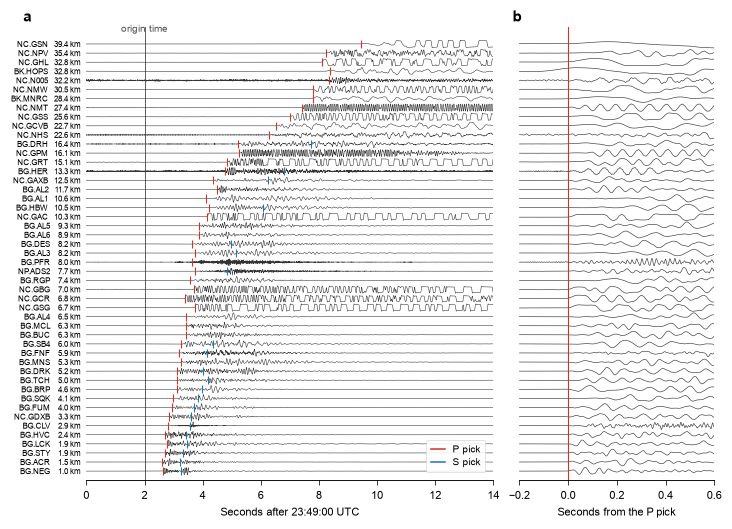

In [44]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

COLOUR = {"BG": "#e41a1c", "broadband": "#377eb8",
          "short-period": "#4daf4a", "strong-motion": "#984ea3"}
# This section is about the picks, so the picks carry the colour and the traces do not. Instrument
# class is already shown in § 3 and § 5; repeating it here would only compete with the arrivals.
P_COL, S_COL, TRACE = "#d7301f", "#1f78b4", "#333333"
SPAN, ZOOM_LO, ZOOM_HI = 14.0, -0.2, 0.6   # seconds drawn; the zoom window round the pick

got = {tr.stats.station: tr for tr in st}
rows = [r for r in show.itertuples() if r.sta in got]
picks = {(p.station, p.phase_type): obspy.UTCDateTime(str(p.phase_time)) for p in ev.itertuples()}

# 17 cm is the width the project's figures are drawn at; geometry in centimetres, as they do it
W, H = 17.0, 1.9 + 0.215 * len(rows)
fig = plt.figure(figsize=(W * CM, H * CM))
def panel(x, y, w, h):
    """An axes placed in centimetres from the lower-left corner of the figure."""
    return fig.add_axes([x / W, y / H, w / W, h / H])
ax = panel(2.05, 1.15, 9.4, H - 1.75)
bx = panel(12.05, 1.15, 4.5, H - 1.75)

# (a) the record section of § 5, with the archive's picks drawn on it
for i, r in enumerate(rows):
    w = got[r.sta].copy().trim(T0, T0 + SPAN)
    w.detrend("demean")
    y = w.data.astype(float)
    ax.plot(w.times(), 0.42 * y / np.abs(y).max() + i, lw=0.35, color=TRACE)
    for kind, colour in (("P", P_COL), ("S", S_COL)):
        if (r.sta, kind) in picks:
            xp = picks[(r.sta, kind)] - T0
            ax.vlines(xp, i - 0.45, i + 0.45, color=colour, lw=0.7, zorder=5)

ax.set_yticks(range(len(rows)))
ax.set_yticklabels([f"{r.net}.{r.sta}  {r.d:5.1f} km" for r in rows], fontsize=5)
ax.tick_params(axis="y", length=0)
ax.set(xlim=(0, SPAN), ylim=(-1, len(rows) + 0.9),
       xlabel=f"Seconds after {T0.datetime:%H:%M:%S} UTC")

# (b) the same traces aligned on their own P pick: if the picks are consistent, the onsets line up
aligned = [r for r in rows if (r.sta, "P") in picks]
for i, r in enumerate(aligned):
    tp = picks[(r.sta, "P")]
    w = got[r.sta].copy().trim(tp + ZOOM_LO, tp + ZOOM_HI)
    w.detrend("demean")
    y = w.data.astype(float)
    if not np.abs(y).max():
        continue
    bx.plot(w.times() + ZOOM_LO, 0.42 * y / np.abs(y).max() + i, lw=0.4, color=TRACE)

bx.axvline(0, color=P_COL, lw=0.7, zorder=5)
bx.set(xlim=(ZOOM_LO, ZOOM_HI), ylim=(-1, len(rows) + 0.9), yticks=[],
       xlabel="Seconds from the P pick")
for k, a_ in enumerate((ax, bx)):
    a_.text(-0.155 if k == 0 else -0.035, 1.005, "ab"[k], transform=a_.transAxes, fontsize=9.5,
            fontweight="bold", va="bottom", ha="left")

origin = obspy.UTCDateTime(REFERENCE_EVENT["time"]) - T0
ax.axvline(origin, color="#555555", lw=0.6, zorder=0)
ax.text(origin, len(rows) + 0.35, "origin time", fontsize=6.5, color="#555555", ha="center")

handles = [plt.Line2D([], [], color=P_COL, lw=1.0, label="P pick"),
           plt.Line2D([], [], color=S_COL, lw=1.0, label="S pick")]
leg = ax.legend(handles=handles, loc="lower right", fontsize=6.5, handlelength=1.4,
                labelspacing=.35, borderaxespad=.8, frameon=True, framealpha=.88,
                facecolor="white", edgecolor="#cccccc", borderpad=.5)
leg.get_frame().set_linewidth(.4)
leg.set_zorder(20)

for a in (ax, bx):
    for s_ in ("top", "right", "left"):
        a.spines[s_].set_visible(False)
plt.show()


In [45]:
# How well does an objective criterion reproduce the analyst? Each trace is high-pass filtered at
# 2 Hz -- causally, since § 7.4 showed a zero-phase filter smears the onset -- and the first sample
# exceeding five times the pre-pick noise is compared with the analyst's pick.
offsets = []
for r in aligned:
    tp = picks[(r.sta, "P")]
    w = got[r.sta].copy().trim(tp - 2.0, tp + 0.5)
    if w.stats.npts < 100:
        continue
    w.detrend("demean")
    w.filter("highpass", freq=2.0, corners=2, zerophase=False)
    y = np.abs(np.asarray(w.data, float))
    tt = w.times() - 2.0                          # seconds relative to the analyst's pick
    noise = y[(tt > -1.0) & (tt < -0.3)].std()
    hit = np.flatnonzero((tt > -0.3) & (y > 5 * noise))
    if noise > 0 and len(hit):
        offsets.append(tt[hit[0]])

offsets = np.array(offsets)
print(f"{len(offsets)} traces with a measurable onset, threshold minus analyst pick:")
print(f"  median   {np.median(offsets):+.3f} s")
print(f"  5th-95th {np.percentile(offsets, 5):+.3f} to {np.percentile(offsets, 95):+.3f} s")
print(f"  within 50 ms of the pick: {100 * np.mean(np.abs(offsets) < 0.05):.0f} % of traces")


48 traces with a measurable onset, threshold minus analyst pick:
  median   -0.018 s
  5th-95th -0.205 to +0.043 s
  within 50 ms of the pick: 65 % of traces


**Figure 8. The archive's phase picks for the reference event.** (a) Vertical-component records at
the stations of Figure 7, each normalised to its own peak, with the archive's P picks in red and S
picks in blue; the grey line is the catalogue origin time. (b) The same traces aligned on their own
P pick, over the interval −0.2 to +0.6 s about it. Instrument class is not shown here, since the
picks rather than the instruments are the subject; it is given in Figures 3 and 7.

Two features of the figure deserve attention, and the second is easily overlooked.

The P picks lie at the **onset** of the arrival, not at the first large excursion. An analyst reads
the earliest coherent departure from the noise, which on a noisy trace is a judgement rather than a
measurement, and panel (b) shows the consequence. The cell above quantifies it against a simple
objective criterion, the first sample exceeding five times the pre-pick noise. In the median the
two agree to about 20 milliseconds, which is reassuring, but the central 90 per cent of the offsets
spans roughly a quarter of a second, and the spread is asymmetric: the tail lies almost entirely on
the early side, where the threshold has fired on a fluctuation in the noise rather than on the
arrival.

Two conclusions follow. An amplitude threshold is not an onset detector, which is the entire reason
the phase-picking session exists. And when a neural picker trained on these labels is reported to achieve a
timing error of a few hundredths of a second, that error is measured against the analyst's
judgements rather than against a ground truth; the agreement between two reasonable criteria on the
same traces is a floor beneath which such a figure cannot be interpreted.

The positions of the S picks are equally informative. They occur only at the nearer stations, and
they fall within the P coda rather than in quiet noise. That is why there are approximately a tenth
as many of them as there are P picks, why the automatic picker produces none at all, and why every
method in this course that requires S arrivals operates on far less data than the total pick count
would suggest.


#### Sources

* Northern California Earthquake Data Center (2014). *Northern California Earthquake Data Center*.
  UC Berkeley Seismological Laboratory. Dataset. `10.7932/NCEDC` — the phase archive of the
  Northern California Seismic Network, distributed with this course as `geysers_phases_2016.csv.gz`
  after extraction for this region from a compiled copy of the archive.


## § 7 · Instrument response and magnitude

*This section establishes the conversion from a recorded integer to a physical ground motion, and
from a ground motion to a magnitude: what an instrument response is, how it is removed, what the
removal costs, and why the magnitude column of the catalogue is not a single quantity.*

### 7.1 · Why counts cannot be compared

Section 5 left a problem outstanding. The traces in Figure 7 span more than four orders of
magnitude in peak amplitude across stations that recorded the same earthquake, and the ordering
bears little relation to distance.

The explanation was given in § 5.1: a **count** is an integer written by a digitiser, and its
meaning depends on the sensitivity of the sensor, on the shape of that sensor's response as a
function of frequency, on the gain of the amplifier and on the resolution of the digitiser. Two
stations standing side by side with different instruments record different numbers for the same
ground motion, and neither number is wrong.

The relationship between ground motion and recorded counts is the **instrument response**, a
complex-valued transfer function of frequency describing both how much the system amplifies each
frequency and how much it delays it. It is conventionally specified by its **poles and zeros** —
the frequencies at which the response becomes infinite or vanishes — together with an overall
scaling called the sensitivity. Recovering ground motion means dividing the recorded spectrum by
this function, an operation called **deconvolving the instrument response**. It is a single
library call, and everything quantitative in this course depends on its having been made.


### 7.2 · The responses of this network

Requesting station metadata at `level="response"` returns, for every channel, the full transfer
function: the poles and zeros of each stage, the gain of each stage, and the overall sensitivity
relating counts to physical units.


In [46]:
import numpy as np
import pandas as pd
from obspy import UTCDateTime
from obspy.clients.fdsn import Client

near = event_stations()                          # the same 53 stations §§ 5 and 6 used
T0 = UTCDateTime(REFERENCE_EVENT["time"]) - 2
nc = Client("NCEDC", timeout=300)

inv = nc.get_stations(network=",".join(sorted(near.net.unique())),
                      station=",".join(sorted(near.sta.unique())),
                      channel="DPZ,EHZ,HHZ,BHZ,HNZ", level="response",
                      starttime=T0, endtime=T0 + 30)

rows = []
for net in inv:
    for sta in net:
        for c in sta:
            if c.response and c.response.instrument_sensitivity:
                s = c.response.instrument_sensitivity
                rows.append({"id": f"{net.code}.{sta.code}", "cha": c.code, "sps": c.sample_rate,
                             "sensitivity": s.value, "units": s.input_units})
resp = pd.DataFrame(rows).drop_duplicates("id")

print(f"{len(resp)} of {len(near)} stations returned a full response")
print(resp.groupby("units").sensitivity.agg(["count", "min", "median", "max"]).to_string())


48 of 53 stations returned a full response
        count         min       median           max
units                                               
M/S        46  62914500.0  230400000.0  3.949220e+09
M/S**2      2    256616.0     342508.0  4.284000e+05


Two conclusions follow. First, every channel has a response available, so there is no circumstance
in which an analysis need be conducted in counts. Second, the sensitivities span several orders of
magnitude and, more importantly, are quoted in **different physical units**: a seismometer reports
counts per metre per second, an accelerometer counts per metre per second squared. A comparison of
raw counts across instruments of the two kinds is not a comparison of any physical quantity.


### 7.3 · From counts to ground velocity

The effect of the conversion is best seen by measuring the peak amplitude of each trace before and
after the response is removed, across stations at comparable distances carrying different
instruments.

Two details of the cell below are worth stating in advance, because both are points at which a
plausible choice gives a wrong answer.

The **exclusion test for saturation is deliberately looser than the one in § 5.5**. That test
identified clipping and required the peak to coincide with the rail. Here traces are being excluded
from an amplitude measurement, and a record that merely approaches the rail has already had its
peak flattened and will under-report; anything above 90 per cent of full scale is therefore
discarded.

The **deconvolution band must be chosen for each trace**. Removing a response requires a taper,
specified by `pre_filt`, which rolls the spectrum off at both ends so that the division is not
performed where the instrument has negligible response. The conventional taper of 0.2 to 50 Hz lies
above the Nyquist frequency for every channel sampled below 100 samples per second. Applied
uniformly it makes the short-period stations read three orders of magnitude low, and the resulting
pattern is readily mistaken for a site effect.


In [47]:
import obspy

st = nc.get_waveforms_bulk([(r.net, r.sta, "*", r.cha, T0, T0 + 30) for r in near.itertuples()])
st.merge(method=1, fill_value=None)


def saturated(tr, rail=2048, margin=0.90):
    """Is this trace against the 12-bit rail?

    § 5 used a strict test -- the peak IS the rail and the trace returns there repeatedly -- which
    is right for *identifying* clipping. For *excluding* a trace from an amplitude measurement the
    test has to be looser: a record that merely comes close to the rail has already had its peak
    flattened, and it under-reports. Anything above 90 % of full scale is unusable here.
    """
    a = np.abs(np.asarray(tr.data, dtype=float))
    peak = a.max() if a.size else 0
    return bool(peak) and peak <= rail * 1.03 and peak >= rail * margin


def band(sps):
    """A deconvolution band that is valid for THIS trace.

    The taper has to sit below the Nyquist frequency. A single fixed band -- (0.2, 0.5, 40, 50) Hz
    is the conventional choice -- is above Nyquist for every channel sampled below 100 sps, and
    lands exactly on it at 100 sps. Using it everywhere makes short-period stations read three
    orders of magnitude low and the error looks like a site effect.
    """
    nyq = 0.5 * sps
    return (0.2, 0.5, min(40.0, 0.7 * nyq), min(50.0, 0.9 * nyq))


out = []
for tr in st:
    try:
        sta = inv.select(network=tr.stats.network, station=tr.stats.station,
                         channel=tr.stats.channel)[0][0]
    except Exception:
        continue                                  # no metadata for this channel at this time
    if isinstance(tr.data, np.ma.MaskedArray) or saturated(tr):
        continue                                  # gaps and railed traces are not measurements
    d = np.hypot((sta.latitude - REFERENCE_EVENT["lat"]) * 111.19,
                 (sta.longitude - REFERENCE_EVENT["lon"]) * 111.19
                 * np.cos(np.radians(REFERENCE_EVENT["lat"])))
    counts = float(np.abs(tr.data).max())
    w = tr.copy().detrend("demean")
    try:
        w.remove_response(inventory=inv, output="VEL", pre_filt=band(tr.stats.sampling_rate),
                          water_level=60)
    except Exception:
        continue                                  # the response will not invert on this channel
    out.append({"id": f"{tr.stats.network}.{tr.stats.station}", "cha": tr.stats.channel,
                "band": tr.stats.channel[:2], "dist_km": d, "peak_counts": counts,
                "peak_vel_mm_s": float(np.abs(w.data).max()) * 1e3})

amp = pd.DataFrame(out).sort_values("dist_km").reset_index(drop=True)
print(f"{len(amp)} usable traces (gaps and saturated records dropped)\n")

# How much headroom does each instrument have? Rather than assume a bit depth, measure the largest
# count any station of that kind actually reached on this event and compare it with the 2048-count
# rail of the old NCSN telemetry.
head = (pd.DataFrame([{"band": tr.stats.channel[:2],
                       "peak": float(np.abs(np.asarray(tr.data, float)).max())}
                      for tr in st if not isinstance(tr.data, np.ma.MaskedArray)])
        .groupby("band").peak.agg(["count", "median", "max"]))
head["x_the_12bit_rail"] = (head["max"] / 2048).round(1)
print("peak counts reached on this event, by instrument:")
print(head.round(0).to_string())

win = amp[amp.dist_km.between(3, 15)]
print(f"\nbetween 3 and 15 km, after dropping railed and gappy traces (n = {len(win)}):")
print(win.groupby("band").peak_vel_mm_s.agg(["count", "median"]).round(4).to_string())


37 usable traces (gaps and saturated records dropped)

peak counts reached on this event, by instrument:
      count    median        max  x_the_12bit_rail
band                                              
CN        1    4950.0     4950.0               2.0
DP       27  284539.0  1877870.0             917.0
EH       15    1981.0   137618.0              67.0
HH        3  132534.0  3319071.0            1621.0
HN        2   24428.0    44414.0              22.0

between 3 and 15 km, after dropping railed and gappy traces (n = 24):
      count  median
band               
DP       21  1.0085
EH        1  0.4162
HH        1  2.9409
HN        1  1.3492


 WARNING (norm_resp): computed and reported sensitivities differ by more than 5 percent. 
	 Execution continuing.


Removing the response converts an instrument-specific integer into a ground motion in physical
units, which is necessary. The tables show that it is not sufficient.

The headroom table is the substance of the matter, and the situation is not the simple one. The
**median** `EH` surface channel peaks at approximately 1,980 counts, essentially the 2,048-count
rail of the older 12-bit telemetry, while the **maximum** across `EH` channels lies far beyond it.
Both statements are true because the network is part-way through an upgrade, and 12-bit telemetry
and modern digitisers share the same channel code. The `DP` borehole and `HH` broadband channels
reach hundreds to thousands of times the old rail.

Most, though not all, `EH` records of this event are therefore against a rail and report the rail
rather than the ground, which is why the exclusion removes nearly all of them. What survives, in
the second table, agrees with the borehole measurements to within a factor of a few, and that
residual scatter is radiation pattern, path and site response — which is to say, signal.

**A response describes how to convert counts; it does not establish that the counts are
meaningful.** Sensitivity and dynamic range trade against one another, and an instrument optimised
to detect magnitude-zero events is the wrong instrument with which to measure a magnitude-three
one. This field is instrumented twice over for precisely that reason.

Two exclusions were applied before any measurement: **traces containing gaps**, where merging
across the gap yields a maximum that is real but meaningless, and **traces against the rail**,
which under-report their own peak in a manner no correction recovers.

**A warning appears in the output of the cell above, and it should be read rather than ignored.**
`WARNING (norm_resp): computed and reported sensitivities differ by more than 5 percent` is raised
by one channel of the forty-eight, `NC.GDXB.HHZ`. Every response is specified twice over: as a
chain of stages each with its own gain, and as a single overall sensitivity. The two should agree,
and for this channel they differ by 6.6 per cent — the stage gains multiply to 1.006 × 10⁹ counts
per metre per second where the overall sensitivity is quoted as 9.437 × 10⁸.

The discrepancy is small enough to be invisible in a plot and large enough to matter for an
amplitude. It is a defect in the metadata rather than in the recording, and it is the same class of
problem as the two stations of § 7.5 that report a thousand times too little: **a response is a
document about an instrument, and documents can be wrong.** The practical rule is that a library
warning during response removal is a statement about the data, not noise from the software, and a
channel that raises one should be excluded or investigated before its amplitude is used.

**An amplitude without a response is not a measurement of the ground.** Every later week that
quantifies anything — ground-motion prediction in the transformer session, moment tensors in the
moment-tensor session — requires this step, and none can recover it afterwards.


### 7.4 · Measuring an amplitude on one trace

A **magnitude** is a logarithmic measure of earthquake size. Richter's construction, which defines
local magnitude, is to measure the largest excursion a **specified standard instrument** would have
recorded had it stood at that station, and then to correct that amplitude for the distance the
waves travelled. The standard instrument is the Wood–Anderson torsion seismometer, a mechanical
device of the 1930s, and the definition is tied to it. Once the real instrument response has been
removed, the Wood–Anderson can be simulated from its own poles and zeros, which is how a modern
digital record is made commensurable with a definition written for a different machine.

The cell below follows one station through three stages: what the digitiser recorded, what the
ground did, and what a Wood–Anderson would have drawn. The amplitude entering a magnitude is the
peak of the third.


In [48]:
WOOD_ANDERSON = {"poles": [-6.283 - 4.712j, -6.283 + 4.712j], "zeros": [0j],
                 "gain": 1.0, "sensitivity": 2080.0}

pick = amp.sort_values("dist_km").iloc[len(amp) // 3]        # a clean station at middling distance
tr = [x for x in st if f"{x.stats.network}.{x.stats.station}" == pick.id][0]
print(f"{pick.id}.{tr.stats.channel}  {tr.stats.sampling_rate:.0f} sps  {pick.dist_km:.1f} km")

raw = tr.copy().detrend("demean")
vel = tr.copy().detrend("demean")
vel.remove_response(inventory=inv, output="VEL", pre_filt=band(tr.stats.sampling_rate),
                    water_level=60)
wa = tr.copy().detrend("demean")
wa.remove_response(inventory=inv, output="DISP", pre_filt=band(tr.stats.sampling_rate),
                   water_level=60)
wa.simulate(paz_simulate=WOOD_ANDERSON)

a_mm = float(np.abs(wa.data).max()) * 1e3
print(f"  peak counts                {np.abs(raw.data).max():12,.0f}")
print(f"  peak ground velocity       {np.abs(vel.data).max() * 1e3:12.3f} mm/s")
print(f"  peak Wood-Anderson displ.  {a_mm:12.3f} mm   <- the magnitude amplitude")


BG.MNS.DPZ  500 sps  5.3 km
  peak counts                     705,696
  peak ground velocity              3.152 mm/s
  peak Wood-Anderson displ.         7.346 mm   <- the magnitude amplitude


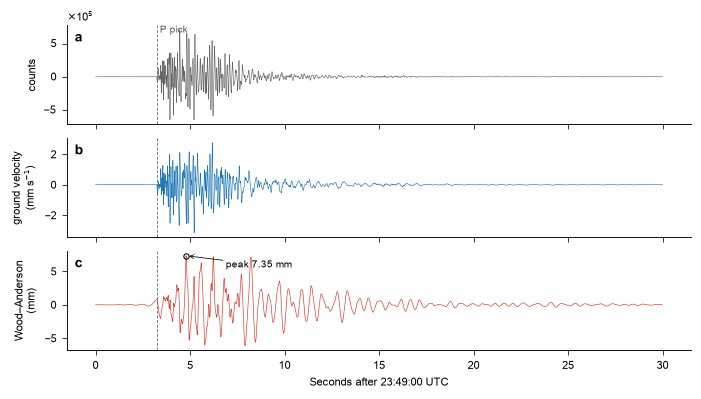

In [49]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

ev_p = phases(2016)
ev_p = ev_p[(ev_p.event_id == REFERENCE_EVENT["id"]) & (ev_p.station == tr.stats.station)
            & (ev_p.phase_type == "P")]
t_pick = obspy.UTCDateTime(str(ev_p.phase_time.iloc[0])) - T0

W, H = 17.0, 9.0
fig, axs = plt.subplots(3, 1, figsize=(W * CM, H * CM), sharex=True)
fig.subplots_adjust(left=2.3 / W, right=1 - 0.3 / W, top=1 - 0.5 / H, bottom=1.0 / H,
                    hspace=0.14)
stages = [(raw, np.asarray(raw.data, float), "counts", "#666666"),
          (vel, np.asarray(vel.data, float) * 1e3, "ground velocity\n(mm s$^{-1}$)", "#1f78b4"),
          (wa, np.asarray(wa.data, float) * 1e3, "Wood–Anderson\n(mm)", "#d7301f")]
for ax, (w, y, lab, colour) in zip(axs, stages):
    ax.plot(w.times(), y, lw=0.4, color=colour)
    ax.axvline(t_pick, color="0.35", lw=0.5, ls=(0, (4, 2)), zorder=0)
    ax.set_ylabel(lab, fontsize=7)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
axs[0].text(t_pick, axs[0].get_ylim()[1], " P pick", fontsize=6.5, color="0.35", va="top")
for k, a_ in enumerate(axs):
    a_.text(.012, .94, "abc"[k], transform=a_.transAxes, fontsize=9, fontweight="bold", va="top",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

k = int(np.argmax(np.abs(stages[2][1])))
t_peak, y_peak = wa.times()[k], stages[2][1][k]
axs[2].plot([t_peak], [y_peak], "o", ms=3.5, mfc="none", mec="black", mew=0.7)
# the annotation stays inside its own panel: pointing up put the text over panel (b)
axs[2].annotate(f"peak {abs(y_peak):.2f} mm", (t_peak, y_peak), xytext=(26, -6),
                textcoords="offset points", fontsize=6.5, va="center",
                arrowprops=dict(arrowstyle="->", lw=0.5, shrinkA=0, shrinkB=2))
axs[2].set_xlabel(f"Seconds after {T0.datetime:%H:%M:%S} UTC")
fig.align_ylabels(axs)                            # the tick widths differ, so align them explicitly
axs[0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useMathText=True)
plt.show()


**Figure 9. One record at three stages of processing.** (a) Raw counts as written by the
digitiser; (b) ground velocity after the instrument response has been removed; (c) the displacement
a Wood–Anderson torsion seismometer would have recorded, simulated from the same record, with its
peak marked. The dashed line is the analyst's P pick; all three panels share a time axis.

#### An artefact before the arrival

Because the three panels share a time axis, what happens immediately *before* the P pick can be
compared between them. The raw counts are flat there, as they must be, since nothing has yet
arrived. The Wood–Anderson trace is not.


In [50]:
def pre_p_ratio(w, t_pick, guard=0.5):
    """Largest amplitude before the arrival, as a fraction of the trace's peak."""
    x, y = w.times(), np.abs(np.asarray(w.data, float))
    return y[(x > 0.3) & (x < t_pick - guard)].max() / y.max()


bare = tr.copy().detrend("demean")
bare.remove_response(inventory=inv, output="DISP", pre_filt=None, water_level=None)
bare.simulate(paz_simulate=WOOD_ANDERSON)

print(f"  raw counts                          {pre_p_ratio(raw, t_pick):.5f}")
print(f"  Wood-Anderson, tapered + stabilised {pre_p_ratio(wa, t_pick):.5f}")
print(f"  Wood-Anderson, no regularisation    {pre_p_ratio(bare, t_pick):.5f}")


  raw counts                          0.00044
  Wood-Anderson, tapered + stabilised 0.02014
  Wood-Anderson, no regularisation    1.00000


The energy preceding the arrival is an **artefact of the deconvolution rather than a signal**.
Removing a response is a division in the frequency domain, and the two devices that make that
division stable — the cosine taper `pre_filt` and the `water_level` which prevents division by very
small numbers — are both **zero-phase** operations. A zero-phase filter is acausal: it spreads
energy symmetrically in time, so a sharp onset acquires a symmetric precursor that was never
present in the ground.

The third line of the output shows that the alternative is worse. With no taper and no water level,
the deconvolution amplifies noise at frequencies where the instrument has almost no response, and
the apparent precursor becomes as large as the earthquake itself. The regularisation is not
optional, and its acausality is the price of it.

Two practical consequences follow. **Arrival times should not be picked on deconvolved traces**
without accounting for this, since the onset has been smeared symmetrically; that bears directly on
the phase-picking session. And where a deconvolved record shows something unexpected before an arrival, the
processing should be suspected before the Earth.

#### What the three stages mean

The three traces have the same shape and entirely different meanings. The first is an
instrument-specific integer. The second is the ground, in physical units, comparable with any other
station. The third is a **convention**: what a particular instrument of the 1930s would have drawn,
which is the quantity on which a local magnitude is defined. Richter's scale is tied to that
instrument, and simulating it is how a modern record is made commensurable with the definition.

### 7.5 · Amplitude against distance

Repeating the measurement on every usable station produces the raw material of a magnitude scale:
the logarithm of amplitude falling with the logarithm of distance. The slope of that relation is
the **attenuation**, the combined effect of geometrical spreading, as a fixed amount of energy is
distributed over an expanding wavefront, and of absorption within the rock.


In [51]:
wa_rows = []
for tr_ in st:
    sid = f"{tr_.stats.network}.{tr_.stats.station}"
    if sid not in set(amp.id):                      # already excluded: gaps, clipping, no response
        continue
    try:
        w = tr_.copy().detrend("demean")
        w.remove_response(inventory=inv, output="DISP", pre_filt=band(tr_.stats.sampling_rate),
                          water_level=60)
        w.simulate(paz_simulate=WOOD_ANDERSON)
    except Exception:
        continue                                  # as above: no usable response for this channel
    d = float(amp.loc[amp.id == sid, "dist_km"].iloc[0])
    wa_rows.append({"id": sid, "dist_km": d, "amp_mm": float(np.abs(w.data).max()) * 1e3})

W = pd.DataFrame(wa_rows)
W = W[(W.amp_mm > 0) & W.dist_km.between(1, 45)]
slope, intercept = np.polyfit(np.log10(W.dist_km), np.log10(W.amp_mm), 1)
print(f"{len(W)} Wood-Anderson amplitudes, {W.dist_km.min():.1f}-{W.dist_km.max():.1f} km")
print(f"log10(A_mm) = {slope:.2f} log10(r_km) + {intercept:.2f}")


37 Wood-Anderson amplitudes, 1.0-35.3 km
log10(A_mm) = -1.04 log10(r_km) + 1.08


 WARNING (norm_resp): computed and reported sensitivities differ by more than 5 percent. 
	 Execution continuing.


#### Two stations three decades low

Two stations lie a factor of a thousand below the trend. They are worth pursuing, because the
explanation is none of those encountered so far.


In [52]:
W = W.assign(resid=np.log10(W.amp_mm) - (slope * np.log10(W.dist_km) + intercept))
odd = W.nsmallest(2, "resid")
print(odd[["id", "dist_km", "amp_mm", "resid"]].round(3).to_string(index=False))

for sid in odd.id:
    tr_ = [x for x in st if f"{x.stats.network}.{x.stats.station}" == sid][0]
    y = np.abs(np.asarray(tr_.data, float) - np.mean(tr_.data))
    x = tr_.times()
    noise = y[(x > 0.2) & (x < 2.5)].std()
    print(f"  {sid}: peak {y.max():10,.0f} counts, noise rms {noise:7,.1f}, "
          f"SNR {y.max() / max(noise, 1e-9):8.0f}")


    id  dist_km  amp_mm  resid
BG.PFR    8.009   0.004 -2.491
BG.HER   13.294   0.003 -2.427
  BG.PFR: peak      7,805 counts, noise rms    30.8, SNR      253
  BG.HER: peak        603 counts, noise rms    18.5, SNR       33


The two are **not** clipped, do not contain gaps, and are not quiet: both recorded the earthquake
with a good signal-to-noise ratio on a normal noise floor, using the same borehole instrument as
their neighbours and carrying the same stated sensitivity. They simply report a thousand times less
ground motion than stations at comparable distance.

That combination — a healthy noise floor, a healthy signal-to-noise ratio, and an amplitude wrong
by three orders of magnitude — indicates an error in the **bookkeeping rather than in the Earth**:
a gain applied at the station, or recorded in the response, which the metadata do not describe
correctly. Which of the two it is cannot be settled from within this notebook, and the appropriate
course is to say so, to exclude the two stations from the fit, and to report that they were
excluded.

The fit is therefore repeated without them. **A least-squares slope is not robust**: two points
three decades away will bend it appreciably, so a slope quoted as an attenuation exponent would be
in part a statement about two miscalibrated stations.


In [53]:
keep = W[W.resid > -1.5]
slope_r, intercept_r = np.polyfit(np.log10(keep.dist_km), np.log10(keep.amp_mm), 1)
print(f"all {len(W)} stations      slope {slope:.2f}")
print(f"{len(keep)} after exclusion  slope {slope_r:.2f}")


all 37 stations      slope -1.04
35 after exclusion  slope -0.90


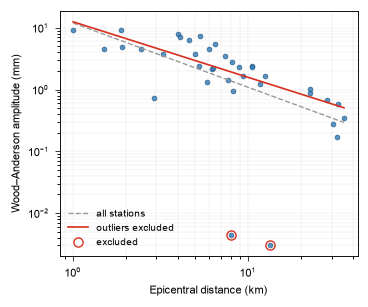

In [54]:
fig, ax = plt.subplots(figsize=(8.6 * CM, 7.0 * CM))
fig.subplots_adjust(left=0.17, right=0.97, top=0.95, bottom=0.14)
ax.loglog(W.dist_km, W.amp_mm, "o", ms=3.2, mfc="#377eb8", mec="#1f4e79", mew=0.4, alpha=0.85)
r = np.logspace(np.log10(W.dist_km.min()), np.log10(W.dist_km.max()), 50)
ax.loglog(r, 10 ** (slope * np.log10(r) + intercept), "--", color="#999999", lw=0.9,
          label="all stations")
ax.loglog(r, 10 ** (slope_r * np.log10(r) + intercept_r), "-", color="#d7301f", lw=1.1,
          label="outliers excluded")
ax.loglog(odd.dist_km, odd.amp_mm, "o", ms=6, mfc="none", mec="#d7301f", mew=0.9,
          label="excluded")
ax.set(xlabel="Epicentral distance (km)", ylabel="Wood–Anderson amplitude (mm)")
ax.legend(frameon=False, loc="lower left")
ax.grid(which="both", lw=0.3, color="0.9")
plt.show()


**Figure 10. Wood–Anderson amplitude against epicentral distance for the reference event.** Each
point is one station. The dashed line is a least-squares fit to all stations, the solid line the
same fit with the two anomalous stations, circled, excluded. Both axes are logarithmic.

The scatter that remains is what a magnitude scale must accommodate, and it is still substantial: a
factor of several at the same distance, arising from the radiation pattern of the source and from
the response of the site. Richter averaged over stations. The modern treatment fits a **station
term** for each site alongside the distance term, and estimating those terms with their
uncertainties is precisely the regression problem of the regression session. This section stops at the
data that problem requires.

No absolute magnitude is computed here. Doing so would require a calibration curve for this region,
and the constants of a published attenuation relation are fitted to a particular network and a
particular set of instruments. Borrowing one from elsewhere without saying so is how magnitudes
cease to be comparable between studies.


### 7.6 · What the catalogue's magnitude column contains

Section 4.5 established that `magType` changes with event size. With the measurement of § 7.4 in
hand, the consequence can be stated precisely.


In [55]:
cat = catalog()
mt = cat.groupby("magType").mag.agg(["count", "min", "median", "max"])
print(mt.sort_values("count", ascending=False).to_string())


          count   min  median   max
magType                            
d        397767 -0.81    0.87  4.60
dl        20590  0.01    0.51  2.41
l           505  1.37    3.15  5.70
w           200  2.87    3.78  5.01
a           135  0.06    0.99  2.29
h            51  0.00    2.20  2.90


**`d` is a coda-duration magnitude.** It is not measured from an amplitude at all. It is a
calibration against the length of time for which the signal remains above the noise, which is
inexpensive to compute on a short-period network, remains usable on a clipped record, and dominates
this catalogue below approximately magnitude 3. **`l` is a local magnitude** in Richter's sense,
measured from an amplitude in the manner of § 7.4. **`w` is a moment magnitude**, derived from the
seismic moment through a waveform inversion, and is the only one of the three that is a property of
the source rather than of a measurement convention.

The magnitude column is therefore a **mixture of three physically different quantities**, selected
by event size and by what the analyst had available. Three consequences follow, and they are the
reason this section exists.

1. A frequency–magnitude distribution fitted across the whole range crosses a change of scale near
   magnitude 3. Section 9 does exactly that, because there is no alternative, and says so.
2. A difference of a few hundredths in the *b*-value between two periods may reflect a change in
   the *mixture* of magnitude types rather than any change in the earthquakes.
3. Any quantity requiring a physically defined magnitude — a moment budget, a stress drop, a
   comparison with the catalogue of another region — requires `w`, and this catalogue contains 200
   of those.


#### Sources and further reading

* Northern California Earthquake Data Center (2014). *Northern California Earthquake Data Center*.
  UC Berkeley Seismological Laboratory. Dataset. `10.7932/NCEDC` — the waveforms and instrument
  responses retrieved in this section.
* Richter, C. F. (1935). An instrumental earthquake magnitude scale. *Bulletin of the
  Seismological Society of America*, 25(1), 1–32. `10.1785/bssa0250010001` — the definition
  simulated in § 7.4, including the Wood–Anderson instrument and the distance correction.
* Hutton, L. K., & Boore, D. M. (1987). The *M*<sub>L</sub> scale in southern California. *Bulletin
  of the Seismological Society of America*, 77(6), 2074–2094. `10.1785/bssa0770062074` — the modern
  re-calibration of that distance correction, and the regression of the regression session.


## § 8 · Focal mechanisms

*This section establishes the focal mechanisms: what one is and how it is determined from first
motions, the convention in the archive that will rotate every solution by ninety degrees if it is
overlooked, a station polarity problem discovered by checking one event against its own waveforms,
and the 37,867 solutions surviving the quality cut, summarised by faulting style and as summed
double couples.*

### 8.1 · What a focal mechanism is

A location and a magnitude say where an earthquake happened and how large it was. A **focal
mechanism** says how the rock moved: the orientation of the fault that slipped and the direction
in which it slipped.

Three angles specify this completely. The **strike** is the compass direction of the fault's
intersection with a horizontal plane; the **dip** is the angle by which the fault plane descends
from horizontal; and the **rake** is the direction of slip measured within the fault plane. The
combination is conventionally drawn as a **beachball**: the lower half of a small sphere
surrounding the source, projected onto a disc, shaded where the first ground motion is outward and
left white where it is inward.

The reason such a diagram is informative is that slip on a fault does not radiate energy equally in
all directions. It radiates in a four-lobed **radiation pattern**, and the sense of the first
motion — whether the ground at a station first moves away from the source or towards it — depends
on which lobe that station lies in. Reading the direction of first motion at many stations
therefore samples the pattern, and the mechanism is the fault orientation consistent with the
observed set of readings.

Two limitations of the construction are important throughout. The pattern is symmetric under
exchange of the fault plane with the plane perpendicular to the slip direction, so first motions
determine the mechanism only up to an **ambiguity between two planes**, the **auxiliary plane**
being indistinguishable from the fault itself without further information. And a first-motion
solution constrains only the **double couple**, the shear part of the source. It gives no
information about the size of the moment, nor about any volumetric change at the source. The
moment-tensor session contrasts this with the full moment tensor, which waveforms constrain and
first motions cannot.


### 8.2 · Loading the solutions, and a column that is not what its position implies

The solutions are derived from the monthly `.mech` files of the NCEDC, cut to this region and
distributed with the course. `mechanisms()` reads the file and `quality()` applies the rule
declared as fact 4 in § 0.8: one solution per event, the one of lowest misfit, retaining only
those determined from at least ten first motions with a misfit of 0.2 or less.

One property of the format must be stated before any of it is used. The three orientation fields
of a `.mech` record are **dip direction, dip, rake** — not strike, dip, rake. The dip direction is
perpendicular to the strike, so `strike = dip_direction − 90`. Both readings produce plausible
integers, nothing downstream raises an error, and interpreting the first column as a strike rotates
every mechanism in the catalogue by ninety degrees.


In [56]:
raw_mech = mechanisms()
good = quality(raw_mech)
print(f"{len(raw_mech):,} solutions in the file for {raw_mech.id.nunique():,} events; "
      f"{len(good):,} survive the quality cut")
print(f"columns: {', '.join(good.columns)}")
print(f"\nstrike = dip_direction - 90, checked on the first rows:")
print(good[["dip_direction", "strike", "dip", "rake", "nfm", "misfit"]].head(4).to_string(index=False))


56,396 solutions in the file for 46,395 events; 37,867 survive the quality cut
columns: id, lat, lon, depth, mag, magtype, nph, gap, dip_direction, strike, dip, rake, misfit, nfm, d_strike, d_dip, d_rake, multiple, time, p_az, p_pl, t_az, t_pl, b_az, b_pl, faulting, faulting_index

strike = dip_direction - 90, checked on the first rows:
 dip_direction  strike  dip  rake  nfm  misfit
           120      30   70   -80   29     0.0
           150      60   40   -20   30     0.0
            70     340   45  -130   25     0.0
           140      50   85  -100   28     0.0


The error is caught without recourse to documentation. The mean orientation of the P axes gives
the direction of maximum compression, and that direction is known independently for the northern
Coast Ranges, where it is approximately north-northeast. Reading the column as a strike places the
P axes near N118°E; reading it as a dip direction and subtracting ninety places them near N28°E.
Only the second is compatible with the tectonic setting established in § 1.1.

**A column position is not its meaning** — the third instance of the problem named in § 1.3, after
the file name of § 1 and the column name of § 2, and the reason this notebook states the convention
explicitly rather than inferring it from the data.


### 8.3 · Where a mechanism comes from: one event, read from its waveforms

Before forty-six thousand solutions are used, it is worth deriving one. The reference event of
§§ 5 to 7 carries first-motion readings in the phase archive, so the published mechanism can be
checked against the observations it was supposedly built from — and, as it turns out, against
something that had gone wrong in them.


In [57]:
import numpy as np
import obspy
from obspy.clients.fdsn import Client
from obspy.imaging.beachball import aux_plane, beach

ev = phases(2016)
ev = ev[ev.event_id == REFERENCE_EVENT["id"]]
pol = ev[ev.phase_polarity.isin(["U", "D"]) & ev.takeoff_angle.notna()].copy()
pol["up"] = pol.phase_polarity == "U"

print(f"M {REFERENCE_EVENT['mag']} of {REFERENCE_EVENT['time'][:10]}: {len(pol)} first motions, "
      f"{pol.up.sum()} up and {(~pol.up).sum()} down")
print(f"azimuths {pol.azimuth.min():.0f}-{pol.azimuth.max():.0f}°, "
      f"take-off angles {pol.takeoff_angle.min():.0f}-{pol.takeoff_angle.max():.0f}° "
      f"({(pol.takeoff_angle > 90).sum()} up-going rays)")


M 2.91 of 2016-03-31: 76 first motions, 30 up and 46 down
azimuths 4-342°, take-off angles 43-160° (32 up-going rays)


A take-off angle above 90° is a ray that left the source going *upwards*; the shallow sources in
this field send most of their energy up to the surface stations. Azimuth and take-off angle
together place each reading on the **focal sphere**, and the polarity says which side of the
nodal surfaces it fell on.

The network has already solved for the mechanism, so take its answer rather than repeating the
inversion.


In [58]:
usgs = Client("USGS", timeout=120).get_events(
    starttime=obspy.UTCDateTime(REFERENCE_EVENT["time"]) - 5,
    endtime=obspy.UTCDateTime(REFERENCE_EVENT["time"]) + 5,
    minlatitude=38.7, maxlatitude=38.95, minlongitude=-122.9, maxlongitude=-122.6,
    includeallorigins=True)[0]

fm = usgs.focal_mechanisms[0]
n1 = fm.nodal_planes.nodal_plane_1
SOLUTION = (n1.strike, n1.dip, n1.rake)
print(f"published solution ({fm.creation_info.agency_id}): "
      f"strike {n1.strike:.0f}°, dip {n1.dip:.0f}°, rake {n1.rake:.0f}°")
print(f"moment tensors for this event: {sum(1 for f in usgs.focal_mechanisms if f.moment_tensor)}")


published solution (NC): strike 35°, dip 40°, rake -50°
moment tensors for this event: 0


**There is no moment tensor.** For an M 2.9 there almost never is: a tensor is fitted to full
waveforms at regional distances and needs signal at periods this event does not radiate strongly.
Across the download box, of the **210 events of M ≥ 3.5 since 1990, 159 carry a moment tensor**,
and below that magnitude the number collapses. That is the contrast **moment tensors** is built on:
tens of thousands of first-motion solutions against a few hundred tensors — one cheap and
orientation-only, the
other expensive and complete.

Now check the published solution against the readings it was derived from. `radiation_p()` in § 0
gives the sign a double couple predicts for a ray leaving at a given azimuth and take-off angle.


In [59]:
predicted_up = radiation_p(*SOLUTION, pol.azimuth.values, pol.takeoff_angle.values) > 0
agree = (predicted_up == pol.up.values)
print(f"the published mechanism agrees with {agree.sum()} of {len(pol)} archived polarities "
      f"({1 - agree.mean():.2f} misfit)")


the published mechanism agrees with 40 of 76 archived polarities (0.47 misfit)


**That is a coin flip.** The catalogue's own mechanism does not explain the catalogue's own
polarities. Something is wrong, and it is not the mechanism.

#### The polarity of a channel is metadata, and metadata can be wrong

Whether a positive count means the ground moved up depends on which way the sensor's vertical
component is wired and on what the station metadata claims. Both can be wrong, and neither is
checked by anything downstream. The way to find out is statistical: take every polarity pick ever
made at a station and ask how often the analyst's reading agrees with the sign the metadata
implies. A station that disagrees almost always is reversed.

That check has been run over the whole archive and is published with this course.


In [60]:
sp = station_polarity()
t_ev = pd.Timestamp(REFERENCE_EVENT["time"]).tz_localize(None)
current = sp[(sp.epoch_begin <= t_ev) & (sp.epoch_end >= t_ev)]
pol = pol.merge(current[["network", "station", "instrument", "z_dip_metadata", "agree_fraction"]]
                .drop_duplicates(["network", "station", "instrument"]),
                on=["network", "station", "instrument"], how="left")

reversed_ = pol.agree_fraction.lt(0.5).fillna(False)
print(f"{reversed_.sum()} of {len(pol)} readings come from stations whose picks disagree with "
      f"their own metadata more than half the time")
print(pol[reversed_].groupby("network").size().to_string())
print("\nagreement fraction at those stations:")
print(pol.loc[reversed_, ["network", "station", "agree_fraction"]]
      .drop_duplicates().head(6).to_string(index=False))


28 of 76 readings come from stations whose picks disagree with their own metadata more than half the time
network
BG    26
BK     2

agreement fraction at those stations:
network station  agree_fraction
     BG     ACR           0.120
     BG     NEG           0.035
     BG     HVC           0.049
     BG     STY           0.057
     BG     LCK           0.063
     BG     CLV           0.069


The reversed stations are almost all **BG** — the borehole network — and they disagree with their
metadata not marginally but overwhelmingly, on thousands of picks each. This is a systematic sign
convention, not noise.

Flip those readings and ask the same question again.


In [61]:
corrected = np.where(reversed_.values, ~pol.up.values, pol.up.values)
pol["corrected_up"] = corrected
agree_c = (predicted_up == corrected)
print(f"as archived: {agree.sum():2d} of {len(pol)} agree  ({1 - agree.mean():.2f} misfit)")
print(f"corrected:   {agree_c.sum():2d} of {len(pol)} agree  ({1 - agree_c.mean():.2f} misfit)")


as archived: 40 of 76 agree  (0.47 misfit)
corrected:   62 of 76 agree  (0.18 misfit)


From a coin flip to a normal first-motion misfit. **The archive's polarity column and the
published mechanism are in different sign conventions for the borehole network**, and nothing in
either file says so. Use the polarities as they come and every mechanism you compute will be
wrong in a way that looks like poor data.

This is the third time in this notebook that a convention has had to be recovered from outside
the file: the fault-age file order in § 1, the units in § 2, and now the sign of a first motion.
**moment tensors** depends on getting this one right.


71 stations with a reading and a usable waveform; 39 of 76 readings have coordinates
detect_first_motion agrees with the analyst on 54 of 71 traces


nodal planes: 35/40/-50 and 167/61/-118


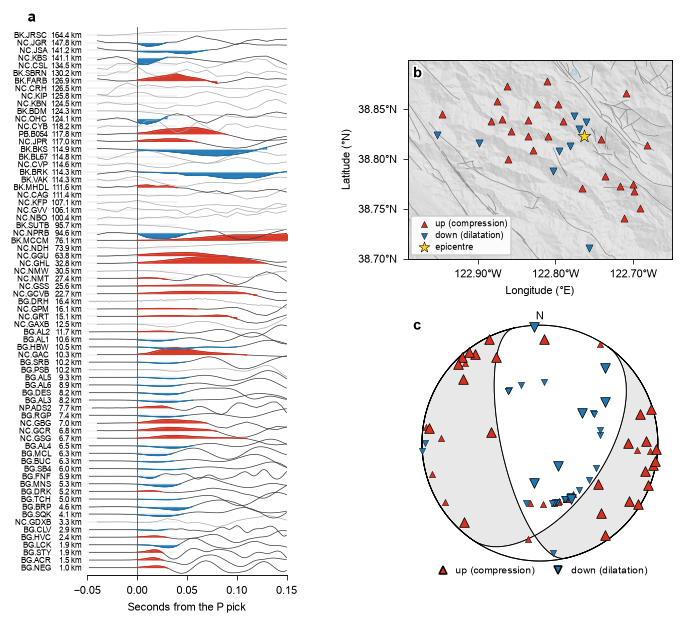

In [62]:
import matplotlib.pyplot as plt

T0 = obspy.UTCDateTime(REFERENCE_EVENT["time"]) - 2
sites_df = sites()
nc = Client("NCEDC", timeout=300)
coords = sites_df.set_index(["Network", "Station"])[["lat", "lon"]]
pol = pol.join(coords, on=["network", "station"])

have = pol.sort_values("distance_km")
# three components, because `detect_first_motion` takes an (E, N, Z) array
st = nc.get_waveforms_bulk([(r.network, r.station, "*", f"{r.instrument}?", T0, T0 + 30)
                            for r in have.itertuples()])
got = {}
for tr in st:
    got.setdefault(tr.stats.station, {})[tr.stats.channel[-1]] = tr
def vertical(sta):
    """The Z trace of a station, whatever the third component is called."""
    d = got.get(sta) or {}
    for k in ("Z", "3"):
        if k in d and len(d[k].data):
            return d[k]
    return None


def usable(r):
    tr_ = vertical(r.station)
    if tr_ is None:
        return False
    tp = obspy.UTCDateTime(str(r.phase_time))
    return tr_.stats.starttime <= tp - 1.5 and tr_.stats.endtime >= tp + 1.5


rows = [r for r in have.itertuples() if usable(r)]
print(f"{len(rows)} stations with a reading and a usable waveform; "
      f"{pol.lat.notna().sum()} of {len(pol)} readings have coordinates")

UP, DOWN = "#d7301f", "#1f78b4"
L = layers()

# (a) fills the left column and is as tall as it needs to be for one row per station; (b) and (c)
# are square boxes stacked on the right and centred against it
# geometry in centimetres at the project's 17 cm width; the two right-hand panels are square and
# aligned with the top and bottom of (a), so the column has no dead space at either end
W = 17.0
SIDE, GAP = 6.1, 0.5
H = max(2 * SIDE + GAP + 1.6, 0.170 * len(rows) + 1.7)
fig = plt.figure(figsize=(W * CM, H * CM))
def panel(x, y, w, h):
    """An axes placed in centimetres from the lower-left corner of the figure."""
    return fig.add_axes([x / W, y / H, w / W, h / H])
bot, top = 1.15, H - 0.5
axa = panel(2.2, bot, 4.6, top - bot)
axb = panel(9.6, top - SIDE, SIDE, SIDE)
axc = panel(9.6, bot, SIDE, SIDE)

# (a) The first motion itself. Three things make the sign readable that did not before:
#   * the window is short -- 0.05 s of noise then 0.15 s of signal -- so the first swing fills it;
#   * each trace is normalised on that first swing, not on the whole record, so a large later
#     arrival cannot shrink the thing we are trying to see;
#   * the half-cycle after the pick is filled, so the sign is a block of colour and not a wiggle.
PRE, POST = 0.05, 0.15
n_readable = 0
near_rows = rows                                  # every station that recorded a first motion

detected, matched = [], 0
for i, r in enumerate(near_rows):
    tp = obspy.UTCDateTime(str(r.phase_time))
    z = vertical(r.station).copy().trim(tp - 1.5, tp + 1.5)
    if len(z.data) < 40:
        detected.append(None)
        continue
    sr = z.stats.sampling_rate

    # the three components on one grid, Z last, as detect_first_motion expects
    comps = got[r.station]
    n = len(z.data)
    arr = np.zeros((3, n))
    for k, names in enumerate((("E", "1"), ("N", "2"), ("Z", "3"))):
        for nm in names:
            if nm in comps:
                w_ = comps[nm].copy().trim(tp - 1.5, tp + 1.5)
                w_.detrend("demean")
                w_.filter("highpass", freq=2.0, corners=2, zerophase=False)
                m = min(n, len(w_.data))
                arr[k, :m] = np.asarray(w_.data[:m], float)
                break

    j = int(round(1.5 * sr))                       # the pick sits 1.5 s into the window
    PRE_N, POST_N = max(3, int(0.02 * sr)), max(4, int(0.10 * sr))
    fm = detect_first_motion(arr, j, pre_window=PRE_N, post_window=POST_N)
    detected.append(fm)
    label = (fm or {}).get("label", "")
    matched += int(label == r.phase_polarity)

    # The detector measures the first swing against the mean of the samples just BEFORE the pick,
    # not against zero. That baseline is the starting level, and it is what the fill below is drawn
    # to -- otherwise the shaded area is not the quantity the polarity was decided on.
    z = arr[2]
    baseline = z[j - PRE_N:j].mean()
    yb = z - baseline

    # walk forward exactly as detect_first_motion does, to find where the first swing turns back
    end = j
    for ii in range(POST_N - 1):
        s_now, s_next = yb[j + ii], yb[j + ii + 1]
        if (s_now <= 0 and s_now < s_next) or (s_now > 0 and s_now > s_next):
            end = j + ii
            break
    else:
        end = j + POST_N - 1

    # the detector stops at the first extremum; for the figure, carry on to where the swing comes
    # back to the baseline, so the shaded area is the whole first wiggle rather than half of it
    x = np.arange(n) / sr - 1.5
    keep = (x >= -PRE) & (x <= POST)
    swing = np.sign(yb[j + 1]) if j + 1 < len(yb) else 0
    end_fill = end
    while end_fill + 1 < len(yb) and np.sign(yb[end_fill + 1]) == swing:
        end_fill += 1

    swing_amp = np.abs(yb[j:j + POST_N]).max()          # the first motion, for the SNR test
    noise = np.abs(yb[:j - PRE_N]).std()
    shown = np.abs(yb[keep]).max()                      # everything drawn, for the vertical scale
    if not swing_amp or not shown:
        continue
    snr = swing_amp / noise if noise else np.inf
    yn = 0.88 * yb / shown                 # deliberately large; a little overlap is fine

    # grey means "do not trust this one": either the detector found nothing, or the swing is in
    # the noise, or the detector and the analyst disagree about which way the ground first moved
    agrees = label == r.phase_polarity
    readable = snr >= 3.0 and label in ("U", "D") and agrees
    colour = (UP if label == "U" else DOWN) if readable else "#bdbdbd"
    axa.plot([-PRE, 0.04], [i, i], color="#cccccc", lw=0.3, zorder=0)   # the pre-arrival level
    axa.plot(x[keep], yn[keep] + i, lw=0.45, color="#333333" if readable else "#aaaaaa")
    if readable:
        axa.fill_between(x[j:end_fill + 2], i, yn[j:end_fill + 2] + i, color=colour,
                         alpha=0.95, lw=0)
        axa.plot(x[j:end_fill + 2], yn[j:end_fill + 2] + i, lw=0.7, color=colour, zorder=4)

    n_readable += int(readable)

print(f"detect_first_motion agrees with the analyst on {matched} of {len(near_rows)} traces")

axa.axvline(0, color="0.25", lw=0.5)
axa.set_yticks(range(len(near_rows)))
axa.set_yticklabels([f"{r.network}.{r.station}  {r.distance_km:5.1f} km" for r in near_rows],
                    fontsize=5.0)
axa.tick_params(axis="y", length=0)
axa.set(xlim=(-PRE, POST), ylim=(-1, len(near_rows)), xlabel="Seconds from the P pick")
axa.set_xticks([-0.05, 0, 0.05, 0.10, 0.15])

for s_ in ("top", "right", "left"):
    axa.spines[s_].set_visible(False)

# (b) map view, after correction
basemap(axb, L, FIELD, fault_lw=0.45)             # the basemap of § 3 and § 4, for consistency
# grey relief only: the geology is irrelevant to a first-motion pattern and only adds noise here
for flag, colour, marker, lab in ((True, UP, "^", "up (compression)"),
                                  (False, DOWN, "v", "down (dilatation)")):
    s = pol[(pol.corrected_up == flag) & pol.lat.notna()]
    axb.scatter(s.lon, s.lat, s=22, marker=marker, facecolor=colour, edgecolor="black",
                lw=0.3, zorder=5, label=lab)
axb.scatter([REFERENCE_EVENT["lon"]], [REFERENCE_EVENT["lat"]], marker="*", s=75,
            facecolor="#ffd320", edgecolor="black", lw=0.35, zorder=6, label="epicentre")
axb.set_aspect(1 / np.cos(np.radians(CENTER[0])))
axb.set(xlim=FIELD[:2], ylim=FIELD[2:],          # the field window of § 3 panel (b)
        xlabel="Longitude (°E)", ylabel="Latitude (°N)")
degree_ticks(axb, 0.10, 0.05)
axb.legend(loc="lower left", fontsize=6, framealpha=0.9, borderpad=0.35,
           handletextpad=0.25, labelspacing=0.3, borderaxespad=0.4, markerscale=0.85)


# (c) The lower focal hemisphere, as the agencies plot it. An up-going ray (take-off > 90 deg) is
# projected through its downgoing continuation -- take-off 180-ih at azimuth az+180 -- which is
# legitimate because the P radiation amplitude gamma.M.gamma is even in gamma, so the sign is
# unchanged. Those readings are drawn bold, following NCEDC's own plots; a circle is a dilatation
# and a plus a compression.
ih = np.where(pol.takeoff_angle > 90, 180 - pol.takeoff_angle, pol.takeoff_angle)
az = np.where(pol.takeoff_angle > 90, pol.azimuth + 180, pol.azimuth)
rr = np.sqrt(2) * np.sin(np.radians(ih) / 2)      # Schmidt equal-area, unit radius at horizontal
x, y = rr * np.sin(np.radians(az)), rr * np.cos(np.radians(az))
steep = pol.takeoff_angle.values > 90             # up-going, drawn bold

axc.add_collection(beach(SOLUTION, xy=(0, 0), width=2.0, facecolor="#e8e8e8",
                         edgecolor="black", linewidth=0.6, zorder=1))
for up_flag, colour, marker in ((True, UP, "^"), (False, DOWN, "v")):
    for bold in (False, True):
        m = (corrected == up_flag) & (steep == bold)
        axc.scatter(x[m], y[m], s=40 if bold else 17, marker=marker, facecolor=colour,
                    edgecolor="black", lw=0.5 if bold else 0.3, zorder=6)
axc.add_patch(plt.Circle((0, 0), 1.0, fill=False, lw=0.6, color="black", zorder=3))
axc.set(xlim=(-1.12, 1.12), ylim=(-1.12, 1.12), xticks=[], yticks=[])
axc.set_aspect(1)
axc.set_axis_off()
axc.text(0, 1.03, "N", ha="center", va="bottom", fontsize=7)
axc.legend(handles=[
    plt.Line2D([], [], ls="", marker="^", mfc=UP, mec="black", ms=5, label="up (compression)"),
    plt.Line2D([], [], ls="", marker="v", mfc=DOWN, mec="black", ms=5, label="down (dilatation)")],
    loc="lower center", bbox_to_anchor=(0.5, -0.035), ncol=2, frameon=False, fontsize=6.5,
    handletextpad=0.3, columnspacing=1.4)
aux = aux_plane(*SOLUTION)                        # the other nodal plane of the same double couple
print(f"nodal planes: {SOLUTION[0]:.0f}/{SOLUTION[1]:.0f}/{SOLUTION[2]:.0f} and "
      f"{aux[0]:.0f}/{aux[1]:.0f}/{aux[2]:.0f}")


# panel letters in the house style of tools/figures: bold, inside the corner, haloed
# (a) is a dense record section with no empty corner, so its letter goes just outside the frame;
# (b) and (c) have room inside, where the project's figures put them
axa.text(-0.30, 1.005, "a", transform=axa.transAxes, fontsize=9.5, fontweight="bold",
         va="bottom", ha="left")            # clear of both the station names and the top traces
for ax, lab in ((axb, "b"), (axc, "c")):
    ax.text(.02, .97, lab, transform=ax.transAxes, fontsize=9.5, fontweight="bold",
            va="top", ha="left", zorder=30,
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
plt.show()


**Figure 11. A first-motion mechanism assembled for the reference event.** (a) Vertical-component
records at every station carrying a polarity reading and a usable waveform, ordered by epicentral
distance and aligned on the P pick, with the first half-cycle after the pick filled in the colour
of the archived reading; traces whose first swing is less than three times the pre-arrival noise
are greyed. (b) The archived readings, corrected for the reversed stations of § 8.3, at their
epicentres. (c) The same corrected readings on the lower focal hemisphere, with the quadrants of
the published solution shaded; crosses mark readings the solution does not explain.

#### Panel (a): where a polarity comes from

A polarity is the sign of the first half-cycle after the pick. On a clean impulsive arrival the
call is obvious; on an emergent one it is a judgement; and on a clipped trace, in the sense of
§§ 5.5 and 7.3, there may be nothing readable at all. The greyed traces make the last case
explicit: the archive contains readings for those stations, but nothing on the trace supports
them. This is why analysts cease to read polarities long before they cease to read arrival times,
and it is an argument for weighting first motions by distance rather than treating them as equally
reliable.

The colours in panel (a) are not taken from the archive. They are produced by
`detect_first_motion()`, which locates the first local extremum after the pick relative to a short
pre-arrival baseline and calls it upward or downward — the operation an analyst performs, written
down. It agrees with the analyst on **54 of 71 traces**.

Three-quarters is a useful figure to retain. It is high enough to show that the operation is the
right one, and low enough to show that the remaining quarter is not a detail: those are emergent
onsets, low signal-to-noise ratios, and traces on which the first extremum after the pick is not
the first *motion*. An automatic picker in the phase-picking session inherits this problem exactly, and
any polarity it reports carries the same failure modes.

#### A processing choice that decides what is read

Polarity is conventionally read on the vertical component, with the instrument response left in
place and the trace filtered lightly and **causally**, if at all. The reason is the acausality
§ 7.4 measured directly: a zero-phase filter moves energy backwards across the onset and can
reverse the sign being read. The traces above are filtered causally at 2 Hz accordingly, which
also lies clear of the 1 Hz sensor resonance identified in § 5.5.

#### Panels (b) and (c): what the readings constrain

Panels (b) and (c) use the **archived** readings, corrected for the reversed stations, so the
figure shows both accounts: what the waveform says on the left, and what the network recorded and
the published mechanism was fitted to on the right.

In panel (b) the corrected readings separate spatially, and the boundary between upward and
downward first motions is where a nodal plane intersects the surface. That separation is the entire
information content of a first-motion mechanism, and it is the reason the method requires a network
rather than a station.

Panel (c) places every reading on the lower focal hemisphere and shades the quadrants of the
published solution. The crosses that remain cluster near the nodal planes, where the theoretical
amplitude passes through zero and the true first motion is unreadably small. That is the ordinary
manner in which a first-motion solution fails, and it is why a misfit is reported alongside every
mechanism in the catalogue.


### 8.4 · Mechanisms across the field

Forty-six thousand mechanisms cannot be drawn as beachballs on one map. The figure below shows the
same field window four times, each panel reducing every mechanism to a single quantity that can be
drawn as a symbol.

Panel (a) uses the **faulting type**, expressed as the sine of the rake. The rake is the direction
of slip within the fault plane, so its sine separates the three Andersonian classes on a
continuous scale: −1 is pure normal faulting, in which the hanging wall moves down and the crust
extends; 0 is pure strike-slip, the horizontal sliding of § 1.1; and +1 is pure reverse faulting,
in which the crust shortens.

Panels (b) and (c) show the **P and T axes**. The P axis is the direction of maximum shortening
implied by the mechanism and the T axis the direction of maximum extension; together with the null
axis they form an orthogonal set, and they are the quantities a stress inversion works with. Each
is drawn as a short bar along its own azimuth, and only where the axis plunges less than 60
degrees, since a steeply plunging axis has no meaningful azimuth. Panel (d) shows the plunge of the
P axis itself, which is what distinguishes the classes: a steeply plunging P axis indicates normal
faulting, a shallow one strike-slip or reverse.


36,059 quality mechanisms in the field window
axes drawn as bars (plunge < 60 deg): 26,926 P, 34,523 T
faulting type: {'normal': 0.517, 'strike-slip': 0.321, 'reverse': 0.162}


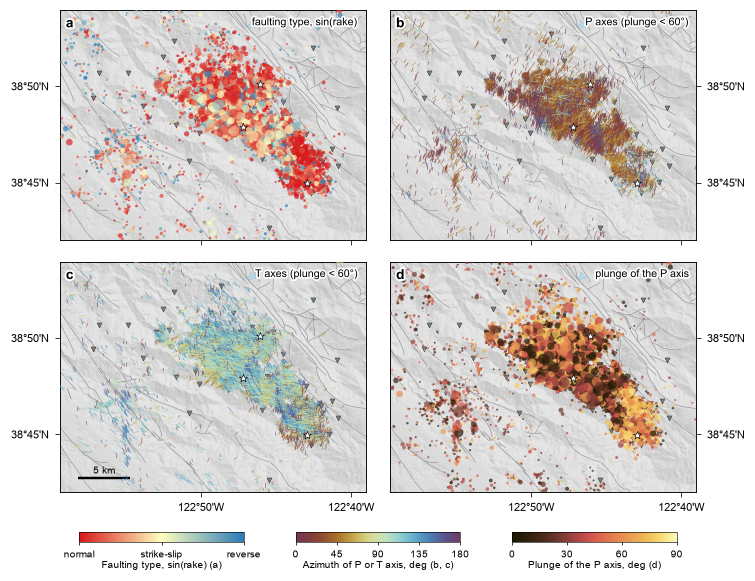

In [63]:
L, site = layers(), sites()
m = good[good.lat.between(*FIELD[2:]) & good.lon.between(*FIELD[:2])].sort_values("mag")

W, GAP, LFT, RGT = 17.0, .55, 1.15, 1.15
WIN = W - LFT - RGT
WP = (WIN - GAP) / 2                       # two panels wide
HP = WP / mercator_ratio(FIELD)            # each panel in the true shape of the field window
H = .3 + 2 * HP + .5 + 1.9
fig = plt.figure(figsize=(W * CM, H * CM))
def panel(x, y, w, h):
    """An axes placed in centimetres from the lower-left corner of the figure."""
    return fig.add_axes([x / W, y / H, w / W, h / H])
top = H - HP - .3
axa = panel(LFT, top, WP, HP);              axb = panel(LFT + WP + GAP, top, WP, HP)
axc = panel(LFT, top - HP - .5, WP, HP);    axd = panel(LFT + WP + GAP, top - HP - .5, WP, HP)

for ax in (axa, axb, axc, axd):
    basemap(ax, L, FIELD, fault_lw=.35)
    ax.scatter(site.lon, site.lat, s=11, marker="v", c="#7a7a7a", ec="black", lw=.2, zorder=2)
    for plant_lon, plant_lat in L["plants"]:
        ax.scatter(plant_lon, plant_lat, s=30, marker="*", c="white", ec="black", lw=.4, zorder=6)

lon_span_km = (FIELD[1] - FIELD[0]) * KM_LON
sc_a = axa.scatter(m.lon, m.lat, s=mag_size(m.mag) * 2.2, c=m.faulting_index, cmap=FAULT_CMAP,
                   vmin=-1, vmax=1, lw=0, alpha=.7, zorder=3, rasterized=True)
lc_b, n_p = axis_bars(axb, m, m.p_az.values, m.p_pl.values, lon_span_km, WP)
lc_c, n_t = axis_bars(axc, m, m.t_az.values, m.t_pl.values, lon_span_km, WP)
sc_d = axd.scatter(m.lon, m.lat, s=mag_size(m.mag) * 2.2, c=m.p_pl, cmap=PLUNGE_CMAP,
                   vmin=0, vmax=90, lw=0, alpha=.7, zorder=3, rasterized=True)

for ax, right in ((axa, False), (axb, True), (axc, False), (axd, True)):
    degree_minute_ticks(ax, .1666667, .0833333, right=right)
for ax in (axa, axb):
    ax.tick_params(labelbottom=False)
scale_bar(axc, 5)

# each panel states what it shows: at a glance the four are otherwise indistinguishable
for ax, note in ((axa, "faulting type, sin(rake)"), (axb, f"P axes (plunge < {PLUNGE_MAX:.0f}°)"),
                 (axc, f"T axes (plunge < {PLUNGE_MAX:.0f}°)"), (axd, "plunge of the P axis")):
    ax.text(.98, .97, note, transform=ax.transAxes, fontsize=7, va="top", ha="right",
            path_effects=[pe.withStroke(linewidth=2.2, foreground="white")])
for k, ax in enumerate((axa, axb, axc, axd)):
    ax.text(.02, .97, "abcd"[k], transform=ax.transAxes, fontsize=9, fontweight="bold", va="top",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

for x, mappable, lab, ticks, labels in (
        (.16, sc_a, "Faulting type, sin(rake) (a)", [-1, 0, 1], ["normal", "strike-slip", "reverse"]),
        (.50, lc_b, "Azimuth of P or T axis, deg (b, c)", [0, 45, 90, 135, 180], None),
        (.84, sc_d, "Plunge of the P axis, deg (d)", [0, 30, 60, 90], None)):
    cax = fig.add_axes([(LFT + WIN * x - 1.9) / W, .75 / H, 3.8 / W, .24 / H])
    cb = fig.colorbar(mappable, cax=cax, orientation="horizontal", ticks=ticks)
    if labels:
        cb.ax.set_xticklabels(labels)
    cb.set_label(lab, fontsize=6.3, labelpad=1)
    cb.ax.tick_params(labelsize=6.3, length=2)
    cb.outline.set_linewidth(.4)
    if getattr(cb, "solids", None) is not None:
        cb.solids.set_alpha(1)

print(f"{len(m):,} quality mechanisms in the field window")
print(f"axes drawn as bars (plunge < {PLUNGE_MAX:.0f} deg): {n_p:,} P, {n_t:,} T")
print("faulting type:", good["faulting"].value_counts(normalize=True).round(3).to_dict())
plt.show()


**Figure 12. First-motion mechanisms of the field window, four views.** (a) Every quality
mechanism as a dot coloured by faulting type; (b) P axes and (c) T axes plunging less than 60°,
drawn as bars along their azimuth with length scaled by magnitude and colour by azimuth on a
cyclic scale; (d) the plunge of the P axis. Shaded relief, Quaternary faults, stations and power
plants are shown in grey behind, as in Figure 5.

The faulting style is mixed, with normal mechanisms the largest single class. That is what a
depleting and cooling reservoir would be expected to produce, and it is not what the regional
strike-slip tectonics alone would give: § 1.1 established that the three fault systems crossing the
region are strike-slip, and panels (a) and (d) show that the field itself is not. The mixture is
the observation on which the published stress inversions for this field rest, and one of the
project questions in `docs/project.md` asks whether it changes with injection.

One caution before those proportions are quoted. A mechanism constrained by ten first motions is
poorly constrained, and the proportions move with the quality cut. They should be recomputed at
`nfm >= 20` before any difference between periods or places is treated as real.


### 8.5 · Summed double couples

Individual mechanisms are noisy, and a map of forty-six thousand of them displays their scatter as
readily as their pattern. A standard remedy is to sum them. Each mechanism is converted to the
**moment tensor** of a unit double couple, the tensors of all mechanisms within a spatial cell are
added, and the best-fitting double couple of the sum is extracted and drawn as a single beachball
for that cell.

The summation also yields a **coherence**: the ratio of the norm of the summed tensor to the sum of
the norms of its parts. A cell whose mechanisms all agree gives a coherence near one; a cell whose
mechanisms point in every direction gives a coherence near zero, and its average beachball means
very little. Reporting the coherence alongside the beachball is what distinguishes a summary from
an artefact.


cells: 94 of 3 km in the region, 114 of 1 km in the field, 145 of 1 x 0.5 km on the section
coherence of the summed double couple: min 0.30, median 0.46, max 0.86


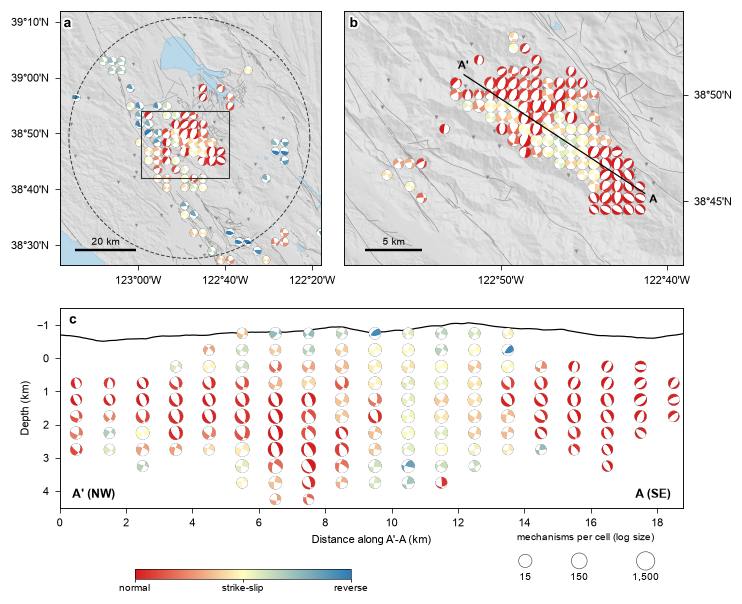

In [64]:
cat = catalog()
in_field = cat.latitude.between(*FIELD[2:]) & cat.longitude.between(*FIELD[:2])
A, A2, evec, LEN = section_line(cat[in_field])       # the same profile as Figure 5
Z0, Z1 = -1.5, 4.5

# Cells in three frames: 3 km over the region, 1 km over the field, 1 x 0.5 km on the section.
# The minimum count per cell rises where the cells are smaller, so that a drawn beachball always
# summarises enough mechanisms to mean something.
gx, gy = (good.lon - CENTER[1]) * KM_LON, (good.lat - CENTER[0]) * KM_LAT
reg = cell_mechanisms(good, gx, gy, 3.0, 3.0, 12)

fld = good[good.lat.between(*FIELD[2:]) & good.lon.between(*FIELD[:2])]
fx, fy = (fld.lon - CENTER[1]) * KM_LON, (fld.lat - CENTER[0]) * KM_LAT
fcells = cell_mechanisms(fld, fx, fy, 1.0, 1.0, 15)

dx, dy = (fld.lon - A[0]) * KM_LON, (fld.lat - A[1]) * KM_LAT
sec = fld.assign(along=LEN - (dx * evec[0] + dy * evec[1]), across=-dx * evec[1] + dy * evec[0])
sec = sec[sec.along.between(0, LEN) & (sec.across.abs() <= 6)]
scells = cell_mechanisms(sec, sec.along.values, sec.depth.values, 1.0, 0.5, 15)

TOT, GAPX, LFT, RGT = 17.0, .55, 1.15, 1.45
WIN = TOT - LFT - RGT
WA, WB, HA = two_panels(WIN, GAPX, REGION, FIELD)
HC = WIN * (Z1 - Z0) / LEN
HT = .3 + HA + 1.0 + HC + 2.1
fig = plt.figure(figsize=(TOT * CM, HT * CM))
def panel(x, y, w, h):
    """An axes placed in centimetres from the lower-left corner of the figure."""
    return fig.add_axes([x / TOT, y / HT, w / TOT, h / HT])
axa = panel(LFT, HT - HA - .3, WA, HA)
axb = panel(LFT + WA + GAPX, HT - HA - .3, WB, HA)
axc = panel(LFT, 2.1, WIN, HC)

# (a) the study region in 3 km cells
basemap(axa, L, REGION, fault_lw=.25)
axa.plot(site.lon, site.lat, "v", ms=2.2, mfc="#8c8c8c", mec="none", zorder=3)
theta = np.linspace(0, 2 * np.pi, 200)
axa.plot(CENTER[1] + RADIUS_KM / KM_LON * np.cos(theta),
         CENTER[0] + RADIUS_KM / KM_LAT * np.sin(theta),
         color="#333333", lw=.6, ls=(0, (4, 2)), zorder=6)
axa.plot([FIELD[0], FIELD[1], FIELD[1], FIELD[0], FIELD[0]],
         [FIELD[2], FIELD[2], FIELD[3], FIELD[3], FIELD[2]], color="#333333", lw=.7, zorder=6)
reg = reg.assign(lon=CENTER[1] + reg.x / KM_LON, lat=CENTER[0] + reg.y / KM_LAT)
beachballs(axa, reg, "lon", "lat", 3.9)
degree_minute_ticks(axa, .3333333, .1666667); scale_bar(axa, 20)

# (b) the field in 1 km cells
basemap(axb, L, FIELD, fault_lw=.35)
axb.plot(site.lon, site.lat, "v", ms=2.6, mfc="#8c8c8c", mec="none", zorder=3)
fcells = fcells.assign(lon=CENTER[1] + fcells.x / KM_LON, lat=CENTER[0] + fcells.y / KM_LAT)
beachballs(axb, fcells, "lon", "lat", 1.18)
axb.plot([A[0], A2[0]], [A[1], A2[1]], color="black", lw=.8, zorder=6)
axb.annotate("A'", (A2[0], A2[1]), xytext=(-4, 4), textcoords="offset points",
             fontsize=7, fontweight="bold", zorder=7)
axb.annotate("A", (A[0], A[1]), xytext=(3, -6), textcoords="offset points",
             fontsize=7, fontweight="bold", zorder=7)
degree_minute_ticks(axb, .1666667, .0833333, right=True); scale_bar(axb, 5)

# (c) the section: the beachballs are map-view projections placed at the cell's position
tt, zs = ground_profile(L, A2[0], A2[1], -evec[0], -evec[1], LEN)
axc.plot(tt, -zs, color="black", lw=.8)
beachballs(axc, scells, "x", "y", .45, in_km=True)
axc.set(xlim=(0, LEN), ylim=(Z1, Z0), xlabel="Distance along A'-A (km)", ylabel="Depth (km)",
        xticks=np.arange(0, LEN + .1, 2), yticks=np.arange(-1, 4.6, 1))
axc.text(.02, .05, "A' (NW)", transform=axc.transAxes, fontsize=8, fontweight="bold")
axc.text(.98, .05, "A (SE)", transform=axc.transAxes, fontsize=8, fontweight="bold", ha="right")
for k, ax in enumerate((axa, axb, axc)):
    ax.text(.015, .975, "abc"[k], transform=ax.transAxes, fontsize=9, fontweight="bold", va="top",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

# the size scale, which the figure would otherwise leave unexplained: three cells of the section
# panel drawn at the sizes its own formula gives them
sax = fig.add_axes([(LFT + WIN * .70) / TOT, .18 / HT, 4.6 / TOT, 1.15 / HT])
sax.set_axis_off(); sax.set(xlim=(0, 4.6), ylim=(-.6, .6)); sax.set_aspect(1)
nmax = scells.n.max()
for xk, nk in zip((.6, 1.9, 3.5), (15, 150, 1500)):
    wk = .45 * (.55 + .45 * np.log10(min(nk, nmax)) / np.log10(nmax))
    sax.add_patch(Ellipse((xk, .12), wk, wk, facecolor="white", edgecolor="#444444", lw=.4))
    sax.text(xk, -.34, f"{nk:,}", ha="center", fontsize=6.5)
sax.text(2.05, .62, "mechanisms per cell (log size)", ha="center", fontsize=6.5)

cax = fig.add_axes([(LFT + WIN * .12) / TOT, .45 / HT, 5.0 / TOT, .24 / HT])
cb = fig.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(-1, 1),
                                               cmap=FAULT_CMAP), cax=cax,
                  orientation="horizontal", ticks=[-1, 0, 1])
cb.ax.set_xticklabels(["normal", "strike-slip", "reverse"], fontsize=6.5)
cb.ax.tick_params(length=2, pad=1); cb.outline.set_linewidth(.4)

print(f"cells: {len(reg)} of 3 km in the region, {len(fcells)} of 1 km in the field, "
      f"{len(scells)} of 1 x 0.5 km on the section")
print("coherence of the summed double couple: min %.2f, median %.2f, max %.2f"
      % (fcells.coherence.min(), fcells.coherence.median(), fcells.coherence.max()))
plt.show()


**Figure 13. Representative mechanisms, summed as unit double couples in cells.** Each beachball is
the best double couple of the summed tensor of the mechanisms in one cell, sized by the number
summed on a logarithmic scale and with its compressional quadrants coloured by faulting type on
the scale of Figure 12. (a) The study region in 3 km cells containing at least 12 mechanisms;
(b) the field in 1 km cells containing at least 15; (c) the section of Figure 5, in cells of
1 × 0.5 km containing at least 15, for mechanisms within 6 km of the line. The beachballs in (c)
are map-view projections placed at the position of their cell.

The pattern is coherent and it is depth-dependent. Normal faulting on northwest-striking planes
occupies the reservoir interval along the whole length of the field, which is the observation
§ 1.1 used to argue that the seismicity delineates the producing interval rather than merely
occurring near it. The shallowest cells and the southeastern end of the field are strike-slip, and
the Maacama and Rodgers Creek zones in panel (a) are strike-slip throughout, as § 1.1 would
require. The transition between the two regimes within a single field is the reason the stress
state here is described as transtensional.


#### Sources

* Northern California Earthquake Data Center (2014). *Northern California Earthquake Data Center*.
  UC Berkeley Seismological Laboratory. Dataset. `10.7932/NCEDC` — the first-motion solutions of
  the Northern California Seismic Network, distributed with this course as
  `geysers_mechanisms_1975-2026.csv.gz`, together with the polarity check of § 8.2 and the
  waveforms it uses. The orientation convention of the `.mech` format is documented at
  `ncedc.org/pub/doc/cat5/ncsn.mech.txt` and is the subject of § 8.1.


## § 9 · Frequency–magnitude statistics

*This section establishes the two numbers that summarise a catalogue's magnitude distribution: the
magnitude above which it is complete, and the slope of the distribution above that magnitude, each
computed on the subset defined in § 4 and each reported with the uncertainty it actually warrants.*

### 9.1 · The Gutenberg–Richter relation

Earthquake magnitudes are not distributed arbitrarily. Above some threshold, the number *N* of
events with magnitude at least *M* falls off as

> log₁₀ *N* = *a* − *b* · *M*

which is the **Gutenberg–Richter relation**. Since magnitude is itself logarithmic, this states
that the sizes of earthquakes follow a power law: there is no characteristic earthquake size, and
each unit decrease in magnitude multiplies the number of events by 10^*b*.

Two quantities emerge, and they are not of equal interest. The parameter *a* measures the total
rate of seismicity and depends on the volume and interval considered. The **b-value** is the slope,
and it describes the relative proportion of small events to large ones. A *b*-value near 1 is
typical of tectonic seismicity, and values above it indicate a population weighted more heavily
towards small events, which has been associated with swarms and with fluid-driven seismicity.
Changes in *b* — between periods, between places, or with injection — are what the literature on
induced seismicity argues about, and § 9.5 shows why such comparisons are difficult to make
honestly.

Neither can be estimated without first establishing the **magnitude of completeness**, *M*c: the
magnitude above which the catalogue may be assumed to contain every event that occurred. Below it
the catalogue undercounts, not because fewer earthquakes happened but because the network did not
detect them, and § 4.7 showed that threshold moving over the record. *M*c is therefore a nuisance
parameter — of no interest in itself, but one that must be estimated correctly before anything
else can be.

This section stops at the numbers. **The regression itself is the subject of the regression session**,
where the same fit is performed with its uncertainty and its residuals examined properly.


### 9.2 · The subset defined in § 4

Section 4.8 wrote `my_catalog.csv`. If the criteria there were changed, the numbers below are
specific to that choice and will not reproduce anyone else's, which is the intended behaviour: the
selection is part of the result and is reported with it.


In [65]:
import numpy as np
import pandas as pd

mine = pd.read_csv("my_catalog.csv")
mine["time"] = pd.to_datetime(mine.time, format="mixed", utc=True)
mine["year"] = mine.time.dt.year

print(f"{len(mine):,} events, {mine.time.min():%Y-%m} to {mine.time.max():%Y-%m}, "
      f"M {mine.mag.min():.2f} to {mine.mag.max():.2f}")


259,267 events, 1972-04 to 2025-12, M -0.81 to 5.01


### 9.3 · Three estimators, defined once

The whole of this section rests on three short functions, which are therefore written out rather
than imported.

**The b-value** is estimated by maximum likelihood rather than by fitting a line to the cumulative
distribution. The cumulative counts are strongly correlated between adjacent magnitudes — each
event enters every bin below it — so a least-squares fit to them violates its own assumptions and
gives a misleadingly small uncertainty. Aki's estimator uses the mean magnitude above the cut
directly, and its standard error is *b*/√*n*.

**Maximum curvature** estimates *M*c as the magnitude bin containing the most events — the peak of
the non-cumulative distribution — plus a correction, conventionally 0.2. It is fast, and it
under-estimates *M*c where the roll-off below completeness is gradual rather than abrupt.

**Goodness of fit** estimates *M*c by fitting Gutenberg–Richter above each candidate value and
taking the lowest candidate whose synthetic distribution reproduces the observed counts to within
a stated percentage, here 90 per cent. It is the more conservative of the two *M*c estimators
and requires more events.


In [66]:
DM = 0.1                       # the magnitude bin used by the estimators below


def b_value(mags, mc, dm=0.0, nmin=50):
    """Aki's maximum-likelihood b-value above `mc`, with Utsu's binning correction if `dm` > 0.

    Returns (b, standard error, n). The correction subtracts half a bin from the cut, and is
    appropriate only if the magnitudes really were rounded to a bin of that width -- see § 9.4.
    """
    x = np.asarray(pd.Series(mags).dropna())
    x = x[x >= mc - 1e-9]
    if len(x) < nmin:
        return np.nan, np.nan, len(x)
    b = np.log10(np.e) / (x.mean() - (mc - dm / 2))
    return b, b / np.sqrt(len(x)), len(x)


def mc_maxc(m, bump=0.2):
    """Magnitude of completeness by maximum curvature: the modal bin, plus a fixed correction."""
    m = np.round(pd.Series(m).dropna(), 1)
    if len(m) < 200:
        return np.nan
    v, c = np.unique(m, return_counts=True)
    return v[c.argmax()] + bump


def mc_gft(m, level=90):
    """Magnitude of completeness by goodness of fit: the lowest cut explaining `level` per cent."""
    best = (np.nan, -np.inf)
    for mc in np.round(np.arange(-0.5, 3.01, DM), 1):
        b, _, n = b_value(m, mc, DM)
        if n < 50:
            break
        e = np.round(np.arange(mc - DM / 2, np.max(m) + DM, DM), 3)
        obs = np.histogram(m, bins=e)[0][::-1].cumsum()[::-1]
        pred = 10 ** (np.log10(n) + b * mc - b * (e[:-1] + DM / 2))
        r = 100 - 100 * np.abs(obs - pred).sum() / obs.sum()
        if r >= level:
            return mc
        if r > best[1]:
            best = (mc, r)
    return best[0]


print(f"maximum curvature   Mc = {mc_maxc(mine.mag.values):.1f}")
print(f"goodness of fit 90% Mc = {mc_gft(np.round(mine.mag.values / DM) * DM):.1f}")


maximum curvature   Mc = 1.0
goodness of fit 90% Mc = 0.8


The two estimators need not agree, and where they disagree the disagreement is itself the result.
**The magnitude of completeness is a range rather than a number**, and both estimates should be
reported and the difference between them carried into whatever is concluded.


### 9.4 · A correction applied to data that were never binned

Utsu's correction replaces the cut *M*c by *M*c − Δ*M*/2 to account for magnitudes having been
**rounded to a bin** of width Δ*M*. It is a standard part of the estimator and is applied almost
automatically. It is correct only if the rounding actually took place, and whether it did is a
property of the catalogue that can be checked directly.


In [67]:
all_mags = mine.mag.values
n_distinct = len(np.unique(np.round(all_mags, 2)))
on_grid = np.mean(np.abs(all_mags * 10 - np.round(all_mags * 10)) < 1e-6)
print(f"{n_distinct} distinct magnitude values in the cut; "
      f"{100 * on_grid:.1f} % of them sit on a 0.1 grid")

sel = mine[mine.mag >= 1.2].mag.values
b_raw, se_raw, n = b_value(sel, 1.2)
b_corr = b_value(sel, 1.2, dm=0.1)[0]

print(f"\nabove M 1.2, n = {n:,}")
print(f"  no correction, as the data warrant   b = {b_raw:.3f} +- {se_raw:.3f}")
print(f"  Utsu correction applied anyway       b = {b_corr:.3f}")
print(f"  difference                             {b_raw - b_corr:+.3f}")


492 distinct magnitude values in the cut; 9.0 % of them sit on a 0.1 grid

above M 1.2, n = 69,817
  no correction, as the data warrant   b = 1.000 +- 0.004
  Utsu correction applied anyway       b = 0.897
  difference                             +0.103


The NCEDC reports magnitudes to two decimal places. The count of distinct values establishes this,
and only a small fraction of them fall on a 0.1 grid, so these magnitudes are not binned and
Utsu's term does not apply to them. Applying it regardless subtracts half a bin that was never
there, and the cost is approximately 0.1 in *b* — **larger than most of the differences the
literature argues over**.

The rule is therefore to **bin first and then correct, or to do neither, but not to correct data
that have not been binned.** The figure below takes the first route, rounding the magnitudes to
the bin before estimating, which is why its numbers are internally consistent while those above
are a demonstration of what the alternative costs.

Two further cautions must be carried rather than concealed.

**The standard error *b*/√*n* assumes independent draws from an exponential distribution.**
Aftershocks and swarms are not independent, and the seismicity of this field is almost entirely
swarms, so the true interval is wider than the formula gives. The quantity should be treated as a
lower bound on the uncertainty.

**The magnitudes being fitted are the mixture of scales identified in §§ 4.5 and 7.6.** Coda
duration below approximately magnitude 3, local and moment magnitude above it. A slope fitted
across that range crosses a change of scale, and part of any curvature apparent near magnitude 3
is the join between the scales rather than a property of the seismicity.


### 9.5 · The distribution, in space and through time

The figure below assembles four views of the same field-window catalogue: the frequency–magnitude
distribution for two periods, the distribution year by year with both *M*c estimators drawn over
it, the *b*-value by year with its interval, and the *b*-value mapped over the field.


1969-2026: Mc maxc+0.2 1.1, GFT90 0.8; b = 1.062 +- 0.003 (n = 95,494)
2012-2026: Mc maxc+0.2 0.8, GFT90 0.6; b = 1.108 +- 0.007 (n = 28,216)
b map: 167 nodes, b 0.84-1.53; yearly Mc since 1981 0.6-1.4


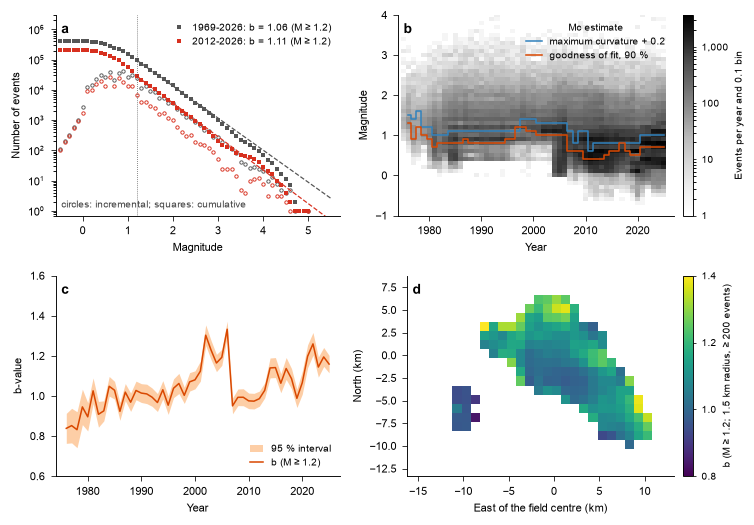

In [68]:
from scipy.spatial import cKDTree

cat = catalog()
field = cat[cat.latitude.between(*FIELD[2:]) & cat.longitude.between(*FIELD[:2])].copy()
field = field.assign(m=np.round(field.mag / DM) * DM)      # bin first, then correct
cut = 1.2
BG = pd.Timestamp("2012-03-16", tz="UTC")                  # the borehole network, from § 3.4
periods = ((field, "#555555", "1969-2026"), (field[field.time >= BG], "#d7301f", "2012-2026"))

W, H = 17.0, 11.8
fig = plt.figure(figsize=(W * CM, H * CM))
gs = fig.add_gridspec(2, 2, left=1.2 / W, right=1 - 1.0 / W, top=1 - .25 / H, bottom=.9 / H,
                      wspace=.2, hspace=.3, width_ratios=[1, 1.05])
a = fig.add_subplot(gs[0, 0]); heat = fig.add_subplot(gs[0, 1])
byyr = fig.add_subplot(gs[1, 0]); bmap = fig.add_subplot(gs[1, 1])

# (a) incremental and cumulative distributions for the two periods, with the fitted slope
out = {}
for sel_p, colour, lab in periods:
    mm = sel_p.m.values
    edges = np.arange(-0.55, 5.75, DM)
    h, e = np.histogram(mm, bins=edges); cen = (e[:-1] + e[1:]) / 2
    cum = h[::-1].cumsum()[::-1]
    b, sb, n = b_value(mm, cut, DM)
    out[lab] = dict(b=b, sb=sb, n=n, maxc=mc_maxc(mm), gft=mc_gft(mm))
    a.plot(cen[h > 0], h[h > 0], "o", ms=2.2, mfc="none", mec=colour, mew=.6)
    a.plot(cen[cum > 0], cum[cum > 0], "s", ms=2.2, color=colour, mew=0,
           label=f"{lab}: b = {b:.2f} (M ≥ {cut})")
    xx = np.arange(cut, 5.6, DM)
    a.plot(xx, 10 ** (np.log10(n) - b * (xx - cut)), color=colour, lw=.8, ls="--")
a.set(yscale="log", xlim=(-.6, 5.7), ylim=(.7, 3e6), xlabel="Magnitude", ylabel="Number of events")
a.axvline(cut, color="#444444", lw=.5, ls=":")
a.legend(loc="upper right", frameon=False, fontsize=6.3, handlelength=1.2)
a.text(.02, .04, "circles: incremental; squares: cumulative", transform=a.transAxes,
       fontsize=6.3, color="#444444")

# (b) the distribution year by year, with both Mc estimators over it
yrs = np.arange(1975, int(field.year.max()) + 1)
mbins = np.arange(-1.05, 5.05, DM)
grid = np.array([np.histogram(field[field.year == y].m, bins=mbins)[0] for y in yrs], dtype=float).T
pc = heat.pcolormesh(np.append(yrs - .5, yrs[-1] + .5), mbins, np.where(grid > 0, grid, np.nan),
                     norm=LogNorm(vmin=1, vmax=grid.max()), cmap="Greys", rasterized=True)
rows = []
for y in yrs:
    mm = field[field.year == y].m.values
    if len(mm) < 300:
        continue
    b, sb, n = b_value(mm, cut, DM)
    rows.append(dict(year=y, maxc=mc_maxc(mm), gft=mc_gft(mm), b=b, sb=sb, n=n))
yr = pd.DataFrame(rows).set_index("year")
heat.step(yr.index, yr.maxc, where="mid", color="#3182bd", lw=1, label="maximum curvature + 0.2")
heat.step(yr.index, yr.gft, where="mid", color="#d94801", lw=1, label="goodness of fit, 90 %")
heat.set(ylim=(-1, 4), xlim=(1974, 2027), xlabel="Year", ylabel="Magnitude")
heat.legend(loc="upper right", frameon=False, fontsize=6.3, handlelength=1.6,
            title="Mc estimate", title_fontsize=6.3)
cb = fig.colorbar(pc, ax=heat, fraction=.045, pad=.03, ticks=[1, 10, 100, 1000],
                  format=matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
cb.set_label("Events per year and 0.1 bin", fontsize=6.3); cb.ax.tick_params(labelsize=6.3, length=2)

# (c) the b-value year by year, with a 95 % interval from b/sqrt(n) -- a lower bound, see § 9.4
ok = yr.dropna(subset=["b"])
byyr.fill_between(ok.index, ok.b - 1.96 * ok.sb, ok.b + 1.96 * ok.sb, color="#fdae6b", lw=0,
                  alpha=.6, label="95 % interval")
byyr.plot(ok.index, ok.b, color="#d94801", lw=1, label=f"b (M ≥ {cut})")
byyr.set(ylabel="b-value", ylim=(.6, 1.6), xlim=(1974, 2027), xlabel="Year")
byyr.legend(loc="lower right", frameon=False, fontsize=6.3, handlelength=1.4)

# (d) the b-value on a 1 km grid, estimated within 1.5 km of each node where 200 events allow it
STEP, RAD, NMIN = 1.0, 1.5, 200
x0, x1 = (np.array(FIELD[:2]) - CENTER[1]) * KM_LON
y0, y1 = (np.array(FIELD[2:]) - CENTER[0]) * KM_LAT
sel_b = field[field.m >= cut]
pts = np.column_stack([(sel_b.longitude - CENTER[1]) * KM_LON,
                       (sel_b.latitude - CENTER[0]) * KM_LAT])
tree = cKDTree(pts); mags = sel_b.m.values
xe, ye = np.arange(x0, x1 + STEP, STEP), np.arange(y0, y1 + STEP, STEP)
B = np.full((len(ye) - 1, len(xe) - 1), np.nan)
for i, yy in enumerate((ye[:-1] + ye[1:]) / 2):
    for j, xx in enumerate((xe[:-1] + xe[1:]) / 2):
        idx = tree.query_ball_point([xx, yy], RAD)
        if len(idx) >= NMIN:
            B[i, j] = b_value(mags[idx], cut, DM)[0]
pm = bmap.pcolormesh(xe, ye, np.ma.masked_invalid(B), cmap="viridis", vmin=.8, vmax=1.4,
                     shading="flat", rasterized=True)
bmap.set(xlim=(x0, x1), ylim=(y0, y1), xlabel="East of the field centre (km)", ylabel="North (km)")
bmap.set_aspect("equal")
cb2 = fig.colorbar(pm, ax=bmap, fraction=.045, pad=.03, ticks=[.8, 1., 1.2, 1.4])
cb2.set_label(f"b (M ≥ {cut}; {RAD} km radius, ≥ {NMIN} events)", fontsize=6.3)
cb2.ax.tick_params(labelsize=6.3, length=2)

for k, panel in enumerate((a, heat, byyr, bmap)):
    panel.text(.02, .96, "abcd"[k], transform=panel.transAxes, fontsize=9, fontweight="bold",
               va="top", path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
    for side in ("top", "right"):
        panel.spines[side].set_visible(False)

for k in ("1969-2026", "2012-2026"):
    v = out[k]
    print(f"{k}: Mc maxc+0.2 {v['maxc']:.1f}, GFT90 {v['gft']:.1f}; "
          f"b = {v['b']:.3f} +- {v['sb']:.3f} (n = {v['n']:,})")
print(f"b map: {int(np.isfinite(B).sum())} nodes, b {np.nanmin(B):.2f}-{np.nanmax(B):.2f}; "
      f"yearly Mc since 1981 {yr.loc[1981:].maxc.min():.1f}-{yr.loc[1981:].maxc.max():.1f}")
plt.show()


**Figure 14. Frequency–magnitude statistics of the field window.** (a) Incremental (circles) and
cumulative (squares) magnitude distributions for the whole record and for the period since the
borehole network entered the archive, with the maximum-likelihood slope above M 1.2 as a dashed
line. (b) The magnitude distribution year by year, shaded logarithmically, with both estimates of
*M*c drawn over it. (c) The *b*-value by year, with a 95 per cent interval from *b*/√*n*, which
§ 9.4 argues is a lower bound. (d) The *b*-value on a 1 km grid, estimated from events within
1.5 km of each node wherever at least 200 events allow it.

The *b*-value printed beneath the figure is 1.06 over the whole record and 1.11 since 2012. Both
lie close to the value typical of tectonic seismicity rather than far above it, and the difference
between the two periods is **not** interpretable as a change in the earthquakes: the later period
has a lower magnitude of completeness, a different mixture of magnitude types in the sense of
§ 7.6, and a standard error that § 9.4 argued is a lower bound. The comparison is exactly the kind
the induced-seismicity literature makes, and this is what it takes to make it defensible.

Panel (b) is the one to retain. **The magnitude of completeness is not constant.** It falls as the
network densifies and it steps where the network changes, exactly as § 4.7 predicted from the lower
edge of the magnitude cloud. Any quantity computed with a fixed threshold across the whole record
is computed on a catalogue whose meaning changes beneath it, and any apparent trend in *b* must
survive that objection before it can be reported as a result.


#### Sources and further reading

* Northern California Earthquake Data Center (2014). *Northern California Earthquake Data Center*.
  UC Berkeley Seismological Laboratory. Dataset. `10.7932/NCEDC` — the catalogue from which the
  subset of § 4.8 was cut.
* The maximum-likelihood estimator of § 9.3 is Aki's; the binning correction discussed in § 9.4 is
  Utsu's; the goodness-of-fit estimator of *M*c follows Wiemer and Wyss. The regression session
  treats the estimation problem in full and gives the references for it.


## § 10 · Injection and seismicity

*This section brings the forcing of § 2 together with the catalogue of § 4 and asks what relation
holds between them: the annual correlation, the seasonal component that a trend cannot imitate,
and a null hypothesis against which the seasonal result must be tested.*

### 10.1 · The question, and why it was once answered differently

This is the question for which the field is known, and it is instructive that it was once answered
in the negative. Analysing the first decade of this record, Eberhart-Phillips and Oppenheimer
(1984) reported no consistent pattern of correlation between injection and seismicity. Four
decades and far denser catalogues later the correlation is regarded as established, and the
discussion has moved on to the lag between them and to the mechanism.

**Nothing about the Earth changed in the interval.** The catalogue changed, and § 4.7 and § 9.5
explain how: the completeness magnitude fell as the network densified, so the seismicity available
to be correlated in 1984 was a small and differently selected subset of what is available now. The
episode is a useful caution against reading a null result as a statement about the world when it
may be a statement about the observing system.

Everything computed in this section runs on the subset defined in § 4.8, so the numbers obtained
here will differ from published ones by however much that cut differs from theirs. Where a
published figure is reproduced, it is drawn on the full field-window catalogue so that the two are
comparable.


### 10.2 · Aligning the two series

Two series must be placed on a common monthly grid: the CalGEM field totals of § 2, and monthly
event counts from the catalogue at two magnitude thresholds. The lower threshold, M ≥ 1.2, lies
above the completeness magnitude for most of the record, as § 9.5 established. The higher, M ≥ 2.5,
selects events that the sparser early network could also detect, so that a change in its rate is
not simply a change in detection.


In [69]:
import numpy as np
import pandas as pd


def monthly(prod, cat_field, lo=1.2, hi=2.5):
    """Both series on one monthly grid, truncated where the catalogue ends.

    The production record extends past the catalogue, so the join is cut at the last complete month
    the catalogue covers; otherwise the final points would show a real forcing against an event
    count of zero that means only that the catalogue has not been updated.
    """
    months = pd.date_range(prod.index[0], prod.index[-1] + pd.offsets.MonthBegin(1), freq="MS")
    d = prod[["production", "injection"]].copy()
    d["n"] = np.histogram(cat_field[cat_field.mag >= lo].time.dt.tz_localize(None), bins=months)[0]
    d["n_big"] = np.histogram(cat_field[cat_field.mag >= hi].time.dt.tz_localize(None), bins=months)[0]
    end = (cat_field.time.max().tz_localize(None).to_period("M").to_timestamp()
           - pd.offsets.MonthBegin(1))
    return d.loc[:end], end


mine = pd.read_csv("my_catalog.csv")
mine["time"] = pd.to_datetime(mine.time, format="mixed", utc=True)
prod = production()

d, end = monthly(prod, mine)
print(f"series overlap to {end:%Y-%m}, {len(d)} months")
print(d.tail(4).round(2).to_string())


series overlap to 2025-11, 683 months
            production  injection    n  n_big
2025-08-01        4.45       2.88  186      4
2025-09-01        4.18       3.62  156      1
2025-10-01        4.07       4.03  209      5
2025-11-01        3.72       4.01  204      8


### 10.3 · Annual correlation, and why it proves little

The simplest test is to sum both series by year and correlate them. It is performed separately
against injection and against production, because the two are not interchangeable and the
difference between them carries the argument.


In [70]:
ann = d.resample("YS").sum().loc["1981":"2025"]

for col in ("injection", "production"):
    for n_col, label in (("n", "M >= 1.2"), ("n_big", "M >= 2.5")):
        r = np.corrcoef(ann[col], ann[n_col])[0, 1]
        print(f"  {label:9s} against {col:11s}  r = {r:+.2f}")


  M >= 1.2  against injection    r = +0.84
  M >= 2.5  against injection    r = +0.50
  M >= 1.2  against production   r = -0.40
  M >= 2.5  against production   r = +0.35


Small events follow the water; larger ones do not, and if anything follow the steam. The second
correlation is a **confound rather than a mechanism**: the largest events were most frequent around
the production maximum of 1987, so production and calendar time are entangled over this record and
either can stand in for the other.

The more important objection applies to both. **Two trending series correlate whatever the physics
may be.** Injection rises across this record and so does the event count, in part for the reason
given in § 10.1, so a positive correlation coefficient on annual totals is close to unavoidable and
constitutes weak evidence on its own. Nothing in the numbers above distinguishes a causal relation
from two independent processes that both increase with time.


### 10.4 · The annual cycle, which a trend cannot imitate

The stronger evidence is periodic rather than monotonic. Section 2.5 measured the seasonal
component of the forcing: injection swings by roughly a third about its running mean, from
approximately −32 per cent in August to +35 per cent in January, while production varies by less
than a tenth. **A monotonic trend cannot manufacture a twelve-month period.** If the seismicity
rate carries the same period, with a physically plausible lag, that is evidence of a different
kind from the correlation of two rising lines.

The figure below assembles the argument: the forcing at monthly resolution, the annual correlation
of § 10.3 as a scatter, and the mean annual cycle of all four series expressed as a deviation from
a running mean, so that the trend is removed and the seasonal component alone remains.


published cut: annual M>=1.2 against injection r = +0.72, against production r = -0.03
              1     2     3     4    5     6     7     8     9     10   11    12
injection   37.0  26.0  30.0   9.0 -7.0 -20.0 -31.0 -32.0 -27.0 -10.0  3.0  27.0
production   0.0  -8.0   1.0  -3.0  1.0  -1.0   6.0   7.0   0.0  -1.0 -4.0   0.0
n           10.0  -0.0  20.0   8.0  1.0  -5.0  -8.0 -11.0 -20.0  -1.0 -2.0   8.0
n_big        5.0  -3.0  35.0  21.0  3.0   1.0 -22.0 -25.0 -15.0   8.0 -9.0   5.0


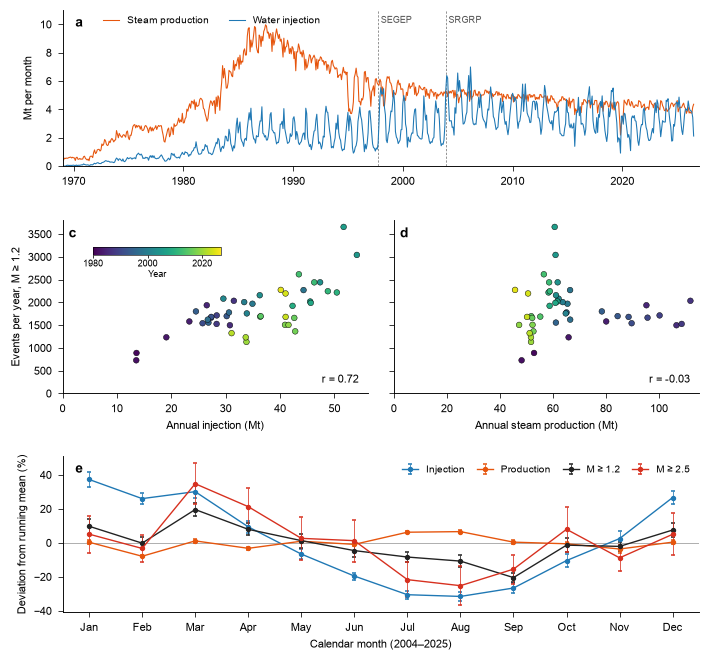

In [71]:
C_PROD, C_INJ, C_N12, C_N25 = "#e6550d", "#1f78b4", "#222222", "#d7301f"
PIPES = (("1997-10-01", "SEGEP"), ("2003-12-01", "SRGRP"))

# The published figure is drawn on the project's own cut -- every earthquake in the field window --
# so that it is comparable with the published version; the numbers above are on the § 4.8 subset.
cat = catalog()
in_field = cat.latitude.between(*FIELD[2:]) & cat.longitude.between(*FIELD[:2])
d_pub, end_pub = monthly(prod, cat[in_field])

ann_pub = d_pub.resample("YS").sum().loc["1981":"2025"]
rel = d_pub.loc["2003":"2026"].copy()
for c in ("production", "injection", "n", "n_big"):
    rel[c] = 100 * (rel[c] / rel[c].rolling(13, center=True).mean() - 1)
rel = rel.loc["2004":"2025"]
season, sem = rel.groupby(rel.index.month).mean(), rel.groupby(rel.index.month).sem()

# Three rows. The inter-row gaps must accommodate the x-label of the row above and the title space
# of the row below; at 0.95 cm the (c, d) x-labels were being overrun by panel (e).
W, H = 17.0, 15.4
fig = plt.figure(figsize=(W * CM, H * CM))
def panel(x, y, w, h):
    """An axes placed in centimetres from the lower-left corner of the figure."""
    return fig.add_axes([x / W, y / H, w / W, h / H])
L, RW = 1.25, W - 2.3
HA, HC, HE = 3.6, 4.0, 3.6
ye = 1.05; yc = ye + HE + 1.45; ya = yc + HC + 1.25
axa = panel(L, ya, RW, HA)
wc = (RW - .6) / 2
axc = panel(L, yc, wc, HC); axd = panel(L + wc + .6, yc, wc, HC); axd.sharey(axc)
axe = panel(L, ye, RW, HE)

# (a) the forcing at monthly resolution, as in Figure 2, with the two pipelines marked
axa.plot(prod.index, prod.production, color=C_PROD, lw=.7, label="Steam production")
axa.plot(prod.index, prod.injection, color=C_INJ, lw=.7, label="Water injection")
for date, name in PIPES:
    axa.axvline(pd.Timestamp(date), color="#777777", lw=.5, ls=(0, (3, 2)), zorder=0)
    axa.text(pd.Timestamp(date) + pd.Timedelta(days=90), 10.6, name, fontsize=6,
             color="#555555", va="top")
axa.set(ylabel="Mt per month", ylim=(0, 11),
        xlim=(pd.Timestamp("1969-01-01"), pd.Timestamp("2027-01-01")))
axa.legend(loc="upper left", bbox_to_anchor=(.05, 1.02), frameon=False, fontsize=6.5,
           ncol=2, handlelength=1.6)

# (c, d) annual event count against annual forcing, coloured by year so the trend is visible
norm = matplotlib.colors.Normalize(1980, 2027)
for ax, col, lab in ((axc, "injection", "Annual injection (Mt)"),
                     (axd, "production", "Annual steam production (Mt)")):
    sc = ax.scatter(ann_pub[col], ann_pub.n, c=ann_pub.index.year, cmap="viridis", norm=norm, s=14,
                    ec="black", lw=.3, zorder=3)
    ax.set(xlabel=lab, xlim=(0, None), ylim=(0, None))
    ax.text(.97, .05, f"r = {np.corrcoef(ann_pub[col], ann_pub.n)[0, 1]:.2f}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=7)
axc.set_ylabel("Events per year, M ≥ 1.2"); axd.tick_params(labelleft=False)
cax = axc.inset_axes([.10, .80, .42, .045])
cb = fig.colorbar(sc, cax=cax, orientation="horizontal", ticks=[1980, 2000, 2020])
cb.ax.tick_params(labelsize=6, length=2, pad=1); cb.outline.set_linewidth(.4)
cb.set_label("Year", fontsize=6, labelpad=1)

# (e) the mean annual cycle of all four series, as a deviation from a 13-month running mean
mo = np.arange(1, 13)
for c, colour, lab in (("injection", C_INJ, "Injection"), ("production", C_PROD, "Production"),
                       ("n", C_N12, "M ≥ 1.2"), ("n_big", C_N25, "M ≥ 2.5")):
    axe.errorbar(mo, season[c], yerr=sem[c], color=colour, lw=.9, marker="o", ms=2.5, capsize=1.5,
                 elinewidth=.5, label=lab)
axe.axhline(0, color="#999999", lw=.5, zorder=0)
axe.set(xticks=mo, xticklabels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep",
                                "Oct", "Nov", "Dec"], xlim=(.5, 12.5),
        xlabel="Calendar month (2004–2025)", ylabel="Deviation from running mean (%)")
axe.legend(loc="upper right", frameon=False, fontsize=6.5, ncol=4, handlelength=1.6,
           columnspacing=1.2)

for k, ax in enumerate((axa, axc, axd, axe)):
    ax.text(.02, .96, "acde"[k], transform=ax.transAxes, fontsize=9, fontweight="bold", va="top",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

print(f"published cut: annual M>=1.2 against injection "
      f"r = {np.corrcoef(ann_pub.injection, ann_pub.n)[0, 1]:+.2f}, "
      f"against production r = {np.corrcoef(ann_pub.production, ann_pub.n)[0, 1]:+.2f}")
print(season[["injection", "production", "n", "n_big"]].round(0).T.to_string())
plt.show()


**Figure 15. Steam production and water injection against the seismicity.** (a) Monthly field
totals, with the two wastewater pipelines marked as in Figure 2. (c, d) Annual event count at
M ≥ 1.2 against annual injection and against annual steam production, each point one year and
coloured by year. (e) The mean annual cycle of all four series over 2004–2025, expressed as a
percentage deviation from a thirteen-month centred running mean, with standard errors. Panels
(c)–(e) are computed on every earthquake in the field window rather than on the § 4.8 subset.

Panel (e) is the substance of the argument. Injection peaks in winter and the seismicity rate
follows it with a lag of one to two months, while production, which varies by less than a tenth
over the same cycle, does not. The seasonal signal is present at both magnitude thresholds, so it
is not an artefact of detection at the smallest magnitudes.

The correlation coefficient printed beneath the figure should be compared with the one computed in
§ 10.3 on the § 4.8 subset. Where the two differ appreciably, the difference is the price of the
selection decisions made in § 4.8 — neither noise nor error. **A result that moves when a
defensible cut is changed is a result that must be reported with its cut attached.**


### 10.5 · A null hypothesis for the annual cycle

A seasonal amplitude is a number, and a number alone establishes nothing. The question is whether
it is larger than the same statistic computed on data in which the seasonal structure has been
destroyed and everything else preserved. That comparison is the purpose of a **null hypothesis**,
and constructing one correctly is the transferable skill of this section.

Two nulls are computed below, and the difference between them is the point.

The first **permutes the month labels** of the monthly counts. It retains every count, and
therefore the overall rate, while destroying the association between a count and the month in
which it occurred.

The second **rotates each calendar year** by an independent random number of months. It destroys
the same association, but it additionally preserves the fact that neighbouring months resemble one
another.


In [72]:
rng = np.random.default_rng(0)
m = d[d.index.year >= 2004].copy()
m["month"] = m.index.month


def amplitude(counts, months):
    """Peak-to-trough range of the mean monthly count: the statistic being tested."""
    mean = pd.Series(counts).groupby(months).mean()
    return mean.max() - mean.min()


real = amplitude(m.n.values, m.month.values)
shuffled = np.array([amplitude(m.n.values, rng.permutation(m.month.values)) for _ in range(2000)])


def rotated_years(counts, months, years):
    """Roll each calendar year's months by an independent random offset.

    This preserves the total of each year and the correlation between neighbouring months, and
    randomises only the phase of the annual cycle -- which is the structure under test.
    """
    out = counts.copy()
    for y in np.unique(years):
        k = years == y
        out[k] = np.roll(counts[k], rng.integers(12))
    return amplitude(out, months)


blocked = np.array([rotated_years(m.n.values, m.month.values, m.index.year.values)
                    for _ in range(2000)])

print(f"seasonal peak-to-trough, M >= 1.2 since 2004: {real:.1f} events per month\n")
for name, null in (("month shuffle ", shuffled), ("year rotation ", blocked)):
    print(f"  {name} median {np.median(null):5.1f}, 95th pct {np.percentile(null, 95):5.1f}, "
          f"p = {(null >= real).mean():.3f}")


seasonal peak-to-trough, M >= 1.2 since 2004: 58.8 events per month

  month shuffle  median  36.9, 95th pct  52.6, p = 0.018
  year rotation  median  21.5, 95th pct  32.0, p = 0.000


The two nulls give materially different answers, and the direction of the difference is not the
one intuition suggests.

The month permutation produces the **wider** null, with a median amplitude of about 37 events per
month against 21 for the year rotation, and it therefore reports the **weaker** result. The reason
is that permuting month labels across the whole series mixes months drawn from years whose overall
rates differ by large factors. The monthly means of a permuted series consequently inherit that
between-year variation in rate, which appears in the statistic as seasonal amplitude although none
of it is seasonal. The null is inflated by a structure that has nothing to do with the hypothesis
being tested, and it is correspondingly harder to exceed.

Rotating each year by an independent offset removes exactly that contamination. Each year keeps its
own total and its own internal shape, and only the phase of its annual cycle is randomised. Against
this null no draw in two thousand reaches the observed amplitude.

The seasonal signal is therefore stronger, not weaker, once the null is constructed correctly. The
general lesson is the transferable one, and it runs in both directions: **a null must destroy the
structure under test and preserve everything else**. A null that destroys too little leaves the
result untested; one that destroys too much, as the month permutation does here, manufactures
variability that the hypothesis is then required to beat. Where it is cheap to do so, report more
than one and say which is appropriate.


### 10.6 · What remains open

The association between injection and seismicity at The Geysers is widely accepted, and the
analysis here supports it in the specific and limited sense that the seismicity rate carries an
annual cycle which no year-rotation of the same data reproduces. That is a statement about timing
and not about mechanism: it establishes that the two series share a period, not that the water
causes the earthquakes, and § 10.3 has already shown that the annual correlation on which such
claims are frequently based carries very little weight on its own. Several questions therefore
remain open, and the project questions set out in `docs/project.md`
are built on them: the **lag** between forcing and response, and whether it varies with depth as a
diffusive mechanism would require; whether the response can be **forecast** better than by
persistence; whether the *b*-value of § 9 changes with injection at a resolution the data actually
support; and why the analysis of 1984 saw nothing. The last of these is a question about detection
rather than about the Earth, and §§ 4 and 9 have supplied the means to answer it.

Two limitations established earlier bound all of this. Section 2.6 showed that the forcing record
is field-wide and monthly, so no question about an individual well or about a process faster than a
month can be posed. Section 4.8 showed that a criterion applied uniformly does not produce a
uniform subset, so any trend measured here is in part a trend in the selection.


#### Sources and further reading

* California Geologic Energy Management Division (CalGEM), California Department of Conservation.
  Monthly geothermal production and injection reports for The Geysers field; see § 2.2.
* Northern California Earthquake Data Center (2014). *Northern California Earthquake Data Center*.
  UC Berkeley Seismological Laboratory. Dataset. `10.7932/NCEDC`.
* Eberhart-Phillips, D., & Oppenheimer, D. H. (1984). Induced seismicity in The Geysers geothermal
  area, California. *Journal of Geophysical Research: Solid Earth*, 89(B2), 1191–1207.
  `10.1029/JB089iB02p01191` — the analysis discussed in § 10.1, which found no consistent
  correlation in the first decade of this record.